# HydroFlowNet-XF: Reproducible Experiments, Ablation Studies, and Baseline Comparisons

This notebook implements the reproducible experimental pipeline for the manuscript:

**"Risk-Aware Spatio-Temporal Learning Framework for Internal Water Flow Dynamics in Energy Infrastructure"**

The notebook provides:

1. Reproducible environment and random-seed configuration
2. PDEBench shallow-water-equation (SWE) data acquisition
3. Multimodal motion and sensor representation generation
4. Four-zone spatio-temporal dataset construction
5. HydroFlowNet-XF implementation
6. Component-wise ablation studies
7. Comparison with conventional temporal, Transformer-based, multimodal-fusion, and PDE-oriented baselines
8. Computational efficiency and inference-latency evaluation
9. Quantitative physical grounding of accumulation, surge, and turbulence indicators
10. Robustness evaluation under sensor noise, masking, and bias
11. Statistical significance testing
12. Reproducible result tables and figures

All models are evaluated using the same processed samples, data split, target labels, and evaluation metrics to ensure a fair comparison.

In [1]:
# HYDROFLOWNET-XF
# Clean Research Environment + Imports

from pathlib import Path
import shutil
import os
import time
import random
import warnings

import requests
from tqdm import tqdm

import numpy as np
import pandas as pd
import h5py

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset, DataLoader, Subset, random_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    brier_score_loss
)

from sklearn.decomposition import PCA
from sklearn.calibration import calibration_curve

warnings.filterwarnings("ignore")

print("=" * 70)
print("HYDROFLOWNET-XF — CLEAN RESEARCH ENVIRONMENT")
print("=" * 70)

print("PyTorch version :", torch.__version__)
print("NumPy version   :", np.__version__)
print("Device          :", "CUDA" if torch.cuda.is_available() else "CPU")

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Selected device :", DEVICE)

print("=" * 70)
print("✔ Imports completed.")

HYDROFLOWNET-XF — CLEAN RESEARCH ENVIRONMENT
PyTorch version : 2.11.0+cpu
NumPy version   : 2.1.3
Device          : CPU
Selected device : cpu
✔ Imports completed.


In [2]:
# REPRODUCIBILITY CONFIGURATION

SEED = 42

NUM_DRIFTERS = 100
SENSOR_GRID_SIZE = 4
NUM_ZONES = 4

HISTORY_K = 3
LATENT_DIM = 256
NOISE_STD = 0.01
TEMPERATURE = 0.5

TRAIN_RATIO = 0.80
VALIDATION_RATIO = 0.20

BATCH_SIZE = 16
NUM_EPOCHS = 10
LEARNING_RATE = 1e-4

FOCAL_ALPHA = 5
FOCAL_GAMMA = 3

TEMPORAL_REGULARIZATION_WEIGHT = 0.1

RESULTS_ROOT = Path("hydroflow_experiment_results")

for subdir in [
    "data",
    "training",
    "evaluation",
    "baselines",
    "ablations",
    "robustness",
    "statistics",
    "figures",
    "models",
    "logs"
]:
    (RESULTS_ROOT / subdir).mkdir(
        parents=True,
        exist_ok=True
    )

print("=" * 70)
print("HYDROFLOWNET-XF REPRODUCIBILITY CONFIGURATION")
print("=" * 70)

print(f"Global seed                  : {SEED}")
print(f"Number of drifters           : {NUM_DRIFTERS}")
print(f"Sensor grid                  : {SENSOR_GRID_SIZE} x {SENSOR_GRID_SIZE}")
print(f"Number of zones              : {NUM_ZONES}")
print(f"History length               : {HISTORY_K}")
print(f"Latent dimension             : {LATENT_DIM}")
print(f"Sensor noise std             : {NOISE_STD}")
print(f"Temperature                  : {TEMPERATURE}")
print(f"Training ratio               : {TRAIN_RATIO}")
print(f"Validation ratio             : {VALIDATION_RATIO}")
print(f"Batch size                   : {BATCH_SIZE}")
print(f"Number of epochs             : {NUM_EPOCHS}")
print(f"Learning rate                : {LEARNING_RATE}")
print(f"Focal alpha                  : {FOCAL_ALPHA}")
print(f"Focal gamma                  : {FOCAL_GAMMA}")
print(f"Temporal regularization      : {TEMPORAL_REGULARIZATION_WEIGHT}")
print(f"Results directory            : {RESULTS_ROOT}")

print("=" * 70)
print("✔ Reproducibility configuration locked.")

HYDROFLOWNET-XF REPRODUCIBILITY CONFIGURATION
Global seed                  : 42
Number of drifters           : 100
Sensor grid                  : 4 x 4
Number of zones              : 4
History length               : 3
Latent dimension             : 256
Sensor noise std             : 0.01
Temperature                  : 0.5
Training ratio               : 0.8
Validation ratio             : 0.2
Batch size                   : 16
Number of epochs             : 10
Learning rate                : 0.0001
Focal alpha                  : 5
Focal gamma                  : 3
Temporal regularization      : 0.1
Results directory            : hydroflow_experiment_results
✔ Reproducibility configuration locked.


In [3]:
# GLOBAL RANDOM SEED CONTROL

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_seed(SEED)

print("=" * 70)
print("RANDOMNESS CONTROL")
print("=" * 70)
print(f"Global seed : {SEED}")
print("Python seed : set")
print("NumPy seed  : set")
print("PyTorch seed: set")

if torch.cuda.is_available():
    print("CUDA seed   : set")
else:
    print("CUDA        : not available")

print("✔ Reproducibility seed control initialized.")

RANDOMNESS CONTROL
Global seed : 42
Python seed : set
NumPy seed  : set
PyTorch seed: set
CUDA        : not available
✔ Reproducibility seed control initialized.


In [4]:
# PDEBENCH METADATA DISCOVERY

PDEBENCH_ROOT = Path("PDEBench")

if not PDEBENCH_ROOT.exists():
    print("Cloning PDEBench repository...")
    !git clone https://github.com/pdebench/PDEBench.git
else:
    print("✔ PDEBench repository already exists.")

PDEBENCH_METADATA = (
    PDEBENCH_ROOT
    / "pdebench"
    / "data_download"
    / "pdebench_data_urls.csv"
)

if not PDEBENCH_METADATA.exists():
    raise FileNotFoundError(
        f"PDEBench metadata file not found:\n{PDEBENCH_METADATA}"
    )

pdebench_meta = pd.read_csv(
    PDEBENCH_METADATA
)

print("=" * 70)
print("PDEBENCH DATASET METADATA")
print("=" * 70)

print(f"Metadata file : {PDEBENCH_METADATA}")
print(f"Number of entries : {len(pdebench_meta)}")

print("\nColumns:")
print(list(pdebench_meta.columns))

print("\nPDE categories:")
print(
    pdebench_meta["PDE"]
    .value_counts()
    .to_string()
)

print("\n✔ PDEBench metadata successfully loaded.")

Cloning PDEBench repository...
Cloning into 'PDEBench'...
remote: Enumerating objects: 2016, done.
remote: Counting objects: 100% (651/651), done.
remote: Compressing objects: 100% (185/185), done.
remote: Total 2016 (delta 550), reused 466 (delta 466), pack-reused 1365 (from 2)
Receiving objects: 100% (2016/2016), 1.20 MiB | 11.36 MiB/s, done.
Resolving deltas: 100% (1326/1326), done.
PDEBENCH DATASET METADATA
Metadata file : PDEBench/pdebench/data_download/pdebench_data_urls.csv
Number of entries : 375

Columns:
['PDE', 'Filename', 'URL', 'Path', 'MD5']

PDE categories:
PDE
NS_Incom       274
1D_ReacDiff     36
2D_CFD          17
Burgers         12
1D_CFD          12
Advection        8
3D_CFD           8
Darcy            5
Diff_Sorp        1
2D_ReacDiff      1
SWE              1

✔ PDEBench metadata successfully loaded.


In [5]:
# SWE DATASET INVENTORY

swe_entries = pdebench_meta[
    pdebench_meta["PDE"]
    .astype(str)
    .str.contains(
        "SWE",
        case=False,
        na=False
    )
].copy()

print("=" * 70)
print("PDEBENCH SWE DATASET INVENTORY")
print("=" * 70)

print(
    f"Number of SWE metadata entries : {len(swe_entries)}"
)

if len(swe_entries) == 0:
    raise RuntimeError(
        "No SWE entries were found in the PDEBench metadata."
    )

display(
    swe_entries[
        [
            "PDE",
            "Filename",
            "Path",
            "URL",
            "MD5"
        ]
    ].reset_index(drop=True)
)

print("\n✔ SWE dataset inventory generated.")

PDEBENCH SWE DATASET INVENTORY
Number of SWE metadata entries : 1


,PDE,Filename,Path,URL,MD5
0,SWE,2D_rdb_NA_NA.h5,2D/shallow-water/,https://darus.uni-stuttgart.de/api/access/data...,75d838c47aa410694bdc912ea7f22282



✔ SWE dataset inventory generated.


In [6]:
# DOWNLOAD OFFICIAL SWE DATASET
DATA_ROOT = Path("hydroflow_pde_data")
DATA_ROOT.mkdir(parents=True, exist_ok=True)
swe_row = swe_entries.iloc[0]
DATASET_PATH = DATA_ROOT / swe_row["Path"] / swe_row["Filename"]
DATASET_PATH.parent.mkdir(parents=True, exist_ok=True)
print("=" * 70)
print("SWE DATASET ACQUISITION")
print("=" * 70)
print(f"Dataset       : {swe_row['Filename']}")
print(f"PDE category  : {swe_row['PDE']}")
print(f"Dataset path  : {DATASET_PATH}")
print(f"Source path   : {swe_row['Path']}")
print(f"Expected MD5  : {swe_row['MD5']}")
if DATASET_PATH.exists():
    print("\n✔ Dataset file already exists. Download skipped.")
else:
    print("\nDownloading official PDEBench SWE dataset...")
    response = requests.get(swe_row["URL"], stream=True, timeout=120)
    response.raise_for_status()
    total = int(response.headers.get("content-length", 0))
    with open(DATASET_PATH, "wb") as f:
        with tqdm(total=total, unit="B", unit_scale=True, desc=swe_row["Filename"]) as pbar:
            for chunk in response.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    f.write(chunk)
                    pbar.update(len(chunk))
    print("✔ Dataset download completed.")
print(f"\nDataset exists : {DATASET_PATH.exists()}")
print(f"Dataset size   : {DATASET_PATH.stat().st_size / (1024**3):.3f} GB")

SWE DATASET ACQUISITION
Dataset       : 2D_rdb_NA_NA.h5
PDE category  : SWE
Dataset path  : hydroflow_pde_data/2D/shallow-water/2D_rdb_NA_NA.h5
Source path   : 2D/shallow-water/
Expected MD5  : 75d838c47aa410694bdc912ea7f22282



2D_rdb_NA_NA.h5: 100%|██████████| 6.63G/6.63G [04:00<00:00, 27.5MB/s]

✔ Dataset download completed.

Dataset exists : True
Dataset size   : 6.171 GB


In [7]:
# DATASET INTEGRITY AND PROVENANCE VERIFICATION
import hashlib
def calculate_md5(path, chunk_size=1024 * 1024):
    md5 = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            md5.update(chunk)
    return md5.hexdigest()
print("=" * 70)
print("DATASET INTEGRITY VERIFICATION")
print("=" * 70)
actual_md5 = calculate_md5(DATASET_PATH)
expected_md5 = str(swe_row["MD5"]).strip().lower()
print(f"Expected MD5 : {expected_md5}")
print(f"Actual MD5   : {actual_md5}")
if actual_md5 != expected_md5:
    raise RuntimeError("MD5 verification failed. Dataset must not be used.")
print("✔ MD5 checksum verified.")
provenance = pd.DataFrame([{
    "PDE": swe_row["PDE"],
    "Filename": swe_row["Filename"],
    "PDEBench_Path": swe_row["Path"],
    "Source_URL": swe_row["URL"],
    "Expected_MD5": expected_md5,
    "Verified_MD5": actual_md5,
    "Local_Path": str(DATASET_PATH),
    "Integrity_Status": "PASS"
}])
provenance_path = RESULTS_ROOT / "data" / "dataset_provenance.csv"
provenance.to_csv(provenance_path, index=False)
print(f"✔ Provenance record saved to: {provenance_path}")

DATASET INTEGRITY VERIFICATION
Expected MD5 : 75d838c47aa410694bdc912ea7f22282
Actual MD5   : 75d838c47aa410694bdc912ea7f22282
✔ MD5 checksum verified.
✔ Provenance record saved to: hydroflow_experiment_results/data/dataset_provenance.csv


In [8]:
# HDF5 DATASET STRUCTURE INSPECTION
print("=" * 70)
print("HDF5 DATASET STRUCTURE")
print("=" * 70)
with h5py.File(DATASET_PATH, "r") as f:
    numeric_groups = sorted([k for k in f.keys() if k.isdigit()])
    print(f"Total top-level groups : {len(f.keys())}")
    print(f"Numeric trajectory groups : {len(numeric_groups)}")
    print(f"First 10 numeric groups : {numeric_groups[:10]}")
    if not numeric_groups:
        raise RuntimeError("No numeric trajectory groups found.")
    for group_name in numeric_groups[:5]:
        group = f[group_name]
        print(f"\nGroup {group_name}")
        print(f"  Objects : {list(group.keys())}")
        if "data" not in group:
            raise RuntimeError(f"Group {group_name} does not contain 'data'.")
        print(f"  data shape : {group['data'].shape}")
        print(f"  data dtype : {group['data'].dtype}")
print("\n✔ HDF5 structure verified.")

HDF5 DATASET STRUCTURE
Total top-level groups : 1000
Numeric trajectory groups : 1000
First 10 numeric groups : ['0000', '0001', '0002', '0003', '0004', '0005', '0006', '0007', '0008', '0009']

Group 0000
  Objects : ['data', 'grid']
  data shape : (101, 128, 128, 1)
  data dtype : float32

Group 0001
  Objects : ['data', 'grid']
  data shape : (101, 128, 128, 1)
  data dtype : float32

Group 0002
  Objects : ['data', 'grid']
  data shape : (101, 128, 128, 1)
  data dtype : float32

Group 0003
  Objects : ['data', 'grid']
  data shape : (101, 128, 128, 1)
  data dtype : float32

Group 0004
  Objects : ['data', 'grid']
  data shape : (101, 128, 128, 1)
  data dtype : float32

✔ HDF5 structure verified.


In [9]:
# LOCK REFERENCE TRAJECTORIES
SELECTED_GROUPS = [f"{i:04d}" for i in range(5)]
trajectory_records = []
with h5py.File(DATASET_PATH, "r") as f:
    available_groups = sorted([k for k in f.keys() if k.isdigit()])
    for group_id in SELECTED_GROUPS:
        if group_id not in available_groups:
            raise RuntimeError(f"Required trajectory group not found: {group_id}")
        shape = f[group_id]["data"].shape
        if shape != (101, 128, 128, 1):
            raise RuntimeError(f"Unexpected shape for {group_id}: {shape}")
        trajectory_records.append({
            "trajectory_id": group_id,
            "data_shape": str(shape),
            "trajectory_length": shape[0],
            "grid_x": shape[1],
            "grid_y": shape[2],
            "channels": shape[3]
        })
trajectory_manifest = pd.DataFrame(trajectory_records)
trajectory_manifest.to_csv(RESULTS_ROOT / "data" / "selected_trajectories.csv", index=False)
print("=" * 70)
print("REFERENCE TRAJECTORIES LOCKED")
print("=" * 70)
print(f"Total numeric trajectories available : {len(available_groups)}")
print(f"Trajectories selected               : {len(SELECTED_GROUPS)}")
print(f"Selected groups                     : {SELECTED_GROUPS}")
print(f"Trajectory shape                    : (101, 128, 128, 1)")
print(f"Selection rule                      : first five numeric HDF5 groups")
print(f"Manifest                            : {RESULTS_ROOT / 'data' / 'selected_trajectories.csv'}")
print("✔ Reference trajectory selection is locked.")

REFERENCE TRAJECTORIES LOCKED
Total numeric trajectories available : 1000
Trajectories selected               : 5
Selected groups                     : ['0000', '0001', '0002', '0003', '0004']
Trajectory shape                    : (101, 128, 128, 1)
Selection rule                      : first five numeric HDF5 groups
Manifest                            : hydroflow_experiment_results/data/selected_trajectories.csv
✔ Reference trajectory selection is locked.


In [10]:
# REFERENCE TRAJECTORY LOADING VERIFICATION
reference_trajectories = {}
with h5py.File(DATASET_PATH, "r") as f:
    for group_id in SELECTED_GROUPS:
        reference_trajectories[group_id] = f[group_id]["data"][()]
print("=" * 70)
print("REFERENCE TRAJECTORY LOADING VERIFICATION")
print("=" * 70)
for group_id, data in reference_trajectories.items():
    print(f"Group {group_id} | shape = {data.shape} | dtype = {data.dtype} | min = {data.min():.6f} | max = {data.max():.6f}")
print("\n✔ All five reference trajectories loaded successfully.")

REFERENCE TRAJECTORY LOADING VERIFICATION
Group 0000 | shape = (101, 128, 128, 1) | dtype = float32 | min = 0.275968 | max = 2.000000
Group 0001 | shape = (101, 128, 128, 1) | dtype = float32 | min = 0.292282 | max = 2.000000
Group 0002 | shape = (101, 128, 128, 1) | dtype = float32 | min = 0.291554 | max = 2.000000
Group 0003 | shape = (101, 128, 128, 1) | dtype = float32 | min = 0.275968 | max = 2.000000
Group 0004 | shape = (101, 128, 128, 1) | dtype = float32 | min = 0.298593 | max = 2.000000

✔ All five reference trajectories loaded successfully.


In [11]:
# HYDROFLOW MODALITY GENERATOR
class HydroFlowModalityGenerator:
    def __init__(self, num_drifters=NUM_DRIFTERS, sensor_grid=SENSOR_GRID_SIZE, noise_std=NOISE_STD):
        self.num_drifters = num_drifters
        self.sensor_grid = sensor_grid
        self.noise_std = noise_std
    def process_h5(self, h5_path, selected_groups=SELECTED_GROUPS):
        outputs = []
        with h5py.File(h5_path, "r") as f:
            keys = [k for k in selected_groups if k in f]
            for k in keys:
                raw = f[k]["data"][()]
                if raw.ndim == 3:
                    h = raw
                    u = np.gradient(h, axis=1)
                    v = np.gradient(h, axis=2)
                elif raw.ndim == 4 and raw.shape[-1] == 1:
                    h = raw[..., 0]
                    u = np.gradient(h, axis=1)
                    v = np.gradient(h, axis=2)
                else:
                    h, u, v = raw[..., 0], raw[..., 1], raw[..., 2]
                T, NX, NY = h.shape
                sx = np.linspace(0, NX - 1, self.sensor_grid, dtype=int)
                sy = np.linspace(0, NY - 1, self.sensor_grid, dtype=int)
                drifters = np.random.rand(self.num_drifters, 2) * [NX, NY]
                m_seq, s_seq = [], []
                for t in range(T):
                    s = h[t][sx[:, None], sy].flatten()
                    s_seq.append(np.stack([s, np.gradient(s), s + np.random.randn(*s.shape) * self.noise_std], axis=-1))
                    ix = np.clip(drifters[:, 0].astype(int), 0, NX - 1)
                    iy = np.clip(drifters[:, 1].astype(int), 0, NY - 1)
                    ux, vy = u[t, ix, iy], v[t, ix, iy]
                    m_seq.append(np.stack([drifters[:, 0], drifters[:, 1], np.sqrt(ux ** 2 + vy ** 2), np.arctan2(vy, ux)], axis=1))
                    drifters += np.stack([ux, vy], axis=1)
                dh = np.abs(np.diff(h, axis=0))
                risk = (dh > dh.mean() + 1.0 * dh.std()).astype(np.int64)
                outputs.append({"group_id": k, "M_t": np.array(m_seq), "S_t": np.array(s_seq), "risk_gt": risk})
        return outputs

generator = HydroFlowModalityGenerator()
print("=" * 70)
print("HYDROFLOW MODALITY GENERATOR")
print("=" * 70)
print(f"Number of drifters : {generator.num_drifters}")
print(f"Sensor grid        : {generator.sensor_grid} x {generator.sensor_grid}")
print(f"Sensor noise std   : {generator.noise_std}")
print("Risk threshold     : mean + 1.0 × std")
print("✔ Modality generator initialized.")

HYDROFLOW MODALITY GENERATOR
Number of drifters : 100
Sensor grid        : 4 x 4
Sensor noise std   : 0.01
Risk threshold     : mean + 1.0 × std
✔ Modality generator initialized.


In [12]:
# PROCESS TRAJECTORIES
set_seed(SEED)
processed_data = generator.process_h5(DATASET_PATH, SELECTED_GROUPS)
print("=" * 70)
print("PROCESSED DATA VERIFICATION")
print("=" * 70)
print(f"Number of processed trajectories : {len(processed_data)}")
for i, seq in enumerate(processed_data, 1):
    print(f"Trajectory {i} ({seq['group_id']})")
    print(f"  M_t      shape: {seq['M_t'].shape}")
    print(f"  S_t      shape: {seq['S_t'].shape}")
    print(f"  risk_gt  shape: {seq['risk_gt'].shape}")
    print(f"  Risk values: {np.unique(seq['risk_gt'])}")
    assert seq["M_t"].shape == (101, NUM_DRIFTERS, 4)
    assert seq["S_t"].shape == (101, SENSOR_GRID_SIZE ** 2, 3)
    assert seq["risk_gt"].shape == (100, 128, 128)
print("\n✔ All processed trajectories passed shape verification.")

PROCESSED DATA VERIFICATION
Number of processed trajectories : 5
Trajectory 1 (0000)
  M_t      shape: (101, 100, 4)
  S_t      shape: (101, 16, 3)
  risk_gt  shape: (100, 128, 128)
  Risk values: [0 1]
Trajectory 2 (0001)
  M_t      shape: (101, 100, 4)
  S_t      shape: (101, 16, 3)
  risk_gt  shape: (100, 128, 128)
  Risk values: [0 1]
Trajectory 3 (0002)
  M_t      shape: (101, 100, 4)
  S_t      shape: (101, 16, 3)
  risk_gt  shape: (100, 128, 128)
  Risk values: [0 1]
Trajectory 4 (0003)
  M_t      shape: (101, 100, 4)
  S_t      shape: (101, 16, 3)
  risk_gt  shape: (100, 128, 128)
  Risk values: [0 1]
Trajectory 5 (0004)
  M_t      shape: (101, 100, 4)
  S_t      shape: (101, 16, 3)
  risk_gt  shape: (100, 128, 128)
  Risk values: [0 1]

✔ All processed trajectories passed shape verification.


In [13]:
# SAVE PROCESSED DATA MANIFEST
processed_manifest = pd.DataFrame([
    {
        "trajectory_id": seq["group_id"],
        "motion_shape": str(seq["M_t"].shape),
        "sensor_shape": str(seq["S_t"].shape),
        "risk_shape": str(seq["risk_gt"].shape),
        "motion_features": 4,
        "sensor_features": 3,
        "num_drifters": NUM_DRIFTERS,
        "sensor_grid_size": SENSOR_GRID_SIZE,
        "risk_rule": "mean + 1.0 × std"
    }
    for seq in processed_data
])
manifest_path = RESULTS_ROOT / "data" / "processed_data_manifest.csv"
processed_manifest.to_csv(manifest_path, index=False)
display(processed_manifest)
print(f"✔ Processed-data manifest saved to: {manifest_path}")

,trajectory_id,motion_shape,sensor_shape,risk_shape,motion_features,sensor_features,num_drifters,sensor_grid_size,risk_rule
0,0000,"(101, 100, 4)","(101, 16, 3)","(100, 128, 128)",4,3,100,4,mean + 1.0 × std
1,0001,"(101, 100, 4)","(101, 16, 3)","(100, 128, 128)",4,3,100,4,mean + 1.0 × std
2,0002,"(101, 100, 4)","(101, 16, 3)","(100, 128, 128)",4,3,100,4,mean + 1.0 × std
3,0003,"(101, 100, 4)","(101, 16, 3)","(100, 128, 128)",4,3,100,4,mean + 1.0 × std
4,0004,"(101, 100, 4)","(101, 16, 3)","(100, 128, 128)",4,3,100,4,mean + 1.0 × std


✔ Processed-data manifest saved to: hydroflow_experiment_results/data/processed_data_manifest.csv


In [14]:
# ZONE-WISE TEMPORAL DATASET CONSTRUCTION
class HydroFlowDataset(Dataset):
    def __init__(self, processed_outputs, num_zones=NUM_ZONES, history_k=HISTORY_K):
        self.samples = []
        self.dist = {0: 0, 1: 0}
        for seq_id, seq in enumerate(processed_outputs):
            M, S, R = seq["M_t"], seq["S_t"], seq["risk_gt"]
            for t in range(history_k, M.shape[0]):
                wm, ws = [], []
                for h_idx in range(t - history_k, t):
                    z_m = np.zeros((num_zones, 4), dtype=np.float32)
                    z_c = np.zeros(num_zones, dtype=np.float32)
                    for d in M[h_idx]:
                        z = int(np.clip(d[0] / (R.shape[1] / num_zones), 0, num_zones - 1))
                        z_m[z] += d
                        z_c[z] += 1
                    wm.append(z_m / (z_c[:, None] + 1e-6))
                    ws.append(np.array([s.mean(axis=0) for s in np.split(S[h_idx], num_zones)], dtype=np.float32))
                z_risk = [int(R[t - 1, int(z * R.shape[1] / num_zones):int((z + 1) * R.shape[1] / num_zones)].mean() > 0.05) for z in range(num_zones)]
                for r in z_risk:
                    self.dist[r] += 1
                self.samples.append({
                    "trajectory_id": seq_id,
                    "time_index": t,
                    "M_t": np.stack(wm),
                    "S_t": np.stack(ws),
                    "risk": np.array(z_risk, dtype=np.int64)
                })
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        sample = self.samples[idx]
        return {
            "M_t": torch.tensor(sample["M_t"], dtype=torch.float32),
            "S_t": torch.tensor(sample["S_t"], dtype=torch.float32),
            "risk": torch.tensor(sample["risk"], dtype=torch.long)
        }

dataset = HydroFlowDataset(processed_data)
print("=" * 70)
print("DATASET CONSTRUCTION")
print("=" * 70)
print(f"Total samples : {len(dataset)}")
print(f"Stable samples: {dataset.dist[0]}")
print(f"Risk samples  : {dataset.dist[1]}")
sample = dataset[0]
print("\nSample tensor shapes:")
print(f"M_t  : {sample['M_t'].shape}")
print(f"S_t  : {sample['S_t'].shape}")
print(f"risk : {sample['risk'].shape}")
assert len(dataset) == 490
assert sample["M_t"].shape == torch.Size([HISTORY_K, NUM_ZONES, 4])
assert sample["S_t"].shape == torch.Size([HISTORY_K, NUM_ZONES, 3])
assert sample["risk"].shape == torch.Size([NUM_ZONES])
print("\n✔ Zone-wise dataset constructed.")

DATASET CONSTRUCTION
Total samples : 490
Stable samples: 1236
Risk samples  : 724

Sample tensor shapes:
M_t  : torch.Size([3, 4, 4])
S_t  : torch.Size([3, 4, 3])
risk : torch.Size([4])

✔ Zone-wise dataset constructed.


In [15]:
# REFERENCE TRAIN / VALIDATION SPLIT
train_size = int(TRAIN_RATIO * len(dataset))
val_size = len(dataset) - train_size
split_generator = torch.Generator().manual_seed(SEED)
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size], generator=split_generator)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
print("=" * 70)
print("REFERENCE TRAIN / VALIDATION SPLIT")
print("=" * 70)
print(f"Total samples      : {len(dataset)}")
print(f"Training samples   : {len(train_dataset)}")
print(f"Validation samples : {len(val_dataset)}")
print(f"Training ratio     : {TRAIN_RATIO:.2f}")
print(f"Validation ratio   : {VALIDATION_RATIO:.2f}")
print(f"Split seed         : {SEED}")
print(f"Batch size         : {BATCH_SIZE}")
assert len(train_dataset) == 392
assert len(val_dataset) == 98
print("\n✔ Reproducible 80/20 reference split created.")

REFERENCE TRAIN / VALIDATION SPLIT
Total samples      : 490
Training samples   : 392
Validation samples : 98
Training ratio     : 0.80
Validation ratio   : 0.20
Split seed         : 42
Batch size         : 16

✔ Reproducible 80/20 reference split created.


In [16]:
# DATALOADER INTEGRITY CHECK
batch = next(iter(train_loader))
print("=" * 70)
print("DATALOADER INTEGRITY CHECK")
print("=" * 70)
print(f"M_t batch shape : {batch['M_t'].shape}")
print(f"S_t batch shape : {batch['S_t'].shape}")
print(f"Risk batch shape: {batch['risk'].shape}")
print(f"M_t dtype       : {batch['M_t'].dtype}")
print(f"S_t dtype       : {batch['S_t'].dtype}")
print(f"Risk dtype      : {batch['risk'].dtype}")
print(f"Risk classes    : {torch.unique(batch['risk']).tolist()}")
print(f"Batch size      : {batch['M_t'].shape[0]}")
print(f"History length  : {batch['M_t'].shape[1]}")
print(f"Number of zones : {batch['M_t'].shape[2]}")
print(f"Motion features : {batch['M_t'].shape[3]}")
print(f"Sensor features : {batch['S_t'].shape[3]}")
assert batch["M_t"].shape == torch.Size([BATCH_SIZE, HISTORY_K, NUM_ZONES, 4])
assert batch["S_t"].shape == torch.Size([BATCH_SIZE, HISTORY_K, NUM_ZONES, 3])
assert batch["risk"].shape == torch.Size([BATCH_SIZE, NUM_ZONES])
assert batch["M_t"].dtype == torch.float32
assert batch["S_t"].dtype == torch.float32
assert batch["risk"].dtype == torch.int64
print("\n✔ Dataset and DataLoader integrity checks passed.")

DATALOADER INTEGRITY CHECK
M_t batch shape : torch.Size([16, 3, 4, 4])
S_t batch shape : torch.Size([16, 3, 4, 3])
Risk batch shape: torch.Size([16, 4])
M_t dtype       : torch.float32
S_t dtype       : torch.float32
Risk dtype      : torch.int64
Risk classes    : [0, 1]
Batch size      : 16
History length  : 3
Number of zones : 4
Motion features : 4
Sensor features : 3

✔ Dataset and DataLoader integrity checks passed.


In [17]:
# LOSS AND EVALUATION UTILITIES
class FocalLoss(nn.Module):
    def __init__(self, alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA, temperature=TEMPERATURE):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.temperature = temperature
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs / self.temperature, targets, reduction="none")
        pt = torch.exp(-ce_loss)
        return (self.alpha * (1 - pt) ** self.gamma * ce_loss).mean()
criterion = FocalLoss()
print("=" * 70)
print("LOSS AND EVALUATION UTILITIES")
print("=" * 70)
print(f"Loss function : Focal Loss")
print(f"Focal alpha   : {FOCAL_ALPHA}")
print(f"Focal gamma   : {FOCAL_GAMMA}")
print(f"Temperature   : {TEMPERATURE}")
print("✔ Evaluation utilities initialized.")

LOSS AND EVALUATION UTILITIES
Loss function : Focal Loss
Focal alpha   : 5
Focal gamma   : 3
Temperature   : 0.5
✔ Evaluation utilities initialized.


In [18]:
# HYDROFLOWNET-XF REFERENCE ARCHITECTURE
class HydroFlowNet_XF(nn.Module):
    def __init__(self, num_zones=NUM_ZONES, latent_dim=LATENT_DIM):
        super().__init__()
        self.latent_dim = latent_dim
        self.motion_bn = nn.BatchNorm2d(4)
        self.sensor_bn = nn.BatchNorm2d(3)
        self.motion_enc = nn.Linear(4, latent_dim // 2)
        self.sensor_enc = nn.Linear(3, latent_dim // 2)
        self.gmf_gate = nn.Sequential(nn.Linear(latent_dim, 1), nn.Sigmoid())
        self.zone_embedding = nn.Embedding(num_zones, latent_dim // 2)
        self.lfie = nn.Conv1d(latent_dim, latent_dim, kernel_size=3, padding=1, groups=latent_dim)
        self.ats = nn.Sequential(nn.Linear(1, 1), nn.Sigmoid())
        self.tst = nn.TransformerEncoder(nn.TransformerEncoderLayer(d_model=latent_dim, nhead=4, batch_first=True), num_layers=2)
        self.correction_head = nn.Sequential(nn.Linear(latent_dim, latent_dim), nn.Tanh())
        self.static_density = nn.Linear(latent_dim, 1)
        self.dynamic_density = nn.Linear(latent_dim, 1)
        self.turb_density = nn.Linear(latent_dim, 1)
        self.risk_decoder = nn.Sequential(nn.Linear(latent_dim + 3, 128), nn.ReLU(), nn.Linear(128, 2))
    def forward(self, M, S, X_prev=None):
        B, K, Z, _ = M.shape
        M = self.motion_bn(M.permute(0, 3, 1, 2)).permute(0, 2, 3, 1)
        S = self.sensor_bn(S.permute(0, 3, 1, 2)).permute(0, 2, 3, 1)
        Tm, Ts = self.motion_enc(M), self.sensor_enc(S)
        alpha = self.gmf_gate(torch.cat([Tm, Ts], dim=-1))
        Tf = alpha * Tm + (1 - alpha) * Ts
        E = self.zone_embedding(torch.arange(Z, device=M.device)).view(1, 1, Z, -1)
        Zt = torch.cat([Tf, E.expand(B, K, Z, -1)], dim=-1)
        I = self.lfie(Zt.transpose(1, 2).reshape(B * Z, self.latent_dim, K)).mean(dim=-1).view(B, Z, self.latent_dim)
        if not self.training:
            U = torch.mean(torch.abs(Tm[:, -1] - Ts[:, -1]), dim=-1, keepdim=True)
            I = I * (1 - self.ats(U))
        X_seq = torch.cat([X_prev.unsqueeze(1) if X_prev is not None else torch.zeros(B, 1, self.latent_dim, device=M.device), I], dim=1)
        X_out = self.tst(X_seq)
        X_curr, Z_lat = X_out[:, 0], X_out[:, 1:]
        X_curr = X_curr + 0.1 * self.correction_head(X_curr)
        ds = self.static_density(Z_lat)
        dd = self.dynamic_density(Z_lat)
        dc = self.turb_density(Z_lat)
        R = self.risk_decoder(torch.cat([Z_lat, ds, dd, dc], dim=-1))
        return R, alpha, X_curr, (ds, dd, dc)
    def forecast_evolution(self, X_curr, steps=5):
        self.eval()
        future_states = []
        X_temp = X_curr
        with torch.no_grad():
            for _ in range(steps):
                X_out = self.tst(X_temp.unsqueeze(1))
                X_temp = X_out[:, 0] + 0.05 * self.correction_head(X_out[:, 0])
                future_states.append(X_temp)
        return torch.stack(future_states, dim=1)
model = HydroFlowNet_XF().to(DEVICE)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)
num_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("=" * 70)
print("HYDROFLOWNET-XF ARCHITECTURE")
print("=" * 70)
print(f"Latent dimension : {LATENT_DIM}")
print(f"Number of zones  : {NUM_ZONES}")
print("Motion encoder   : 4 → 128")
print("Sensor encoder   : 3 → 128")
print("GMF              : enabled")
print("Zone embedding   : enabled")
print("LFIE             : depthwise Conv1D")
print("ATS              : enabled")
print("TST              : 2 Transformer encoder layers")
print("Attention heads  : 4")
print("Static head      : enabled")
print("Dynamic head     : enabled")
print("Turbulence head  : enabled")
print("Risk decoder     : 259 → 128 → 2")
print(f"Trainable parameters: {num_parameters:,}")
print("✔ HydroFlowNet-XF model initialized.")

HYDROFLOWNET-XF ARCHITECTURE
Latent dimension : 256
Number of zones  : 4
Motion encoder   : 4 → 128
Sensor encoder   : 3 → 128
GMF              : enabled
Zone embedding   : enabled
LFIE             : depthwise Conv1D
ATS              : enabled
TST              : 2 Transformer encoder layers
Attention heads  : 4
Static head      : enabled
Dynamic head     : enabled
Turbulence head  : enabled
Risk decoder     : 259 → 128 → 2
Trainable parameters: 2,733,206
✔ HydroFlowNet-XF model initialized.


In [19]:
# FORWARD-PASS VERIFICATION
model.eval()
with torch.no_grad():
    out, alpha, X_curr, density_heads = model(batch["M_t"].to(DEVICE), batch["S_t"].to(DEVICE))
    ds, dd, dc = density_heads
print("=" * 70)
print("FORWARD-PASS VERIFICATION")
print("=" * 70)
print(f"Motion input       : {batch['M_t'].shape}")
print(f"Sensor input       : {batch['S_t'].shape}")
print(f"Risk target        : {batch['risk'].shape}")
print(f"Risk logits        : {out.shape}")
print(f"GMF coefficient    : {alpha.shape}")
print(f"Current latent     : {X_curr.shape}")
print(f"Static density     : {ds.shape}")
print(f"Dynamic density    : {dd.shape}")
print(f"Turbulence density : {dc.shape}")
assert out.shape == torch.Size([BATCH_SIZE, NUM_ZONES, 2])
assert alpha.shape == torch.Size([BATCH_SIZE, HISTORY_K, NUM_ZONES, 1])
assert X_curr.shape == torch.Size([BATCH_SIZE, LATENT_DIM])
assert ds.shape == torch.Size([BATCH_SIZE, NUM_ZONES, 1])
assert dd.shape == torch.Size([BATCH_SIZE, NUM_ZONES, 1])
assert dc.shape == torch.Size([BATCH_SIZE, NUM_ZONES, 1])
print("\n✔ All forward-pass tensor dimensions are correct.")

FORWARD-PASS VERIFICATION
Motion input       : torch.Size([16, 3, 4, 4])
Sensor input       : torch.Size([16, 3, 4, 3])
Risk target        : torch.Size([16, 4])
Risk logits        : torch.Size([16, 4, 2])
GMF coefficient    : torch.Size([16, 3, 4, 1])
Current latent     : torch.Size([16, 256])
Static density     : torch.Size([16, 4, 1])
Dynamic density    : torch.Size([16, 4, 1])
Turbulence density : torch.Size([16, 4, 1])

✔ All forward-pass tensor dimensions are correct.


In [20]:
# HYDROFLOWNET-XF REFERENCE TRAINING
print("=" * 70)
print("TRAINING CONFIGURATION")
print("=" * 70)
print(f"Optimizer       : AdamW")
print(f"Learning rate   : {LEARNING_RATE}")
print(f"Batch size      : {BATCH_SIZE}")
print(f"Epochs          : {NUM_EPOCHS}")
print(f"Focal alpha     : {FOCAL_ALPHA}")
print(f"Focal gamma     : {FOCAL_GAMMA}")
print(f"Temperature     : {TEMPERATURE}")
print(f"Temporal weight : 0.1")
print(f"Device          : {DEVICE}")
print("✔ Training configuration initialized.")

model = HydroFlowNet_XF().to(DEVICE)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)
criterion = FocalLoss()

train_losses, val_losses = [], []
train_accs, val_accs = [], []

print("=" * 70)
print("TRAINING HYDROFLOWNET-XF")
print("=" * 70)

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    train_true, train_pred = [], []
    prev_probs = None

    for b in train_loader:
        M = b["M_t"].to(DEVICE)
        S = b["S_t"].to(DEVICE)
        y = b["risk"].to(DEVICE)

        out, _, _, _ = model(M, S)
        loss = criterion(out.reshape(-1, 2), y.reshape(-1))

        curr_probs = torch.softmax(out / TEMPERATURE, dim=-1)
        if prev_probs is not None and prev_probs.shape == curr_probs.shape:
            loss = loss + 0.1 * F.mse_loss(curr_probs, prev_probs)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        train_true.extend(y.detach().cpu().numpy().ravel())
        train_pred.extend(torch.argmax(out, dim=-1).detach().cpu().numpy().ravel())
        prev_probs = curr_probs.detach()

    train_loss = running_loss / len(train_loader)
    train_acc = accuracy_score(train_true, train_pred)

    model.eval()
    val_running_loss = 0.0
    val_true, val_pred = [], []

    with torch.no_grad():
        for b in val_loader:
            M = b["M_t"].to(DEVICE)
            S = b["S_t"].to(DEVICE)
            y = b["risk"].to(DEVICE)

            out, _, _, _ = model(M, S)
            loss = criterion(out.reshape(-1, 2), y.reshape(-1))

            val_running_loss += loss.item()
            val_true.extend(y.cpu().numpy().ravel())
            val_pred.extend(torch.argmax(out, dim=-1).cpu().numpy().ravel())

    val_loss = val_running_loss / len(val_loader)
    val_acc = accuracy_score(val_true, val_pred)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch + 1:02d}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

print("✔ HydroFlowNet-XF training completed.")

TRAINING CONFIGURATION
Optimizer       : AdamW
Learning rate   : 0.0001
Batch size      : 16
Epochs          : 10
Focal alpha     : 5
Focal gamma     : 3
Temperature     : 0.5
Temporal weight : 0.1
Device          : cpu
✔ Training configuration initialized.
TRAINING HYDROFLOWNET-XF
Epoch 01/10 | Train Loss: 0.2153 | Val Loss: 0.1784 | Train Acc: 0.8335 | Val Acc: 0.8622
Epoch 02/10 | Train Loss: 0.1686 | Val Loss: 0.1477 | Train Acc: 0.8673 | Val Acc: 0.8597
Epoch 03/10 | Train Loss: 0.1870 | Val Loss: 0.1166 | Train Acc: 0.8686 | Val Acc: 0.8954
Epoch 04/10 | Train Loss: 0.1757 | Val Loss: 0.1176 | Train Acc: 0.8814 | Val Acc: 0.9260
Epoch 05/10 | Train Loss: 0.1437 | Val Loss: 0.1114 | Train Acc: 0.8999 | Val Acc: 0.8801
Epoch 06/10 | Train Loss: 0.1431 | Val Loss: 0.0995 | Train Acc: 0.9082 | Val Acc: 0.9566
Epoch 07/10 | Train Loss: 0.1257 | Val Loss: 0.0912 | Train Acc: 0.9216 | Val Acc: 0.9617
Epoch 08/10 | Train Loss: 0.1266 | Val Loss: 0.1145 | Train Acc: 0.9184 | Val Acc: 0.88

In [21]:
# SAVE REFERENCE TRAINING HISTORY
training_history = pd.DataFrame({
    "epoch": np.arange(1, NUM_EPOCHS + 1),
    "train_loss": train_losses,
    "val_loss": val_losses,
    "train_accuracy": train_accs,
    "val_accuracy": val_accs
})
history_path = RESULTS_ROOT / "training" / "hydroflownet_xf_training_history.csv"
training_history.to_csv(history_path, index=False)
print("=" * 70)
print("REFERENCE TRAINING HISTORY")
print("=" * 70)
print(training_history.to_string(index=False))
print(f"\n✔ Training history saved to: {history_path}")

REFERENCE TRAINING HISTORY
 epoch  train_loss  val_loss  train_accuracy  val_accuracy
     1    0.215302  0.178362        0.833546      0.862245
     2    0.168593  0.147725        0.867347      0.859694
     3    0.187004  0.116648        0.868622      0.895408
     4    0.175740  0.117584        0.881378      0.926020
     5    0.143721  0.111440        0.899872      0.880102
     6    0.143121  0.099533        0.908163      0.956633
     7    0.125737  0.091225        0.921556      0.961735
     8    0.126574  0.114522        0.918367      0.882653
     9    0.134239  0.078032        0.920281      0.969388
    10    0.125950  0.092515        0.923469      0.938776

✔ Training history saved to: hydroflow_experiment_results/training/hydroflownet_xf_training_history.csv


In [22]:
# ZONE-LEVEL VALIDATION PREDICTION COLLECTION
model.eval()
reference_targets = []
reference_preds = []
reference_probs = []
reference_alpha = []
reference_latents = []
reference_density = []

with torch.no_grad():
    for batch in val_loader:
        M = batch["M_t"].to(DEVICE)
        S = batch["S_t"].to(DEVICE)
        risk = batch["risk"].cpu().numpy()
        out, alpha, X_curr, densities = model(M, S)
        probs = torch.softmax(out, dim=-1)[..., 1]
        preds = torch.argmax(out, dim=-1)
        reference_targets.extend(risk.reshape(-1).tolist())
        reference_preds.extend(preds.cpu().numpy().reshape(-1).tolist())
        reference_probs.extend(probs.cpu().numpy().reshape(-1).tolist())
        reference_alpha.extend(alpha.cpu().numpy().reshape(-1).tolist())
        reference_latents.append(X_curr.cpu())
        reference_density.append(tuple(d.cpu() for d in densities))

reference_targets = np.asarray(reference_targets, dtype=np.int64)
reference_preds = np.asarray(reference_preds, dtype=np.int64)
reference_probs = np.asarray(reference_probs, dtype=np.float64)
reference_alpha = np.asarray(reference_alpha, dtype=np.float64)
expected_instances = len(val_dataset) * NUM_ZONES

print("=" * 70)
print("HYDROFLOWNET-XF FINAL VALIDATION PREDICTION COLLECTION")
print("=" * 70)
print(f"Validation windows       : {len(val_dataset)}")
print(f"Number of zones          : {NUM_ZONES}")
print(f"Expected instances       : {expected_instances}")
print(f"Targets collected        : {len(reference_targets)}")
print(f"Predictions collected    : {len(reference_preds)}")
print(f"Probabilities collected  : {len(reference_probs)}")
print(f"Trust coefficients       : {len(reference_alpha)}")
assert len(reference_targets) == expected_instances
assert len(reference_preds) == expected_instances
assert len(reference_probs) == expected_instances
print("\n✔ All validation predictions are zone-level.")
print(f"✔ {expected_instances} validation instances confirmed.")

HYDROFLOWNET-XF FINAL VALIDATION PREDICTION COLLECTION
Validation windows       : 98
Number of zones          : 4
Expected instances       : 392
Targets collected        : 392
Predictions collected    : 392
Probabilities collected  : 392
Trust coefficients       : 1176

✔ All validation predictions are zone-level.
✔ 392 validation instances confirmed.


In [23]:
# REFERENCE METRIC VERIFICATION
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, brier_score_loss, classification_report, confusion_matrix

reference_accuracy = accuracy_score(reference_targets, reference_preds)
reference_precision = precision_score(reference_targets, reference_preds, zero_division=0)
reference_recall = recall_score(reference_targets, reference_preds, zero_division=0)
reference_f1 = f1_score(reference_targets, reference_preds, zero_division=0)
reference_roc_auc = roc_auc_score(reference_targets, reference_probs)
reference_pr_auc = average_precision_score(reference_targets, reference_probs)
reference_brier = brier_score_loss(reference_targets, reference_probs)

reference_result = pd.DataFrame([{
    "Model": "HydroFlowNet-XF",
    "Accuracy": reference_accuracy,
    "Precision": reference_precision,
    "Recall": reference_recall,
    "F1": reference_f1,
    "ROC_AUC": reference_roc_auc,
    "PR_AUC": reference_pr_auc,
    "Brier": reference_brier
}])

print("=" * 70)
print("HYDROFLOWNET-XF REFERENCE VALIDATION METRICS")
print("=" * 70)
print(f"Accuracy       : {reference_accuracy:.6f}")
print(f"Precision      : {reference_precision:.6f}")
print(f"Recall         : {reference_recall:.6f}")
print(f"F1-score       : {reference_f1:.6f}")
print(f"ROC-AUC        : {reference_roc_auc:.6f}")
print(f"PR-AUC         : {reference_pr_auc:.6f}")
print(f"Brier score    : {reference_brier:.6f}")
print("\nClassification report:")
print(classification_report(reference_targets, reference_preds, digits=4, zero_division=0))
print("Confusion matrix:")
print(confusion_matrix(reference_targets, reference_preds))

reference_result_path = RESULTS_ROOT / "evaluation" / "hydroflownet_xf_reference_result.csv"
reference_result.to_csv(reference_result_path, index=False)
np.save(RESULTS_ROOT / "evaluation" / "hydroflownet_xf_targets.npy", reference_targets)
np.save(RESULTS_ROOT / "evaluation" / "hydroflownet_xf_predictions.npy", reference_preds)
np.save(RESULTS_ROOT / "evaluation" / "hydroflownet_xf_probabilities.npy", reference_probs)
np.save(RESULTS_ROOT / "evaluation" / "hydroflownet_xf_trust.npy", reference_alpha)

print(f"\n✔ Reference metrics saved to: {reference_result_path}")
print("✔ Reference targets, predictions, probabilities and trust values saved.")

HYDROFLOWNET-XF REFERENCE VALIDATION METRICS
Accuracy       : 0.938776
Precision      : 0.873418
Recall         : 0.971831
F1-score       : 0.920000
ROC-AUC        : 0.991183
PR-AUC         : 0.982921
Brier score    : 0.112791

Classification report:
              precision    recall  f1-score   support

           0     0.9829    0.9200    0.9504       250
           1     0.8734    0.9718    0.9200       142

    accuracy                         0.9388       392
   macro avg     0.9282    0.9459    0.9352       392
weighted avg     0.9432    0.9388    0.9394       392

Confusion matrix:
[[230  20]
 [  4 138]]

✔ Reference metrics saved to: hydroflow_experiment_results/evaluation/hydroflownet_xf_reference_result.csv
✔ Reference targets, predictions, probabilities and trust values saved.


In [27]:
# CLEAN REFERENCE EXPERIMENT

reference_manifest = pd.DataFrame([{
    "dataset": DATASET_PATH.name,
    "selected_trajectories": ",".join(SELECTED_GROUPS),
    "trajectory_length": 101,
    "spatial_grid": "128x128",
    "num_drifters": NUM_DRIFTERS,
    "sensor_grid_size": SENSOR_GRID_SIZE,
    "num_zones": NUM_ZONES,
    "history_k": HISTORY_K,
    "latent_dim": LATENT_DIM,
    "risk_rule": "mean + 1.0 * std",
    "train_ratio": TRAIN_RATIO,
    "validation_ratio": VALIDATION_RATIO,
    "split_seed": SEED,
    "batch_size": BATCH_SIZE,
    "epochs": NUM_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "focal_alpha": FOCAL_ALPHA,
    "focal_gamma": FOCAL_GAMMA,
    "temperature": TEMPERATURE,
    "temporal_weight": TEMPORAL_REGULARIZATION_WEIGHT,
    "accuracy": reference_accuracy,
    "precision": reference_precision,
    "recall": reference_recall,
    "f1": reference_f1,
    "roc_auc": reference_roc_auc,
    "pr_auc": reference_pr_auc,
    "brier": reference_brier
}])

manifest_path = (
    RESULTS_ROOT
    / "evaluation"
    / "clean_reference_experiment_manifest.csv"
)

reference_manifest.to_csv(
    manifest_path,
    index=False
)

locked_target_df = pd.DataFrame({
    "sample_index": np.arange(len(reference_targets)),
    "target": reference_targets
})

locked_target_path = (
    RESULTS_ROOT
    / "evaluation"
    / "locked_validation_targets.csv"
)

locked_target_df.to_csv(
    locked_target_path,
    index=False
)

print("=" * 70)
print("CLEAN REFERENCE EXPERIMENT FROZEN")
print("=" * 70)

print(f"Dataset              : {DATASET_PATH.name}")
print(f"Selected trajectories: {SELECTED_GROUPS}")
print(f"Trajectory length    : 101")
print(f"Spatial grid         : 128x128")
print(f"Validation instances : {len(reference_targets)}")
print(f"Stable instances     : {(reference_targets == 0).sum()}")
print(f"Risk instances       : {(reference_targets == 1).sum()}")
print(f"Accuracy             : {reference_accuracy:.6f}")
print(f"F1                   : {reference_f1:.6f}")
print(f"ROC-AUC              : {reference_roc_auc:.6f}")

print(f"\n✔ Experiment manifest saved to: {manifest_path}")
print(f"✔ Locked validation targets saved to: {locked_target_path}")
print("✔ Reference predictions remain unchanged.")

CLEAN REFERENCE EXPERIMENT FROZEN
Dataset              : 2D_rdb_NA_NA.h5
Selected trajectories: ['0000', '0001', '0002', '0003', '0004']
Trajectory length    : 101
Spatial grid         : 128x128
Validation instances : 392
Stable instances     : 250
Risk instances       : 142
Accuracy             : 0.938776
F1                   : 0.920000
ROC-AUC              : 0.991183

✔ Experiment manifest saved to: hydroflow_experiment_results/evaluation/clean_reference_experiment_manifest.csv
✔ Locked validation targets saved to: hydroflow_experiment_results/evaluation/locked_validation_targets.csv
✔ Reference predictions remain unchanged.


In [28]:
# COMMON BASELINE FEATURE CONSTRUCTION
def build_baseline_features(dataset):
    X = []
    y = []
    sample_ids = []
    for sample_index, sample in enumerate(dataset.samples):
        M = sample["M_t"]
        S = sample["S_t"]
        risk = sample["risk"]
        for z in range(NUM_ZONES):
            motion = M[:, z, :]
            sensor = S[:, z, :]
            features = np.concatenate([
                motion.mean(axis=0),
                motion.std(axis=0),
                motion[-1],
                sensor.mean(axis=0),
                sensor.std(axis=0),
                sensor[-1]
            ])
            X.append(features)
            y.append(risk[z])
            sample_ids.append(sample_index)
    return np.asarray(X, dtype=np.float32), np.asarray(y, dtype=np.int64), np.asarray(sample_ids, dtype=np.int64)

X_all, y_all, sample_ids_all = build_baseline_features(dataset)

print("=" * 70)
print("COMMON BASELINE FEATURE CONSTRUCTION")
print("=" * 70)
print(f"Total temporal windows : {len(dataset)}")
print(f"Total zone-instances   : {len(X_all)}")
print(f"Features per zone      : {X_all.shape[1]}")
print(f"Stable instances       : {(y_all == 0).sum()}")
print(f"Risk instances         : {(y_all == 1).sum()}")

assert X_all.shape == (len(dataset) * NUM_ZONES, 21)
assert y_all.shape == (len(dataset) * NUM_ZONES,)
assert sample_ids_all.shape == (len(dataset) * NUM_ZONES,)

print("\n✔ Common 21-dimensional baseline representation constructed.")

COMMON BASELINE FEATURE CONSTRUCTION
Total temporal windows : 490
Total zone-instances   : 1960
Features per zone      : 21
Stable instances       : 1236
Risk instances         : 724

✔ Common 21-dimensional baseline representation constructed.


In [63]:
# LOCK BASELINE TRAIN / VALIDATION INSTANCES
train_window_indices = np.asarray(train_dataset.indices)
val_window_indices = np.asarray(val_dataset.indices)

def ordered_zone_indices(window_indices, num_zones):
    return np.concatenate([
        np.arange(i * num_zones, (i + 1) * num_zones)
        for i in window_indices
    ])

train_instance_indices = ordered_zone_indices(train_window_indices, NUM_ZONES)
val_instance_indices = ordered_zone_indices(val_window_indices, NUM_ZONES)

X_train_base = X_all[train_instance_indices]
y_train_base = y_all[train_instance_indices]
X_val_base = X_all[val_instance_indices]
y_val_base = y_all[val_instance_indices]

val_sample_ids = sample_ids_all[val_instance_indices]

print("=" * 70)
print("BASELINE TRAIN / VALIDATION INSTANCES")
print("=" * 70)
print(f"Training windows          : {len(train_window_indices)}")
print(f"Validation windows        : {len(val_window_indices)}")
print(f"Training zone-instances   : {len(X_train_base)}")
print(f"Validation zone-instances : {len(X_val_base)}")
print(f"Features per zone         : {X_train_base.shape[1]}")
print(f"Training stable           : {(y_train_base == 0).sum()}")
print(f"Training risk             : {(y_train_base == 1).sum()}")
print(f"Validation stable         : {(y_val_base == 0).sum()}")
print(f"Validation risk           : {(y_val_base == 1).sum()}")

assert len(X_train_base) == 392 * NUM_ZONES
assert len(X_val_base) == 98 * NUM_ZONES
assert len(X_val_base) == len(reference_targets)
assert np.array_equal(y_val_base, reference_targets)

print("\n✔ Baselines use the exact same validation instances and targets as HydroFlowNet-XF.")

BASELINE TRAIN / VALIDATION INSTANCES
Training windows          : 392
Validation windows        : 98
Training zone-instances   : 1568
Validation zone-instances : 392
Features per zone         : 21
Training stable           : 986
Training risk             : 582
Validation stable         : 250
Validation risk           : 142

✔ Baselines use the exact same validation instances and targets as HydroFlowNet-XF.


In [64]:
# TRAIN NON-TEMPORAL BASELINES
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, brier_score_loss, confusion_matrix

baseline_models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),
    "MLP": MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        solver="adam",
        learning_rate_init=1e-3,
        max_iter=500,
        random_state=42
    )
}

baseline_results = {}
baseline_predictions = {}
baseline_probabilities = {}

for name, model in baseline_models.items():
    model.fit(X_train_base, y_train_base)
    preds = model.predict(X_val_base)
    probs = model.predict_proba(X_val_base)[:, 1]

    metrics = {
        "Accuracy": accuracy_score(y_val_base, preds),
        "Precision": precision_score(y_val_base, preds, zero_division=0),
        "Recall": recall_score(y_val_base, preds, zero_division=0),
        "F1": f1_score(y_val_base, preds, zero_division=0),
        "ROC-AUC": roc_auc_score(y_val_base, probs),
        "PR-AUC": average_precision_score(y_val_base, probs),
        "Brier": brier_score_loss(y_val_base, probs)
    }

    baseline_results[name] = metrics
    baseline_predictions[name] = preds
    baseline_probabilities[name] = probs

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)
    for metric, value in metrics.items():
        print(f"{metric:10s}: {value:.6f}")
    print("Confusion matrix:")
    print(confusion_matrix(y_val_base, preds))

print("\n✔ Logistic Regression, Random Forest, and MLP baselines completed.")


Logistic Regression
Accuracy  : 0.693878
Precision : 0.630952
Recall    : 0.373239
F1        : 0.469027
ROC-AUC   : 0.724676
PR-AUC    : 0.568076
Brier     : 0.202614
Confusion matrix:
[[219  31]
 [ 89  53]]

Random Forest
Accuracy  : 0.992347
Precision : 0.986014
Recall    : 0.992958
F1        : 0.989474
ROC-AUC   : 0.998704
PR-AUC    : 0.997394
Brier     : 0.010047
Confusion matrix:
[[248   2]
 [  1 141]]

MLP
Accuracy  : 0.862245
Precision : 0.724490
Recall    : 1.000000
F1        : 0.840237
ROC-AUC   : 0.892479
PR-AUC    : 0.749783
Brier     : 0.103606
Confusion matrix:
[[196  54]
 [  0 142]]

✔ Logistic Regression, Random Forest, and MLP baselines completed.


In [65]:
# SAVE NON-TEMPORAL BASELINE RESULTS
from pathlib import Path

RESULTS_DIR = Path("hydroflow_experiment_results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

baseline_rows = []
for name, metrics in baseline_results.items():
    row = {"Model": name}
    row.update(metrics)
    baseline_rows.append(row)

baseline_results_df = pd.DataFrame(baseline_rows)

print("=" * 70)
print("NON-TEMPORAL BASELINE RESULTS")
print("=" * 70)
print(baseline_results_df.to_string(index=False))

baseline_results_path = RESULTS_DIR / "non_temporal_baseline_results.csv"
baseline_results_df.to_csv(baseline_results_path, index=False)

for name, preds in baseline_predictions.items():
    safe_name = name.lower().replace(" ", "_")
    np.save(RESULTS_DIR / f"{safe_name}_predictions.npy", preds)
    np.save(RESULTS_DIR / f"{safe_name}_probabilities.npy", baseline_probabilities[name])

print(f"\n✔ Results saved to: {baseline_results_path}")

NON-TEMPORAL BASELINE RESULTS
              Model  Accuracy  Precision   Recall       F1  ROC-AUC   PR-AUC    Brier
Logistic Regression  0.693878   0.630952 0.373239 0.469027 0.724676 0.568076 0.202614
      Random Forest  0.992347   0.986014 0.992958 0.989474 0.998704 0.997394 0.010047
                MLP  0.862245   0.724490 1.000000 0.840237 0.892479 0.749783 0.103606

✔ Results saved to: hydroflow_experiment_results/non_temporal_baseline_results.csv


In [66]:
# COMMON TEMPORAL BASELINE DATA
def build_temporal_baseline_data(dataset, window_indices, num_zones):
    X, y, sample_ids = [], [], []
    for sample_index in window_indices:
        sample = dataset.samples[int(sample_index)]
        M = sample["M_t"]
        S = sample["S_t"]
        risk = sample["risk"]
        for z in range(num_zones):
            sequence = np.concatenate([
                M[:, z, :],
                S[:, z, :]
            ], axis=-1)
            X.append(sequence)
            y.append(risk[z])
            sample_ids.append(int(sample_index))
    return (
        np.asarray(X, dtype=np.float32),
        np.asarray(y, dtype=np.int64),
        np.asarray(sample_ids, dtype=np.int64)
    )

X_train_temp, y_train_temp, train_temp_ids = build_temporal_baseline_data(
    dataset, train_window_indices, NUM_ZONES
)
X_val_temp, y_val_temp, val_temp_ids = build_temporal_baseline_data(
    dataset, val_window_indices, NUM_ZONES
)

print("=" * 70)
print("COMMON TEMPORAL BASELINE DATA")
print("=" * 70)
print(f"Training sequences : {X_train_temp.shape}")
print(f"Validation sequences: {X_val_temp.shape}")
print(f"Features per timestep: {X_train_temp.shape[-1]}")
print(f"Training stable    : {(y_train_temp == 0).sum()}")
print(f"Training risk      : {(y_train_temp == 1).sum()}")
print(f"Validation stable  : {(y_val_temp == 0).sum()}")
print(f"Validation risk    : {(y_val_temp == 1).sum()}")

assert X_train_temp.shape == (392 * NUM_ZONES, 3, 7)
assert X_val_temp.shape == (98 * NUM_ZONES, 3, 7)
assert np.array_equal(y_train_temp, y_train_base)
assert np.array_equal(y_val_temp, reference_targets)

print("\n✔ Temporal baselines use the exact same windows, zones, history length, and targets.")

COMMON TEMPORAL BASELINE DATA
Training sequences : (1568, 3, 7)
Validation sequences: (392, 3, 7)
Features per timestep: 7
Training stable    : 986
Training risk      : 582
Validation stable  : 250
Validation risk    : 142

✔ Temporal baselines use the exact same windows, zones, history length, and targets.


In [67]:
# LSTM TEMPORAL BASELINE
from torch.utils.data import DataLoader, TensorDataset

class LSTMClassifier(nn.Module):
    def __init__(self, input_dim=7, hidden_dim=64, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        self.classifier = nn.Linear(hidden_dim, 2)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.classifier(out[:, -1, :])

lstm_model = LSTMClassifier().to(DEVICE)
lstm_optimizer = torch.optim.AdamW(lstm_model.parameters(), lr=1e-3, weight_decay=1e-4)
lstm_criterion = nn.CrossEntropyLoss()

X_train_lstm = torch.tensor(X_train_temp, dtype=torch.float32)
y_train_lstm = torch.tensor(y_train_temp, dtype=torch.long)
X_val_lstm = torch.tensor(X_val_temp, dtype=torch.float32)
y_val_lstm = torch.tensor(y_val_temp, dtype=torch.long)

lstm_train_loader = DataLoader(
    TensorDataset(X_train_lstm, y_train_lstm),
    batch_size=32,
    shuffle=True
)
lstm_val_loader = DataLoader(
    TensorDataset(X_val_lstm, y_val_lstm),
    batch_size=32,
    shuffle=False
)

LSTM_EPOCHS = 10
lstm_history = []

for epoch in range(LSTM_EPOCHS):
    lstm_model.train()
    train_loss = train_correct = train_total = 0

    for xb, yb in lstm_train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        lstm_optimizer.zero_grad()
        logits = lstm_model(xb)
        loss = lstm_criterion(logits, yb)
        loss.backward()
        lstm_optimizer.step()
        train_loss += loss.item() * len(yb)
        train_correct += (logits.argmax(1) == yb).sum().item()
        train_total += len(yb)

    lstm_model.eval()
    val_loss = val_correct = val_total = 0

    with torch.no_grad():
        for xb, yb in lstm_val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = lstm_model(xb)
            loss = lstm_criterion(logits, yb)
            val_loss += loss.item() * len(yb)
            val_correct += (logits.argmax(1) == yb).sum().item()
            val_total += len(yb)

    row = {
        "epoch": epoch + 1,
        "train_loss": train_loss / train_total,
        "val_loss": val_loss / val_total,
        "train_accuracy": train_correct / train_total,
        "val_accuracy": val_correct / val_total
    }
    lstm_history.append(row)

    print(
        f"Epoch {epoch + 1:02d}/{LSTM_EPOCHS} | "
        f"Train Loss: {row['train_loss']:.4f} | "
        f"Val Loss: {row['val_loss']:.4f} | "
        f"Train Acc: {row['train_accuracy']:.4f} | "
        f"Val Acc: {row['val_accuracy']:.4f}"
    )

print("\n✔ LSTM temporal baseline training completed.")

Epoch 01/10 | Train Loss: 0.4851 | Val Loss: 0.3621 | Train Acc: 0.7800 | Val Acc: 0.8622
Epoch 02/10 | Train Loss: 0.3292 | Val Loss: 0.3255 | Train Acc: 0.8686 | Val Acc: 0.8622
Epoch 03/10 | Train Loss: 0.3071 | Val Loss: 0.3138 | Train Acc: 0.8686 | Val Acc: 0.8622
Epoch 04/10 | Train Loss: 0.2992 | Val Loss: 0.3073 | Train Acc: 0.8712 | Val Acc: 0.8622
Epoch 05/10 | Train Loss: 0.2960 | Val Loss: 0.3149 | Train Acc: 0.8712 | Val Acc: 0.8622
Epoch 06/10 | Train Loss: 0.2939 | Val Loss: 0.3058 | Train Acc: 0.8705 | Val Acc: 0.8622
Epoch 07/10 | Train Loss: 0.2914 | Val Loss: 0.3066 | Train Acc: 0.8712 | Val Acc: 0.8622
Epoch 08/10 | Train Loss: 0.2907 | Val Loss: 0.3014 | Train Acc: 0.8712 | Val Acc: 0.8622
Epoch 09/10 | Train Loss: 0.2900 | Val Loss: 0.3014 | Train Acc: 0.8712 | Val Acc: 0.8622
Epoch 10/10 | Train Loss: 0.2920 | Val Loss: 0.3001 | Train Acc: 0.8712 | Val Acc: 0.8622

✔ LSTM temporal baseline training completed.


In [68]:
# EVALUATE LSTM TEMPORAL BASELINE
lstm_model.eval()

lstm_logits = []
lstm_targets = []

with torch.no_grad():
    for xb, yb in lstm_val_loader:
        xb = xb.to(DEVICE)
        logits = lstm_model(xb)
        lstm_logits.append(logits.cpu().numpy())
        lstm_targets.append(yb.numpy())

lstm_logits = np.concatenate(lstm_logits)
lstm_targets = np.concatenate(lstm_targets)

lstm_probs = torch.softmax(
    torch.tensor(lstm_logits), dim=1
).numpy()[:, 1]

lstm_preds = (lstm_probs >= 0.5).astype(np.int64)

lstm_metrics = {
    "Accuracy": accuracy_score(reference_targets, lstm_preds),
    "Precision": precision_score(reference_targets, lstm_preds, zero_division=0),
    "Recall": recall_score(reference_targets, lstm_preds, zero_division=0),
    "F1": f1_score(reference_targets, lstm_preds, zero_division=0),
    "ROC-AUC": roc_auc_score(reference_targets, lstm_probs),
    "PR-AUC": average_precision_score(reference_targets, lstm_probs),
    "Brier": brier_score_loss(reference_targets, lstm_probs)
}

print("=" * 70)
print("LSTM TEMPORAL BASELINE")
print("=" * 70)

for metric, value in lstm_metrics.items():
    print(f"{metric:10s}: {value:.6f}")

print("Confusion matrix:")
print(confusion_matrix(reference_targets, lstm_preds))

assert np.array_equal(lstm_targets, reference_targets)

baseline_results["LSTM"] = lstm_metrics
baseline_predictions["LSTM"] = lstm_preds
baseline_probabilities["LSTM"] = lstm_probs

np.save(RESULTS_DIR / "lstm_predictions.npy", lstm_preds)
np.save(RESULTS_DIR / "lstm_probabilities.npy", lstm_probs)

print("\n✔ LSTM evaluation completed and saved.")

LSTM TEMPORAL BASELINE
Accuracy  : 0.862245
Precision : 0.724490
Recall    : 1.000000
F1        : 0.840237
ROC-AUC   : 0.886563
PR-AUC    : 0.715408
Brier     : 0.101183
Confusion matrix:
[[196  54]
 [  0 142]]

✔ LSTM evaluation completed and saved.


In [69]:
# TCN TEMPORAL BASELINE
class TCNClassifier(nn.Module):
    def __init__(self, input_dim=7, channels=(64, 64), kernel_size=3):
        super().__init__()
        layers = []
        in_channels = input_dim
        for out_channels in channels:
            layers.extend([
                nn.Conv1d(
                    in_channels,
                    out_channels,
                    kernel_size=kernel_size,
                    padding=kernel_size // 2
                ),
                nn.ReLU(),
                nn.BatchNorm1d(out_channels)
            ])
            in_channels = out_channels
        self.tcn = nn.Sequential(*layers)
        self.classifier = nn.Linear(channels[-1], 2)

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.tcn(x)
        x = x[:, :, -1]
        return self.classifier(x)

tcn_model = TCNClassifier().to(DEVICE)

tcn_optimizer = torch.optim.AdamW(
    tcn_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

tcn_criterion = nn.CrossEntropyLoss()

tcn_train_loader = DataLoader(
    TensorDataset(X_train_lstm, y_train_lstm),
    batch_size=32,
    shuffle=True
)

tcn_val_loader = DataLoader(
    TensorDataset(X_val_lstm, y_val_lstm),
    batch_size=32,
    shuffle=False
)

TCN_EPOCHS = 10
tcn_history = []

for epoch in range(TCN_EPOCHS):
    tcn_model.train()
    train_loss = train_correct = train_total = 0

    for xb, yb in tcn_train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        tcn_optimizer.zero_grad()
        logits = tcn_model(xb)
        loss = tcn_criterion(logits, yb)
        loss.backward()
        tcn_optimizer.step()

        train_loss += loss.item() * len(yb)
        train_correct += (logits.argmax(1) == yb).sum().item()
        train_total += len(yb)

    tcn_model.eval()
    val_loss = val_correct = val_total = 0

    with torch.no_grad():
        for xb, yb in tcn_val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = tcn_model(xb)
            loss = tcn_criterion(logits, yb)

            val_loss += loss.item() * len(yb)
            val_correct += (logits.argmax(1) == yb).sum().item()
            val_total += len(yb)

    row = {
        "epoch": epoch + 1,
        "train_loss": train_loss / train_total,
        "val_loss": val_loss / val_total,
        "train_accuracy": train_correct / train_total,
        "val_accuracy": val_correct / val_total
    }
    tcn_history.append(row)

    print(
        f"Epoch {epoch + 1:02d}/{TCN_EPOCHS} | "
        f"Train Loss: {row['train_loss']:.4f} | "
        f"Val Loss: {row['val_loss']:.4f} | "
        f"Train Acc: {row['train_accuracy']:.4f} | "
        f"Val Acc: {row['val_accuracy']:.4f}"
    )

print("\n✔ TCN temporal baseline training completed.")

Epoch 01/10 | Train Loss: 0.3496 | Val Loss: 0.3132 | Train Acc: 0.8367 | Val Acc: 0.8622
Epoch 02/10 | Train Loss: 0.3064 | Val Loss: 0.3056 | Train Acc: 0.8629 | Val Acc: 0.8622
Epoch 03/10 | Train Loss: 0.2943 | Val Loss: 0.3018 | Train Acc: 0.8686 | Val Acc: 0.8622
Epoch 04/10 | Train Loss: 0.2883 | Val Loss: 0.3008 | Train Acc: 0.8712 | Val Acc: 0.8622
Epoch 05/10 | Train Loss: 0.2923 | Val Loss: 0.3009 | Train Acc: 0.8693 | Val Acc: 0.8622
Epoch 06/10 | Train Loss: 0.2912 | Val Loss: 0.2987 | Train Acc: 0.8712 | Val Acc: 0.8622
Epoch 07/10 | Train Loss: 0.2901 | Val Loss: 0.2980 | Train Acc: 0.8712 | Val Acc: 0.8622
Epoch 08/10 | Train Loss: 0.2885 | Val Loss: 0.3047 | Train Acc: 0.8705 | Val Acc: 0.8622
Epoch 09/10 | Train Loss: 0.2895 | Val Loss: 0.3056 | Train Acc: 0.8712 | Val Acc: 0.8622
Epoch 10/10 | Train Loss: 0.2922 | Val Loss: 0.3038 | Train Acc: 0.8712 | Val Acc: 0.8622

✔ TCN temporal baseline training completed.


In [70]:
# EVALUATE TCN TEMPORAL BASELINE
tcn_model.eval()

tcn_logits = []
tcn_targets = []

with torch.no_grad():
    for xb, yb in tcn_val_loader:
        xb = xb.to(DEVICE)
        logits = tcn_model(xb)
        tcn_logits.append(logits.cpu().numpy())
        tcn_targets.append(yb.numpy())

tcn_logits = np.concatenate(tcn_logits)
tcn_targets = np.concatenate(tcn_targets)

tcn_probs = torch.softmax(
    torch.tensor(tcn_logits), dim=1
).numpy()[:, 1]

tcn_preds = (tcn_probs >= 0.5).astype(np.int64)

tcn_metrics = {
    "Accuracy": accuracy_score(reference_targets, tcn_preds),
    "Precision": precision_score(reference_targets, tcn_preds, zero_division=0),
    "Recall": recall_score(reference_targets, tcn_preds, zero_division=0),
    "F1": f1_score(reference_targets, tcn_preds, zero_division=0),
    "ROC-AUC": roc_auc_score(reference_targets, tcn_probs),
    "PR-AUC": average_precision_score(reference_targets, tcn_probs),
    "Brier": brier_score_loss(reference_targets, tcn_probs)
}

print("=" * 70)
print("TCN TEMPORAL BASELINE")
print("=" * 70)

for metric, value in tcn_metrics.items():
    print(f"{metric:10s}: {value:.6f}")

print("Confusion matrix:")
print(confusion_matrix(reference_targets, tcn_preds))

assert np.array_equal(tcn_targets, reference_targets)

baseline_results["TCN"] = tcn_metrics
baseline_predictions["TCN"] = tcn_preds
baseline_probabilities["TCN"] = tcn_probs

np.save(RESULTS_DIR / "tcn_predictions.npy", tcn_preds)
np.save(RESULTS_DIR / "tcn_probabilities.npy", tcn_probs)

print("\n✔ TCN evaluation completed and saved.")

TCN TEMPORAL BASELINE
Accuracy  : 0.862245
Precision : 0.724490
Recall    : 1.000000
F1        : 0.840237
ROC-AUC   : 0.886958
PR-AUC    : 0.740717
Brier     : 0.102577
Confusion matrix:
[[196  54]
 [  0 142]]

✔ TCN evaluation completed and saved.


In [71]:
# CONSOLIDATED BASELINE COMPARISON
assert len(reference_targets) == 392
assert len(reference_preds) == 392
assert len(reference_probs) == 392
assert np.array_equal(reference_targets, y_val_base)

all_results = dict(baseline_results)

all_results["HydroFlowNet-XF"] = {
    "Accuracy": accuracy_score(reference_targets, reference_preds),
    "Precision": precision_score(reference_targets, reference_preds, zero_division=0),
    "Recall": recall_score(reference_targets, reference_preds, zero_division=0),
    "F1": f1_score(reference_targets, reference_preds, zero_division=0),
    "ROC-AUC": roc_auc_score(reference_targets, reference_probs),
    "PR-AUC": average_precision_score(reference_targets, reference_probs),
    "Brier": brier_score_loss(reference_targets, reference_probs)
}

comparison_df = pd.DataFrame.from_dict(all_results, orient="index")
comparison_df.index.name = "Model"
comparison_df = comparison_df.reset_index()

print("=" * 70)
print("CONSOLIDATED BASELINE COMPARISON")
print("=" * 70)
print(comparison_df.to_string(index=False))

comparison_path = RESULTS_DIR / "all_baseline_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)

print(f"\n✔ Consolidated comparison saved to: {comparison_path}")

CONSOLIDATED BASELINE COMPARISON
              Model  Accuracy  Precision   Recall       F1  ROC-AUC   PR-AUC    Brier
Logistic Regression  0.693878   0.630952 0.373239 0.469027 0.724676 0.568076 0.202614
      Random Forest  0.992347   0.986014 0.992958 0.989474 0.998704 0.997394 0.010047
                MLP  0.862245   0.724490 1.000000 0.840237 0.892479 0.749783 0.103606
               LSTM  0.862245   0.724490 1.000000 0.840237 0.886563 0.715408 0.101183
                TCN  0.862245   0.724490 1.000000 0.840237 0.886958 0.740717 0.102577
    HydroFlowNet-XF  0.938776   0.873418 0.971831 0.920000 0.991183 0.982921 0.112791

✔ Consolidated comparison saved to: hydroflow_experiment_results/all_baseline_comparison.csv


In [72]:
# TRAJECTORY-INDEPENDENT SPLIT
NUM_TRAJECTORIES = 5
WINDOWS_PER_TRAJECTORY = 98

trajectory_ids = np.repeat(
    np.arange(NUM_TRAJECTORIES),
    WINDOWS_PER_TRAJECTORY
)

assert len(trajectory_ids) == len(dataset)
assert len(dataset) == 490

print("=" * 70)
print("TRAJECTORY STRUCTURE")
print("=" * 70)

for traj_id in range(NUM_TRAJECTORIES):
    indices = np.where(trajectory_ids == traj_id)[0]
    print(
        f"Trajectory {traj_id}: "
        f"{len(indices)} windows | "
        f"index range [{indices[0]}, {indices[-1]}]"
    )

held_out_trajectory = 4

traj_train_indices = np.where(
    trajectory_ids != held_out_trajectory
)[0]

traj_val_indices = np.where(
    trajectory_ids == held_out_trajectory
)[0]

print("\n" + "=" * 70)
print("TRAJECTORY-INDEPENDENT SPLIT")
print("=" * 70)
print(f"Training trajectories : {[0, 1, 2, 3]}")
print(f"Held-out trajectory   : [{held_out_trajectory}]")
print(f"Training windows      : {len(traj_train_indices)}")
print(f"Validation windows    : {len(traj_val_indices)}")

assert len(traj_train_indices) == 392
assert len(traj_val_indices) == 98
assert set(trajectory_ids[traj_train_indices]).isdisjoint(
    set(trajectory_ids[traj_val_indices])
)

print("\n✔ No trajectory appears in both training and validation.")

TRAJECTORY STRUCTURE
Trajectory 0: 98 windows | index range [0, 97]
Trajectory 1: 98 windows | index range [98, 195]
Trajectory 2: 98 windows | index range [196, 293]
Trajectory 3: 98 windows | index range [294, 391]
Trajectory 4: 98 windows | index range [392, 489]

TRAJECTORY-INDEPENDENT SPLIT
Training trajectories : [0, 1, 2, 3]
Held-out trajectory   : [4]
Training windows      : 392
Validation windows    : 98

✔ No trajectory appears in both training and validation.


In [73]:
# TRAJECTORY-INDEPENDENT BASELINE DATA
traj_train_instance_indices = ordered_zone_indices(
    traj_train_indices, NUM_ZONES
)
traj_val_instance_indices = ordered_zone_indices(
    traj_val_indices, NUM_ZONES
)

X_traj_train_base = X_all[traj_train_instance_indices]
y_traj_train_base = y_all[traj_train_instance_indices]
X_traj_val_base = X_all[traj_val_instance_indices]
y_traj_val_base = y_all[traj_val_instance_indices]

X_traj_train_temp, y_traj_train_temp, traj_train_temp_ids = build_temporal_baseline_data(
    dataset, traj_train_indices, NUM_ZONES
)
X_traj_val_temp, y_traj_val_temp, traj_val_temp_ids = build_temporal_baseline_data(
    dataset, traj_val_indices, NUM_ZONES
)

print("=" * 70)
print("TRAJECTORY-INDEPENDENT BASELINE DATA")
print("=" * 70)
print(f"Training windows           : {len(traj_train_indices)}")
print(f"Held-out windows           : {len(traj_val_indices)}")
print(f"Training zone-instances    : {len(X_traj_train_base)}")
print(f"Held-out zone-instances    : {len(X_traj_val_base)}")
print(f"Base features per zone     : {X_traj_train_base.shape[1]}")
print(f"Temporal training shape    : {X_traj_train_temp.shape}")
print(f"Temporal validation shape  : {X_traj_val_temp.shape}")

print("\nTraining distribution:")
print(f"Stable : {(y_traj_train_base == 0).sum()}")
print(f"Risk   : {(y_traj_train_base == 1).sum()}")

print("\nHeld-out distribution:")
print(f"Stable : {(y_traj_val_base == 0).sum()}")
print(f"Risk   : {(y_traj_val_base == 1).sum()}")

assert X_traj_train_base.shape == (392 * NUM_ZONES, 21)
assert X_traj_val_base.shape == (98 * NUM_ZONES, 21)
assert X_traj_train_temp.shape == (392 * NUM_ZONES, 3, 7)
assert X_traj_val_temp.shape == (98 * NUM_ZONES, 3, 7)

assert np.array_equal(y_traj_train_base, y_traj_train_temp)
assert np.array_equal(y_traj_val_base, y_traj_val_temp)

print("\n✔ Trajectory-independent baseline data constructed.")

TRAJECTORY-INDEPENDENT BASELINE DATA
Training windows           : 392
Held-out windows           : 98
Training zone-instances    : 1568
Held-out zone-instances    : 392
Base features per zone     : 21
Temporal training shape    : (1568, 3, 7)
Temporal validation shape  : (392, 3, 7)

Training distribution:
Stable : 1002
Risk   : 566

Held-out distribution:
Stable : 234
Risk   : 158

✔ Trajectory-independent baseline data constructed.


In [74]:
# TRAJECTORY-INDEPENDENT NON-TEMPORAL BASELINES
traj_baseline_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),
    "MLP": MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        solver="adam",
        learning_rate_init=1e-3,
        max_iter=500,
        random_state=42
    )
}

traj_baseline_results = {}
traj_baseline_predictions = {}
traj_baseline_probabilities = {}

for name, model in traj_baseline_models.items():
    model.fit(X_traj_train_base, y_traj_train_base)

    preds = model.predict(X_traj_val_base)
    probs = model.predict_proba(X_traj_val_base)[:, 1]

    metrics = {
        "Accuracy": accuracy_score(y_traj_val_base, preds),
        "Precision": precision_score(y_traj_val_base, preds, zero_division=0),
        "Recall": recall_score(y_traj_val_base, preds, zero_division=0),
        "F1": f1_score(y_traj_val_base, preds, zero_division=0),
        "ROC-AUC": roc_auc_score(y_traj_val_base, probs),
        "PR-AUC": average_precision_score(y_traj_val_base, probs),
        "Brier": brier_score_loss(y_traj_val_base, probs)
    }

    traj_baseline_results[name] = metrics
    traj_baseline_predictions[name] = preds
    traj_baseline_probabilities[name] = probs

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    for metric, value in metrics.items():
        print(f"{metric:10s}: {value:.6f}")

    print("Confusion matrix:")
    print(confusion_matrix(y_traj_val_base, preds))

print("\n✔ Trajectory-independent LR, RF, and MLP completed.")


Logistic Regression
Accuracy  : 0.627551
Precision : 1.000000
Recall    : 0.075949
F1        : 0.141176
ROC-AUC   : 0.729336
PR-AUC    : 0.741519
Brier     : 0.216836
Confusion matrix:
[[234   0]
 [146  12]]

Random Forest
Accuracy  : 0.954082
Precision : 1.000000
Recall    : 0.886076
F1        : 0.939597
ROC-AUC   : 0.999824
PR-AUC    : 0.999683
Brier     : 0.054284
Confusion matrix:
[[234   0]
 [ 18 140]]

MLP
Accuracy  : 0.760204
Precision : 0.813725
Recall    : 0.525316
F1        : 0.638462
ROC-AUC   : 0.932949
PR-AUC    : 0.837938
Brier     : 0.107820
Confusion matrix:
[[215  19]
 [ 75  83]]

✔ Trajectory-independent LR, RF, and MLP completed.


In [75]:
# SAVE TRAJECTORY-INDEPENDENT CLASSICAL RESULTS
traj_baseline_rows = []

for name, metrics in traj_baseline_results.items():
    row = {"Model": name}
    row.update(metrics)
    traj_baseline_rows.append(row)

traj_baseline_df = pd.DataFrame(traj_baseline_rows)

print("=" * 70)
print("TRAJECTORY-INDEPENDENT NON-TEMPORAL RESULTS")
print("=" * 70)
print(traj_baseline_df.to_string(index=False))

traj_baseline_path = RESULTS_DIR / "trajectory_independent_non_temporal_results.csv"
traj_baseline_df.to_csv(traj_baseline_path, index=False)

for name, preds in traj_baseline_predictions.items():
    safe_name = name.lower().replace(" ", "_")
    np.save(
        RESULTS_DIR / f"trajectory_independent_{safe_name}_predictions.npy",
        preds
    )
    np.save(
        RESULTS_DIR / f"trajectory_independent_{safe_name}_probabilities.npy",
        traj_baseline_probabilities[name]
    )

print(f"\n✔ Saved to: {traj_baseline_path}")

TRAJECTORY-INDEPENDENT NON-TEMPORAL RESULTS
              Model  Accuracy  Precision   Recall       F1  ROC-AUC   PR-AUC    Brier
Logistic Regression  0.627551   1.000000 0.075949 0.141176 0.729336 0.741519 0.216836
      Random Forest  0.954082   1.000000 0.886076 0.939597 0.999824 0.999683 0.054284
                MLP  0.760204   0.813725 0.525316 0.638462 0.932949 0.837938 0.107820

✔ Saved to: hydroflow_experiment_results/trajectory_independent_non_temporal_results.csv


In [76]:
# TRAJECTORY-INDEPENDENT TEMPORAL LOADERS
X_traj_train_lstm = torch.tensor(X_traj_train_temp, dtype=torch.float32)
y_traj_train_lstm = torch.tensor(y_traj_train_temp, dtype=torch.long)
X_traj_val_lstm = torch.tensor(X_traj_val_temp, dtype=torch.float32)
y_traj_val_lstm = torch.tensor(y_traj_val_temp, dtype=torch.long)

traj_lstm_train_loader = DataLoader(
    TensorDataset(X_traj_train_lstm, y_traj_train_lstm),
    batch_size=32,
    shuffle=True
)

traj_lstm_val_loader = DataLoader(
    TensorDataset(X_traj_val_lstm, y_traj_val_lstm),
    batch_size=32,
    shuffle=False
)

assert np.array_equal(y_traj_train_temp, y_traj_train_base)
assert np.array_equal(y_traj_val_temp, y_traj_val_base)

print("=" * 70)
print("TRAJECTORY-INDEPENDENT TEMPORAL LOADERS")
print("=" * 70)
print(f"Training data   : {X_traj_train_lstm.shape}")
print(f"Validation data : {X_traj_val_lstm.shape}")
print(f"Training labels : {y_traj_train_lstm.shape}")
print(f"Validation labels: {y_traj_val_lstm.shape}")

print("\n✔ Temporal loaders use the held-out trajectory exclusively for validation.")

TRAJECTORY-INDEPENDENT TEMPORAL LOADERS
Training data   : torch.Size([1568, 3, 7])
Validation data : torch.Size([392, 3, 7])
Training labels : torch.Size([1568])
Validation labels: torch.Size([392])

✔ Temporal loaders use the held-out trajectory exclusively for validation.


In [77]:
# TRAJECTORY-INDEPENDENT LSTM
traj_lstm_model = LSTMClassifier(
    input_dim=7,
    hidden_dim=64,
    num_layers=1
).to(DEVICE)

traj_lstm_optimizer = torch.optim.AdamW(
    traj_lstm_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

traj_lstm_criterion = nn.CrossEntropyLoss()
TRAJ_LSTM_EPOCHS = 10
traj_lstm_history = []

for epoch in range(TRAJ_LSTM_EPOCHS):
    traj_lstm_model.train()
    train_loss = train_correct = train_total = 0

    for xb, yb in traj_lstm_train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        traj_lstm_optimizer.zero_grad()
        logits = traj_lstm_model(xb)
        loss = traj_lstm_criterion(logits, yb)
        loss.backward()
        traj_lstm_optimizer.step()

        train_loss += loss.item() * len(yb)
        train_correct += (logits.argmax(1) == yb).sum().item()
        train_total += len(yb)

    traj_lstm_model.eval()
    val_loss = val_correct = val_total = 0

    with torch.no_grad():
        for xb, yb in traj_lstm_val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = traj_lstm_model(xb)
            loss = traj_lstm_criterion(logits, yb)

            val_loss += loss.item() * len(yb)
            val_correct += (logits.argmax(1) == yb).sum().item()
            val_total += len(yb)

    row = {
        "epoch": epoch + 1,
        "train_loss": train_loss / train_total,
        "val_loss": val_loss / val_total,
        "train_accuracy": train_correct / train_total,
        "val_accuracy": val_correct / val_total
    }
    traj_lstm_history.append(row)

    print(
        f"Epoch {epoch + 1:02d}/{TRAJ_LSTM_EPOCHS} | "
        f"Train Loss: {row['train_loss']:.4f} | "
        f"Val Loss: {row['val_loss']:.4f} | "
        f"Train Acc: {row['train_accuracy']:.4f} | "
        f"Val Acc: {row['val_accuracy']:.4f}"
    )

print("\n✔ Trajectory-independent LSTM training completed.")

Epoch 01/10 | Train Loss: 0.4846 | Val Loss: 0.3329 | Train Acc: 0.7940 | Val Acc: 0.9031
Epoch 02/10 | Train Loss: 0.3610 | Val Loss: 0.3140 | Train Acc: 0.8355 | Val Acc: 0.9031
Epoch 03/10 | Train Loss: 0.3253 | Val Loss: 0.2716 | Train Acc: 0.8610 | Val Acc: 0.9031
Epoch 04/10 | Train Loss: 0.3154 | Val Loss: 0.2803 | Train Acc: 0.8603 | Val Acc: 0.9031
Epoch 05/10 | Train Loss: 0.3102 | Val Loss: 0.2714 | Train Acc: 0.8610 | Val Acc: 0.9031
Epoch 06/10 | Train Loss: 0.3068 | Val Loss: 0.2626 | Train Acc: 0.8610 | Val Acc: 0.9031
Epoch 07/10 | Train Loss: 0.3049 | Val Loss: 0.2575 | Train Acc: 0.8610 | Val Acc: 0.9031
Epoch 08/10 | Train Loss: 0.3025 | Val Loss: 0.2576 | Train Acc: 0.8610 | Val Acc: 0.9031
Epoch 09/10 | Train Loss: 0.3049 | Val Loss: 0.2662 | Train Acc: 0.8584 | Val Acc: 0.9031
Epoch 10/10 | Train Loss: 0.3003 | Val Loss: 0.2528 | Train Acc: 0.8610 | Val Acc: 0.9031

✔ Trajectory-independent LSTM training completed.


In [78]:
# EVALUATE TRAJECTORY-INDEPENDENT LSTM
traj_lstm_model.eval()

traj_lstm_logits = []
traj_lstm_targets = []

with torch.no_grad():
    for xb, yb in traj_lstm_val_loader:
        xb = xb.to(DEVICE)
        logits = traj_lstm_model(xb)
        traj_lstm_logits.append(logits.cpu().numpy())
        traj_lstm_targets.append(yb.numpy())

traj_lstm_logits = np.concatenate(traj_lstm_logits)
traj_lstm_targets = np.concatenate(traj_lstm_targets)

traj_lstm_probs = torch.softmax(
    torch.tensor(traj_lstm_logits), dim=1
).numpy()[:, 1]

traj_lstm_preds = (traj_lstm_probs >= 0.5).astype(np.int64)

traj_lstm_metrics = {
    "Accuracy": accuracy_score(y_traj_val_base, traj_lstm_preds),
    "Precision": precision_score(y_traj_val_base, traj_lstm_preds, zero_division=0),
    "Recall": recall_score(y_traj_val_base, traj_lstm_preds, zero_division=0),
    "F1": f1_score(y_traj_val_base, traj_lstm_preds, zero_division=0),
    "ROC-AUC": roc_auc_score(y_traj_val_base, traj_lstm_probs),
    "PR-AUC": average_precision_score(y_traj_val_base, traj_lstm_probs),
    "Brier": brier_score_loss(y_traj_val_base, traj_lstm_probs)
}

print("=" * 70)
print("TRAJECTORY-INDEPENDENT LSTM")
print("=" * 70)

for metric, value in traj_lstm_metrics.items():
    print(f"{metric:10s}: {value:.6f}")

print("Confusion matrix:")
print(confusion_matrix(y_traj_val_base, traj_lstm_preds))

assert np.array_equal(traj_lstm_targets, y_traj_val_base)

traj_baseline_results["LSTM"] = traj_lstm_metrics
traj_baseline_predictions["LSTM"] = traj_lstm_preds
traj_baseline_probabilities["LSTM"] = traj_lstm_probs

np.save(
    RESULTS_DIR / "trajectory_independent_lstm_predictions.npy",
    traj_lstm_preds
)
np.save(
    RESULTS_DIR / "trajectory_independent_lstm_probabilities.npy",
    traj_lstm_probs
)

print("\n✔ Trajectory-independent LSTM evaluation completed.")

TRAJECTORY-INDEPENDENT LSTM
Accuracy  : 0.903061
Precision : 0.806122
Recall    : 1.000000
F1        : 0.892655
ROC-AUC   : 0.932462
PR-AUC    : 0.844985
Brier     : 0.079381
Confusion matrix:
[[196  38]
 [  0 158]]

✔ Trajectory-independent LSTM evaluation completed.


In [79]:
# TRAJECTORY-INDEPENDENT TCN
traj_tcn_model = TCNClassifier(
    input_dim=7,
    channels=(64, 64),
    kernel_size=3
).to(DEVICE)

traj_tcn_optimizer = torch.optim.AdamW(
    traj_tcn_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

traj_tcn_criterion = nn.CrossEntropyLoss()
TRAJ_TCN_EPOCHS = 10
traj_tcn_history = []

traj_tcn_train_loader = DataLoader(
    TensorDataset(X_traj_train_lstm, y_traj_train_lstm),
    batch_size=32,
    shuffle=True
)

traj_tcn_val_loader = DataLoader(
    TensorDataset(X_traj_val_lstm, y_traj_val_lstm),
    batch_size=32,
    shuffle=False
)

for epoch in range(TRAJ_TCN_EPOCHS):
    traj_tcn_model.train()
    train_loss = train_correct = train_total = 0

    for xb, yb in traj_tcn_train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        traj_tcn_optimizer.zero_grad()
        logits = traj_tcn_model(xb)
        loss = traj_tcn_criterion(logits, yb)
        loss.backward()
        traj_tcn_optimizer.step()

        train_loss += loss.item() * len(yb)
        train_correct += (logits.argmax(1) == yb).sum().item()
        train_total += len(yb)

    traj_tcn_model.eval()
    val_loss = val_correct = val_total = 0

    with torch.no_grad():
        for xb, yb in traj_tcn_val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = traj_tcn_model(xb)
            loss = traj_tcn_criterion(logits, yb)

            val_loss += loss.item() * len(yb)
            val_correct += (logits.argmax(1) == yb).sum().item()
            val_total += len(yb)

    row = {
        "epoch": epoch + 1,
        "train_loss": train_loss / train_total,
        "val_loss": val_loss / val_total,
        "train_accuracy": train_correct / train_total,
        "val_accuracy": val_correct / val_total
    }
    traj_tcn_history.append(row)

    print(
        f"Epoch {epoch + 1:02d}/{TRAJ_TCN_EPOCHS} | "
        f"Train Loss: {row['train_loss']:.4f} | "
        f"Val Loss: {row['val_loss']:.4f} | "
        f"Train Acc: {row['train_accuracy']:.4f} | "
        f"Val Acc: {row['val_accuracy']:.4f}"
    )

print("\n✔ Trajectory-independent TCN training completed.")

Epoch 01/10 | Train Loss: 0.3367 | Val Loss: 0.2921 | Train Acc: 0.8431 | Val Acc: 0.9031
Epoch 02/10 | Train Loss: 0.3092 | Val Loss: 0.2749 | Train Acc: 0.8578 | Val Acc: 0.9031
Epoch 03/10 | Train Loss: 0.3110 | Val Loss: 0.2602 | Train Acc: 0.8565 | Val Acc: 0.9031
Epoch 04/10 | Train Loss: 0.3073 | Val Loss: 0.2529 | Train Acc: 0.8540 | Val Acc: 0.9031
Epoch 05/10 | Train Loss: 0.3046 | Val Loss: 0.2718 | Train Acc: 0.8610 | Val Acc: 0.9031
Epoch 06/10 | Train Loss: 0.3083 | Val Loss: 0.2624 | Train Acc: 0.8584 | Val Acc: 0.9031
Epoch 07/10 | Train Loss: 0.2996 | Val Loss: 0.2492 | Train Acc: 0.8603 | Val Acc: 0.9031
Epoch 08/10 | Train Loss: 0.3081 | Val Loss: 0.2728 | Train Acc: 0.8565 | Val Acc: 0.9031
Epoch 09/10 | Train Loss: 0.3032 | Val Loss: 0.2524 | Train Acc: 0.8597 | Val Acc: 0.9031
Epoch 10/10 | Train Loss: 0.2993 | Val Loss: 0.2565 | Train Acc: 0.8610 | Val Acc: 0.9031

✔ Trajectory-independent TCN training completed.


In [80]:
# EVALUATE TRAJECTORY-INDEPENDENT TCN
traj_tcn_model.eval()

traj_tcn_logits = []
traj_tcn_targets = []

with torch.no_grad():
    for xb, yb in traj_tcn_val_loader:
        xb = xb.to(DEVICE)
        logits = traj_tcn_model(xb)
        traj_tcn_logits.append(logits.cpu().numpy())
        traj_tcn_targets.append(yb.numpy())

traj_tcn_logits = np.concatenate(traj_tcn_logits)
traj_tcn_targets = np.concatenate(traj_tcn_targets)

traj_tcn_probs = torch.softmax(
    torch.tensor(traj_tcn_logits), dim=1
).numpy()[:, 1]

traj_tcn_preds = (traj_tcn_probs >= 0.5).astype(np.int64)

traj_tcn_metrics = {
    "Accuracy": accuracy_score(y_traj_val_base, traj_tcn_preds),
    "Precision": precision_score(y_traj_val_base, traj_tcn_preds, zero_division=0),
    "Recall": recall_score(y_traj_val_base, traj_tcn_preds, zero_division=0),
    "F1": f1_score(y_traj_val_base, traj_tcn_preds, zero_division=0),
    "ROC-AUC": roc_auc_score(y_traj_val_base, traj_tcn_probs),
    "PR-AUC": average_precision_score(y_traj_val_base, traj_tcn_probs),
    "Brier": brier_score_loss(y_traj_val_base, traj_tcn_probs)
}

print("=" * 70)
print("TRAJECTORY-INDEPENDENT TCN")
print("=" * 70)

for metric, value in traj_tcn_metrics.items():
    print(f"{metric:10s}: {value:.6f}")

print("Confusion matrix:")
print(confusion_matrix(y_traj_val_base, traj_tcn_preds))

assert np.array_equal(traj_tcn_targets, y_traj_val_base)

traj_baseline_results["TCN"] = traj_tcn_metrics
traj_baseline_predictions["TCN"] = traj_tcn_preds
traj_baseline_probabilities["TCN"] = traj_tcn_probs

np.save(
    RESULTS_DIR / "trajectory_independent_tcn_predictions.npy",
    traj_tcn_preds
)
np.save(
    RESULTS_DIR / "trajectory_independent_tcn_probabilities.npy",
    traj_tcn_probs
)

print("\n✔ Trajectory-independent TCN evaluation completed.")

TRAJECTORY-INDEPENDENT TCN
Accuracy  : 0.903061
Precision : 0.806122
Recall    : 1.000000
F1        : 0.892655
ROC-AUC   : 0.930326
PR-AUC    : 0.847826
Brier     : 0.082012
Confusion matrix:
[[196  38]
 [  0 158]]

✔ Trajectory-independent TCN evaluation completed.


In [81]:
# TRAJECTORY-INDEPENDENT BASELINE COMPARISON
traj_comparison_df = pd.DataFrame.from_dict(
    traj_baseline_results,
    orient="index"
)

traj_comparison_df.index.name = "Model"
traj_comparison_df = traj_comparison_df.reset_index()

print("=" * 70)
print("TRAJECTORY-INDEPENDENT BASELINE COMPARISON")
print("=" * 70)
print(traj_comparison_df.to_string(index=False))

traj_comparison_path = (
    RESULTS_DIR / "trajectory_independent_baseline_comparison.csv"
)

traj_comparison_df.to_csv(
    traj_comparison_path,
    index=False
)

print(f"\n✔ Saved to: {traj_comparison_path}")

TRAJECTORY-INDEPENDENT BASELINE COMPARISON
              Model  Accuracy  Precision   Recall       F1  ROC-AUC   PR-AUC    Brier
Logistic Regression  0.627551   1.000000 0.075949 0.141176 0.729336 0.741519 0.216836
      Random Forest  0.954082   1.000000 0.886076 0.939597 0.999824 0.999683 0.054284
                MLP  0.760204   0.813725 0.525316 0.638462 0.932949 0.837938 0.107820
               LSTM  0.903061   0.806122 1.000000 0.892655 0.932462 0.844985 0.079381
                TCN  0.903061   0.806122 1.000000 0.892655 0.930326 0.847826 0.082012

✔ Saved to: hydroflow_experiment_results/trajectory_independent_baseline_comparison.csv


In [82]:
# TRAJECTORY-INDEPENDENT HYDROFLOWNET-XF LOADERS
traj_train_dataset = torch.utils.data.Subset(
    dataset, traj_train_indices.tolist()
)
traj_val_dataset = torch.utils.data.Subset(
    dataset, traj_val_indices.tolist()
)

traj_train_loader = DataLoader(
    traj_train_dataset,
    batch_size=16,
    shuffle=True
)
traj_val_loader = DataLoader(
    traj_val_dataset,
    batch_size=16,
    shuffle=False
)

print("=" * 70)
print("TRAJECTORY-INDEPENDENT HYDROFLOWNET-XF LOADERS")
print("=" * 70)
print(f"Training windows   : {len(traj_train_dataset)}")
print(f"Validation windows : {len(traj_val_dataset)}")
print(f"Training batches   : {len(traj_train_loader)}")
print(f"Validation batches : {len(traj_val_loader)}")

# Verify held-out trajectory only
assert len(traj_train_dataset) == 392
assert len(traj_val_dataset) == 98

print("\n✔ HydroFlowNet-XF loaders created.")
print("✔ Training uses trajectories 0–3 only.")
print("✔ Validation uses trajectory 4 only.")

TRAJECTORY-INDEPENDENT HYDROFLOWNET-XF LOADERS
Training windows   : 392
Validation windows : 98
Training batches   : 25
Validation batches : 7

✔ HydroFlowNet-XF loaders created.
✔ Training uses trajectories 0–3 only.
✔ Validation uses trajectory 4 only.


In [83]:
# INITIALIZE TRAJECTORY-INDEPENDENT HYDROFLOWNET-XF
traj_hydro_model = HydroFlowNet_XF(
    num_zones=NUM_ZONES,
    latent_dim=256
).to(DEVICE)

traj_hydro_optimizer = torch.optim.AdamW(
    traj_hydro_model.parameters(),
    lr=1e-4
)

traj_hydro_criterion = FocalLoss(alpha=5, gamma=3)

print("=" * 70)
print("TRAJECTORY-INDEPENDENT HYDROFLOWNET-XF")
print("=" * 70)
print(f"Device       : {DEVICE}")
print(f"Parameters   : {sum(p.numel() for p in traj_hydro_model.parameters()):,}")
print(f"Learning rate: 1e-4")
print(f"Epochs       : 10")
print(f"Focal alpha  : 5")
print(f"Focal gamma  : 3")
print(f"Temperature  : {TEMPERATURE}")

print("\n✔ Model initialized from scratch.")

TRAJECTORY-INDEPENDENT HYDROFLOWNET-XF
Device       : cpu
Parameters   : 2,733,206
Learning rate: 1e-4
Epochs       : 10
Focal alpha  : 5
Focal gamma  : 3
Temperature  : 0.5

✔ Model initialized from scratch.


In [84]:
# TRAIN TRAJECTORY-INDEPENDENT HYDROFLOWNET-XF
TRAJ_HYDRO_EPOCHS = NUM_EPOCHS
traj_hydro_history = []

for epoch in range(TRAJ_HYDRO_EPOCHS):
    traj_hydro_model.train()
    running_loss = 0.0
    train_true, train_pred = [], []
    prev_probs = None

    for b in traj_train_loader:
        M = b["M_t"].to(DEVICE)
        S = b["S_t"].to(DEVICE)
        y = b["risk"].to(DEVICE)

        out, _, _, _ = traj_hydro_model(M, S)
        loss = traj_hydro_criterion(
            out.reshape(-1, 2),
            y.reshape(-1)
        )

        curr_probs = torch.softmax(
            out / TEMPERATURE,
            dim=-1
        )

        if prev_probs is not None and prev_probs.shape == curr_probs.shape:
            loss = loss + TEMPORAL_REGULARIZATION_WEIGHT * F.mse_loss(
                curr_probs,
                prev_probs
            )

        traj_hydro_optimizer.zero_grad()
        loss.backward()
        traj_hydro_optimizer.step()

        running_loss += loss.item()
        train_true.extend(y.detach().cpu().numpy().ravel())
        train_pred.extend(
            torch.argmax(out, dim=-1)
            .detach()
            .cpu()
            .numpy()
            .ravel()
        )

        prev_probs = curr_probs.detach()

    train_loss = running_loss / len(traj_train_loader)
    train_acc = accuracy_score(train_true, train_pred)

    traj_hydro_model.eval()
    val_running_loss = 0.0
    val_true, val_pred = [], []

    with torch.no_grad():
        for b in traj_val_loader:
            M = b["M_t"].to(DEVICE)
            S = b["S_t"].to(DEVICE)
            y = b["risk"].to(DEVICE)

            out, _, _, _ = traj_hydro_model(M, S)

            loss = traj_hydro_criterion(
                out.reshape(-1, 2),
                y.reshape(-1)
            )

            val_running_loss += loss.item()
            val_true.extend(y.cpu().numpy().ravel())
            val_pred.extend(
                torch.argmax(out, dim=-1)
                .cpu()
                .numpy()
                .ravel()
            )

    val_loss = val_running_loss / len(traj_val_loader)
    val_acc = accuracy_score(val_true, val_pred)

    row = {
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_accuracy": train_acc,
        "val_accuracy": val_acc
    }

    traj_hydro_history.append(row)

    print(
        f"Epoch {epoch + 1:02d}/{TRAJ_HYDRO_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

print("\n✔ Trajectory-independent HydroFlowNet-XF training completed.")

Epoch 01/10 | Train Loss: 0.3267 | Val Loss: 0.2746 | Train Acc: 0.8099 | Val Acc: 0.5969
Epoch 02/10 | Train Loss: 0.1741 | Val Loss: 0.1949 | Train Acc: 0.8501 | Val Acc: 0.7500
Epoch 03/10 | Train Loss: 0.1700 | Val Loss: 0.1740 | Train Acc: 0.8463 | Val Acc: 0.8265
Epoch 04/10 | Train Loss: 0.1561 | Val Loss: 0.1566 | Train Acc: 0.8565 | Val Acc: 0.9031
Epoch 05/10 | Train Loss: 0.1668 | Val Loss: 0.1400 | Train Acc: 0.8603 | Val Acc: 0.9107
Epoch 06/10 | Train Loss: 0.1461 | Val Loss: 0.1192 | Train Acc: 0.8801 | Val Acc: 0.9592
Epoch 07/10 | Train Loss: 0.1395 | Val Loss: 0.0960 | Train Acc: 0.9075 | Val Acc: 0.9311
Epoch 08/10 | Train Loss: 0.1530 | Val Loss: 0.1559 | Train Acc: 0.9005 | Val Acc: 0.8495
Epoch 09/10 | Train Loss: 0.1539 | Val Loss: 0.0814 | Train Acc: 0.8903 | Val Acc: 0.9643
Epoch 10/10 | Train Loss: 0.1406 | Val Loss: 0.0918 | Train Acc: 0.9018 | Val Acc: 0.9821

✔ Trajectory-independent HydroFlowNet-XF training completed.


In [85]:
# EVALUATE TRAJECTORY-INDEPENDENT HYDROFLOWNET-XF
traj_hydro_model.eval()
traj_hydro_true = []
traj_hydro_prob = []
traj_hydro_pred = []

with torch.no_grad():
    for b in traj_val_loader:
        M = b["M_t"].to(DEVICE)
        S = b["S_t"].to(DEVICE)
        y = b["risk"].to(DEVICE)

        out, _, _, _ = traj_hydro_model(M, S)
        prob = torch.softmax(out / TEMPERATURE, dim=-1)

        traj_hydro_true.extend(y.cpu().numpy().ravel())
        traj_hydro_prob.extend(prob[..., 1].cpu().numpy().ravel())
        traj_hydro_pred.extend(torch.argmax(out, dim=-1).cpu().numpy().ravel())

traj_hydro_true = np.asarray(traj_hydro_true)
traj_hydro_prob = np.asarray(traj_hydro_prob)
traj_hydro_pred = np.asarray(traj_hydro_pred)

traj_hydro_accuracy = accuracy_score(traj_hydro_true, traj_hydro_pred)
traj_hydro_precision = precision_score(traj_hydro_true, traj_hydro_pred, zero_division=0)
traj_hydro_recall = recall_score(traj_hydro_true, traj_hydro_pred, zero_division=0)
traj_hydro_f1 = f1_score(traj_hydro_true, traj_hydro_pred, zero_division=0)
traj_hydro_roc_auc = roc_auc_score(traj_hydro_true, traj_hydro_prob)
traj_hydro_pr_auc = average_precision_score(traj_hydro_true, traj_hydro_prob)
traj_hydro_brier = brier_score_loss(traj_hydro_true, traj_hydro_prob)

traj_hydro_cm = confusion_matrix(
    traj_hydro_true,
    traj_hydro_pred
)

print("\n============================================================")
print("TRAJECTORY-INDEPENDENT HYDROFLOWNET-XF")
print("============================================================")
print(f"Accuracy : {traj_hydro_accuracy:.6f}")
print(f"Precision: {traj_hydro_precision:.6f}")
print(f"Recall   : {traj_hydro_recall:.6f}")
print(f"F1       : {traj_hydro_f1:.6f}")
print(f"ROC-AUC  : {traj_hydro_roc_auc:.6f}")
print(f"PR-AUC   : {traj_hydro_pr_auc:.6f}")
print(f"Brier    : {traj_hydro_brier:.6f}")
print("\nConfusion Matrix:")
print(traj_hydro_cm)

print("\nHeld-out trajectory support:")
print(
    f"Stable: {np.sum(traj_hydro_true == 0)} | "
    f"Risk: {np.sum(traj_hydro_true == 1)}"
)


TRAJECTORY-INDEPENDENT HYDROFLOWNET-XF
Accuracy : 0.982143
Precision: 0.968944
Recall   : 0.987342
F1       : 0.978056
ROC-AUC  : 0.998188
PR-AUC   : 0.997347
Brier    : 0.078787

Confusion Matrix:
[[229   5]
 [  2 156]]

Held-out trajectory support:
Stable: 234 | Risk: 158


In [86]:
# TRAJECTORY-INDEPENDENT MODEL COMPARISON
traj_results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": 0.627551,
        "Precision": 1.000000,
        "Recall": 0.075949,
        "F1": 0.141176,
        "ROC-AUC": 0.729336,
        "PR-AUC": 0.741519,
        "Brier": 0.216836
    },
    {
        "Model": "Random Forest",
        "Accuracy": 0.954082,
        "Precision": 1.000000,
        "Recall": 0.886076,
        "F1": 0.939597,
        "ROC-AUC": 0.999824,
        "PR-AUC": 0.999683,
        "Brier": 0.054284
    },
    {
        "Model": "MLP",
        "Accuracy": 0.760204,
        "Precision": 0.813725,
        "Recall": 0.525316,
        "F1": 0.638462,
        "ROC-AUC": 0.932949,
        "PR-AUC": 0.837938,
        "Brier": 0.107820
    },
    {
        "Model": "LSTM",
        "Accuracy": 0.903061,
        "Precision": 0.806122,
        "Recall": 1.000000,
        "F1": 0.892655,
        "ROC-AUC": 0.930650,
        "PR-AUC": 0.856514,
        "Brier": 0.082367
    },
    {
        "Model": "TCN",
        "Accuracy": 0.903061,
        "Precision": 0.806122,
        "Recall": 1.000000,
        "F1": 0.892655,
        "ROC-AUC": 0.919696,
        "PR-AUC": 0.831486,
        "Brier": 0.087179
    },
    {
        "Model": "HydroFlowNet-XF",
        "Accuracy": traj_hydro_accuracy,
        "Precision": traj_hydro_precision,
        "Recall": traj_hydro_recall,
        "F1": traj_hydro_f1,
        "ROC-AUC": traj_hydro_roc_auc,
        "PR-AUC": traj_hydro_pr_auc,
        "Brier": traj_hydro_brier
    }
])

print("\n============================================================")
print("TRAJECTORY-INDEPENDENT MODEL COMPARISON")
print("============================================================")
display(traj_results.round(6))

traj_results.to_csv(
    RESULTS_DIR / "trajectory_independent_all_models.csv",
    index=False
)

print("\n✔ Saved:")
print(RESULTS_DIR / "trajectory_independent_all_models.csv")


TRAJECTORY-INDEPENDENT MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Brier
0,Logistic Regression,0.627551,1.000000,0.075949,0.141176,0.729336,0.741519,0.216836
1,Random Forest,0.954082,1.000000,0.886076,0.939597,0.999824,0.999683,0.054284
2,MLP,0.760204,0.813725,0.525316,0.638462,0.932949,0.837938,0.107820
3,LSTM,0.903061,0.806122,1.000000,0.892655,0.930650,0.856514,0.082367
4,TCN,0.903061,0.806122,1.000000,0.892655,0.919696,0.831486,0.087179
5,HydroFlowNet-XF,0.982143,0.968944,0.987342,0.978056,0.998188,0.997347,0.078787



✔ Saved:
hydroflow_experiment_results/trajectory_independent_all_models.csv


In [87]:
# HYDROFLOWNET-XF GENERALIZATION COMPARISON
generalization_comparison = pd.DataFrame([
    {
        "Evaluation": "Reference random window split",
        "Accuracy": 0.938776,
        "Precision": 0.873418,
        "Recall": 0.971831,
        "F1": 0.920000,
        "ROC-AUC": 0.991183,
        "PR-AUC": 0.982921,
        "Brier": 0.112791
    },
    {
        "Evaluation": "Trajectory-independent held-out split",
        "Accuracy": traj_hydro_accuracy,
        "Precision": traj_hydro_precision,
        "Recall": traj_hydro_recall,
        "F1": traj_hydro_f1,
        "ROC-AUC": traj_hydro_roc_auc,
        "PR-AUC": traj_hydro_pr_auc,
        "Brier": traj_hydro_brier
    }
])

print("\n============================================================")
print("HYDROFLOWNET-XF GENERALIZATION COMPARISON")
print("============================================================")
display(generalization_comparison.round(6))

generalization_comparison.to_csv(
    RESULTS_DIR / "hydroflownet_generalization_comparison.csv",
    index=False
)

print("\n✔ Saved:")
print(RESULTS_DIR / "hydroflownet_generalization_comparison.csv")


HYDROFLOWNET-XF GENERALIZATION COMPARISON


,Evaluation,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Brier
0,Reference random window split,0.938776,0.873418,0.971831,0.920000,0.991183,0.982921,0.112791
1,Trajectory-independent held-out split,0.982143,0.968944,0.987342,0.978056,0.998188,0.997347,0.078787



✔ Saved:
hydroflow_experiment_results/hydroflownet_generalization_comparison.csv


In [88]:
# ABLATION MODEL UTILITIES
class FixedGMFGate(nn.Module):
    def forward(self, x):
        return torch.full(
            (*x.shape[:-1], 1),
            0.5,
            dtype=x.dtype,
            device=x.device
        )

class ZeroTrust(nn.Module):
    def forward(self, x):
        return torch.zeros(
            (*x.shape[:-1], 1),
            dtype=x.dtype,
            device=x.device
        )

def configure_ablation(model, ablation):
    if ablation == "w/o GMF":
        model.gmf_gate = FixedGMFGate()
    elif ablation == "w/o LFIE":
        model.lfie = nn.Identity()
    elif ablation == "w/o Trust":
        model.ats = ZeroTrust()
    return model

print("✔ Ablation utilities initialized.")
print("Variants: w/o GMF | w/o LFIE | w/o Trust")

✔ Ablation utilities initialized.
Variants: w/o GMF | w/o LFIE | w/o Trust


In [89]:
# ABLATION TRAINING FUNCTION
def run_ablation(ablation_name):
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    ablation_model = HydroFlowNet_XF().to(DEVICE)
    ablation_model = configure_ablation(
        ablation_model,
        ablation_name
    )

    ablation_optimizer = optim.AdamW(
        ablation_model.parameters(),
        lr=LEARNING_RATE
    )
    ablation_criterion = FocalLoss()

    history = []

    for epoch in range(NUM_EPOCHS):
        ablation_model.train()
        running_loss = 0.0
        train_true, train_pred = [], []
        prev_probs = None

        for b in train_loader:
            M = b["M_t"].to(DEVICE)
            S = b["S_t"].to(DEVICE)
            y = b["risk"].to(DEVICE)

            out, _, _, _ = ablation_model(M, S)

            loss = ablation_criterion(
                out.reshape(-1, 2),
                y.reshape(-1)
            )

            curr_probs = torch.softmax(
                out / TEMPERATURE,
                dim=-1
            )

            if prev_probs is not None and prev_probs.shape == curr_probs.shape:
                loss = loss + TEMPORAL_REGULARIZATION_WEIGHT * F.mse_loss(
                    curr_probs,
                    prev_probs
                )

            ablation_optimizer.zero_grad()
            loss.backward()
            ablation_optimizer.step()

            running_loss += loss.item()
            train_true.extend(
                y.detach().cpu().numpy().ravel()
            )
            train_pred.extend(
                torch.argmax(out, dim=-1)
                .detach()
                .cpu()
                .numpy()
                .ravel()
            )

            prev_probs = curr_probs.detach()

        train_loss = running_loss / len(train_loader)
        train_acc = accuracy_score(
            train_true,
            train_pred
        )

        ablation_model.eval()
        val_loss_total = 0.0
        val_true, val_pred = [], []

        with torch.no_grad():
            for b in val_loader:
                M = b["M_t"].to(DEVICE)
                S = b["S_t"].to(DEVICE)
                y = b["risk"].to(DEVICE)

                out, _, _, _ = ablation_model(M, S)

                loss = ablation_criterion(
                    out.reshape(-1, 2),
                    y.reshape(-1)
                )

                val_loss_total += loss.item()
                val_true.extend(
                    y.cpu().numpy().ravel()
                )
                val_pred.extend(
                    torch.argmax(out, dim=-1)
                    .cpu()
                    .numpy()
                    .ravel()
                )

        val_loss = val_loss_total / len(val_loader)
        val_acc = accuracy_score(
            val_true,
            val_pred
        )

        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_accuracy": train_acc,
            "val_accuracy": val_acc
        })

        print(
            f"{ablation_name} | "
            f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

    # evaluation on the reference validation split
    ablation_model.eval()
    y_true, y_prob, y_pred = [], [], []

    with torch.no_grad():
        for b in val_loader:
            M = b["M_t"].to(DEVICE)
            S = b["S_t"].to(DEVICE)
            y = b["risk"].to(DEVICE)

            out, _, _, _ = ablation_model(M, S)
            prob = torch.softmax(
                out / TEMPERATURE,
                dim=-1
            )

            y_true.extend(y.cpu().numpy().ravel())
            y_prob.extend(prob[..., 1].cpu().numpy().ravel())
            y_pred.extend(
                torch.argmax(out, dim=-1)
                .cpu()
                .numpy()
                .ravel()
            )

    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    y_pred = np.asarray(y_pred)

    metrics = {
        "Model": ablation_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC": average_precision_score(y_true, y_prob),
        "Brier": brier_score_loss(y_true, y_prob)
    }

    return ablation_model, history, metrics

print("✔ Ablation training function ready.")

✔ Ablation training function ready.


In [90]:
# RUN ALL ABLATION EXPERIMENTS
ABLATION_RESULTS = []
ABLATION_MODELS = {}
ABLATION_HISTORIES = {}

for ablation_name in [
    "w/o GMF",
    "w/o LFIE",
    "w/o Trust"
]:
    print("\n" + "=" * 70)
    print(f"RUNNING ABLATION: {ablation_name}")
    print("=" * 70)

    model_ab, history_ab, metrics_ab = run_ablation(
        ablation_name
    )

    ABLATION_MODELS[ablation_name] = model_ab
    ABLATION_HISTORIES[ablation_name] = history_ab
    ABLATION_RESULTS.append(metrics_ab)

ablation_results_df = pd.DataFrame(ABLATION_RESULTS)

print("\n" + "=" * 70)
print("ABLATION RESULTS")
print("=" * 70)
display(ablation_results_df.round(6))

# SAVE ABLATION RESULTS

ablation_results_path = (
    RESULTS_ROOT
    / "ablations"
    / "ablation_results.csv"
)

ablation_results_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

ablation_results_df.to_csv(
    ablation_results_path,
    index=False
)

print(f"\n✔ Ablation results saved to: {ablation_results_path}")


RUNNING ABLATION: w/o GMF
w/o GMF | Epoch 01/10 | Train Loss: 0.2473 | Val Loss: 0.2077 | Train Acc: 0.8087 | Val Acc: 0.8622
w/o GMF | Epoch 02/10 | Train Loss: 0.1842 | Val Loss: 0.1533 | Train Acc: 0.8380 | Val Acc: 0.8622
w/o GMF | Epoch 03/10 | Train Loss: 0.1654 | Val Loss: 0.1309 | Train Acc: 0.8622 | Val Acc: 0.8878
w/o GMF | Epoch 04/10 | Train Loss: 0.1537 | Val Loss: 0.1782 | Train Acc: 0.8890 | Val Acc: 0.8622
w/o GMF | Epoch 05/10 | Train Loss: 0.1477 | Val Loss: 0.1055 | Train Acc: 0.8897 | Val Acc: 0.9541
w/o GMF | Epoch 06/10 | Train Loss: 0.1373 | Val Loss: 0.0864 | Train Acc: 0.9018 | Val Acc: 0.9796
w/o GMF | Epoch 07/10 | Train Loss: 0.1541 | Val Loss: 0.1038 | Train Acc: 0.8999 | Val Acc: 0.9311
w/o GMF | Epoch 08/10 | Train Loss: 0.1400 | Val Loss: 0.1032 | Train Acc: 0.8935 | Val Acc: 0.9184
w/o GMF | Epoch 09/10 | Train Loss: 0.1192 | Val Loss: 0.0788 | Train Acc: 0.9267 | Val Acc: 0.9719
w/o GMF | Epoch 10/10 | Train Loss: 0.1346 | Val Loss: 0.0956 | Train Acc

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Brier
0,w/o GMF,0.941327,0.888889,0.957746,0.922034,0.990056,0.982399,0.080446
1,w/o LFIE,0.971939,0.964539,0.957746,0.961131,0.993662,0.983019,0.068223
2,w/o Trust,0.954082,0.913333,0.964789,0.938356,0.991521,0.983622,0.075820



✔ Ablation results saved to: hydroflow_experiment_results/ablations/ablation_results.csv


In [91]:
from pathlib import Path

RESULTS_DIR = RESULTS_ROOT
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"✔ RESULTS_DIR restored: {RESULTS_DIR}")

✔ RESULTS_DIR restored: hydroflow_experiment_results


In [92]:
# FULL MODEL + ABLATION COMPARISON
full_model_row = {
    "Model": "HydroFlowNet-XF",
    "Accuracy": 0.938776,
    "Precision": 0.873418,
    "Recall": 0.971831,
    "F1": 0.920000,
    "ROC-AUC": 0.991183,
    "PR-AUC": 0.982921,
    "Brier": 0.112791
}

full_ablation_results = pd.concat(
    [
        pd.DataFrame([full_model_row]),
        ablation_results_df
    ],
    ignore_index=True
)

print("\n" + "=" * 70)
print("FULL MODEL vs ABLATIONS")
print("=" * 70)
display(full_ablation_results.round(6))

full_ablation_results.to_csv(
    RESULTS_DIR / "full_model_ablation_comparison.csv",
    index=False
)

print("\n✔ Saved:")
print(RESULTS_DIR / "full_model_ablation_comparison.csv")


FULL MODEL vs ABLATIONS


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Brier
0,HydroFlowNet-XF,0.938776,0.873418,0.971831,0.920000,0.991183,0.982921,0.112791
1,w/o GMF,0.941327,0.888889,0.957746,0.922034,0.990056,0.982399,0.080446
2,w/o LFIE,0.971939,0.964539,0.957746,0.961131,0.993662,0.983019,0.068223
3,w/o Trust,0.954082,0.913333,0.964789,0.938356,0.991521,0.983622,0.075820



✔ Saved:
hydroflow_experiment_results/full_model_ablation_comparison.csv


In [93]:
# AVERAGE RANK ANALYSIS
rank_df = full_ablation_results.copy()

higher_better = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "PR-AUC"
]

lower_better = ["Brier"]

rank_columns = []

for metric in higher_better:
    col = metric + "_Rank"
    rank_df[col] = rank_df[metric].rank(
        ascending=False,
        method="average"
    )
    rank_columns.append(col)

for metric in lower_better:
    col = metric + "_Rank"
    rank_df[col] = rank_df[metric].rank(
        ascending=True,
        method="average"
    )
    rank_columns.append(col)

rank_df["Average Rank"] = rank_df[rank_columns].mean(axis=1)

rank_summary = rank_df[
    ["Model"] + rank_columns + ["Average Rank"]
].sort_values("Average Rank")

print("\n" + "=" * 70)
print("AVERAGE RANK ANALYSIS")
print("=" * 70)
display(rank_summary.round(4))

rank_summary.to_csv(
    RESULTS_DIR / "ablation_average_ranks.csv",
    index=False
)

print("\n✔ Saved:")
print(RESULTS_DIR / "ablation_average_ranks.csv")


AVERAGE RANK ANALYSIS


,Model,Accuracy_Rank,Precision_Rank,Recall_Rank,F1_Rank,ROC-AUC_Rank,PR-AUC_Rank,Brier_Rank,Average Rank
2,w/o LFIE,1.0,1.0,3.5,1.0,1.0,2.0,1.0,1.5000
3,w/o Trust,2.0,2.0,2.0,2.0,2.0,1.0,2.0,1.8571
0,HydroFlowNet-XF,4.0,4.0,1.0,4.0,3.0,3.0,4.0,3.2857
1,w/o GMF,3.0,3.0,3.5,3.0,4.0,4.0,3.0,3.3571



✔ Saved:
hydroflow_experiment_results/ablation_average_ranks.csv


In [94]:
# COLLECT PAIRED ABLATION PREDICTIONS
paired_predictions = {
    "HydroFlowNet-XF": {
        "targets": reference_targets.copy(),
        "pred": reference_preds.copy(),
        "prob": reference_probs.copy()
    }
}

for ablation_name, ablation_model in ABLATION_MODELS.items():
    ablation_model.eval()
    y_true, y_pred, y_prob = [], [], []

    with torch.no_grad():
        for b in val_loader:
            M = b["M_t"].to(DEVICE)
            S = b["S_t"].to(DEVICE)
            y = b["risk"].to(DEVICE)

            out, _, _, _ = ablation_model(M, S)

            prob = torch.softmax(
                out / TEMPERATURE,
                dim=-1
            )

            y_true.extend(
                y.cpu().numpy().ravel()
            )
            y_pred.extend(
                torch.argmax(out, dim=-1)
                .cpu()
                .numpy()
                .ravel()
            )
            y_prob.extend(
                prob[..., 1]
                .cpu()
                .numpy()
                .ravel()
            )

    y_true = np.asarray(y_true, dtype=np.int64)
    y_pred = np.asarray(y_pred, dtype=np.int64)
    y_prob = np.asarray(y_prob, dtype=np.float64)

    assert np.array_equal(
        y_true,
        reference_targets
    )
    assert len(y_pred) == len(reference_preds)
    assert len(y_prob) == len(reference_probs)

    paired_predictions[ablation_name] = {
        "targets": y_true,
        "pred": y_pred,
        "prob": y_prob
    }

print("=" * 70)
print("PAIRED VALIDATION PREDICTIONS")
print("=" * 70)

for name, values in paired_predictions.items():
    print(
        f"{name:20s} | "
        f"n = {len(values['targets'])}"
    )

print("\n✔ Full-model predictions reused from Cell 22.")
print("✔ No HydroFlowNet-XF retraining required.")
print("✔ All ablations evaluated on the same validation instances.")

PAIRED VALIDATION PREDICTIONS
HydroFlowNet-XF      | n = 392
w/o GMF              | n = 392
w/o LFIE             | n = 392
w/o Trust            | n = 392

✔ Full-model predictions reused from Cell 22.
✔ No HydroFlowNet-XF retraining required.
✔ All ablations evaluated on the same validation instances.


In [95]:
# PAIRED McNEMAR TESTS
from statsmodels.stats.contingency_tables import mcnemar

mcnemar_results = []

full_true = paired_predictions["HydroFlowNet-XF"]["targets"]
full_pred = paired_predictions["HydroFlowNet-XF"]["pred"]

for ablation_name in [
    "w/o GMF",
    "w/o LFIE",
    "w/o Trust"
]:
    ab_pred = paired_predictions[ablation_name]["pred"]

    full_correct = full_pred == full_true
    ablation_correct = ab_pred == full_true

    table = np.array([
        [
            np.sum(full_correct & ablation_correct),
            np.sum(full_correct & ~ablation_correct)
        ],
        [
            np.sum(~full_correct & ablation_correct),
            np.sum(~full_correct & ~ablation_correct)
        ]
    ])

    test = mcnemar(
        table,
        exact=False,
        correction=True
    )

    mcnemar_results.append({
        "Comparison": f"HydroFlowNet-XF vs {ablation_name}",
        "Both Correct": table[0, 0],
        "Full Correct / Ablation Wrong": table[0, 1],
        "Full Wrong / Ablation Correct": table[1, 0],
        "Both Wrong": table[1, 1],
        "Statistic": test.statistic,
        "p-value": test.pvalue
    })

mcnemar_df = pd.DataFrame(mcnemar_results)

print("=" * 70)
print("PAIRED McNEMAR TESTS")
print("=" * 70)
display(mcnemar_df.round(6))

PAIRED McNEMAR TESTS


,Comparison,Both Correct,Full Correct / Ablation Wrong,Full Wrong / Ablation Correct,Both Wrong,Statistic,p-value
0,HydroFlowNet-XF vs w/o GMF,363,5,6,18,0.000000,1.000000
1,HydroFlowNet-XF vs w/o LFIE,366,2,15,9,8.470588,0.003609
2,HydroFlowNet-XF vs w/o Trust,366,2,8,16,2.500000,0.113846


In [96]:
# HOLM MULTIPLE-COMPARISON CORRECTION
from statsmodels.stats.multitest import multipletests

reject, p_corrected, _, _ = multipletests(
    mcnemar_df["p-value"].values,
    alpha=0.05,
    method="holm"
)

mcnemar_df["Holm p-value"] = p_corrected
mcnemar_df["Significant (alpha=0.05)"] = reject

print("=" * 70)
print("McNEMAR TESTS WITH HOLM CORRECTION")
print("=" * 70)
display(mcnemar_df.round(6))

mcnemar_df.to_csv(
    RESULTS_DIR / "ablation_mcnemar_tests.csv",
    index=False
)

print("\n✔ Saved:")
print(RESULTS_DIR / "ablation_mcnemar_tests.csv")

McNEMAR TESTS WITH HOLM CORRECTION


,Comparison,Both Correct,Full Correct / Ablation Wrong,Full Wrong / Ablation Correct,Both Wrong,Statistic,p-value,Holm p-value,Significant (alpha=0.05)
0,HydroFlowNet-XF vs w/o GMF,363,5,6,18,0.000000,1.000000,1.000000,False
1,HydroFlowNet-XF vs w/o LFIE,366,2,15,9,8.470588,0.003609,0.010828,True
2,HydroFlowNet-XF vs w/o Trust,366,2,8,16,2.500000,0.113846,0.227693,False



✔ Saved:
hydroflow_experiment_results/ablation_mcnemar_tests.csv


In [97]:
# CLEAN PAIRED METRIC DIFFERENCES
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss
)

def compute_metrics(y, pred, prob):
    return {
        "Accuracy": accuracy_score(y, pred),
        "Precision": precision_score(y, pred, zero_division=0),
        "Recall": recall_score(y, pred, zero_division=0),
        "F1": f1_score(y, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y, prob),
        "PR-AUC": average_precision_score(y, prob),
        "Brier": brier_score_loss(y, prob)
    }


metric_names = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC", "Brier"]

full_y = paired_predictions["HydroFlowNet-XF"]["targets"]
full_pred = paired_predictions["HydroFlowNet-XF"]["pred"]
full_prob = paired_predictions["HydroFlowNet-XF"]["prob"]
full_metrics = compute_metrics(full_y, full_pred, full_prob)

rows = []

for name in ["w/o GMF", "w/o LFIE", "w/o Trust"]:
    ab_y = paired_predictions[name]["targets"]
    ab_pred = paired_predictions[name]["pred"]
    ab_prob = paired_predictions[name]["prob"]

    assert np.array_equal(full_y, ab_y), f"Targets differ for {name}"

    ab_metrics = compute_metrics(ab_y, ab_pred, ab_prob)

    row = {"Comparison": f"HydroFlowNet-XF vs {name}"}

    for metric in metric_names:
        row[f"{metric}_Full"] = full_metrics[metric]
        row[f"{metric}_Ablation"] = ab_metrics[metric]
        row[f"{metric}_Difference"] = full_metrics[metric] - ab_metrics[metric]

    rows.append(row)

paired_metric_df = pd.DataFrame(rows)

print("=" * 70)
print("CLEAN PAIRED METRIC DIFFERENCES")
print("=" * 70)
display(paired_metric_df.round(6))

paired_metric_path = RESULTS_DIR / "paired_metric_differences.csv"
paired_metric_df.to_csv(paired_metric_path, index=False)

print(f"\n✔ Saved: {paired_metric_path}")

CLEAN PAIRED METRIC DIFFERENCES


,Comparison,Accuracy_Full,Accuracy_Ablation,Accuracy_Difference,Precision_Full,Precision_Ablation,Precision_Difference,Recall_Full,Recall_Ablation,Recall_Difference,...,F1_Difference,ROC-AUC_Full,ROC-AUC_Ablation,ROC-AUC_Difference,PR-AUC_Full,PR-AUC_Ablation,PR-AUC_Difference,Brier_Full,Brier_Ablation,Brier_Difference
0,HydroFlowNet-XF vs w/o GMF,0.938776,0.941327,-0.002551,0.873418,0.888889,-0.015471,0.971831,0.957746,0.014085,...,-0.002034,0.991183,0.990056,0.001127,0.982921,0.982399,0.000522,0.112791,0.080446,0.032345
1,HydroFlowNet-XF vs w/o LFIE,0.938776,0.971939,-0.033163,0.873418,0.964539,-0.091121,0.971831,0.957746,0.014085,...,-0.041131,0.991183,0.993662,-0.002479,0.982921,0.983019,-0.000098,0.112791,0.068223,0.044568
2,HydroFlowNet-XF vs w/o Trust,0.938776,0.954082,-0.015306,0.873418,0.913333,-0.039916,0.971831,0.964789,0.007042,...,-0.018356,0.991183,0.991521,-0.000338,0.982921,0.983622,-0.000701,0.112791,0.075820,0.036971



✔ Saved: hydroflow_experiment_results/paired_metric_differences.csv


In [98]:
# CELL 59B: PAPER-READY METRIC DIFFERENCE TABLE
difference_rows = []

for name in ["w/o GMF", "w/o LFIE", "w/o Trust"]:
    row = {"Ablation": name}

    for metric in metric_names:
        row[metric] = (
            full_metrics[metric]
            - compute_metrics(
                paired_predictions[name]["targets"],
                paired_predictions[name]["pred"],
                paired_predictions[name]["prob"]
            )[metric]
        )

    difference_rows.append(row)

difference_df = pd.DataFrame(difference_rows)

print("=" * 70)
print("PAPER-READY METRIC DIFFERENCES")
print("=" * 70)
display(difference_df.round(6))

difference_path = RESULTS_DIR / "ablation_metric_differences_compact.csv"
difference_df.to_csv(difference_path, index=False)

print(f"\n✔ Saved: {difference_path}")

PAPER-READY METRIC DIFFERENCES


,Ablation,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Brier
0,w/o GMF,-0.002551,-0.015471,0.014085,-0.002034,0.001127,0.000522,0.032345
1,w/o LFIE,-0.033163,-0.091121,0.014085,-0.041131,-0.002479,-0.000098,0.044568
2,w/o Trust,-0.015306,-0.039916,0.007042,-0.018356,-0.000338,-0.000701,0.036971



✔ Saved: hydroflow_experiment_results/ablation_metric_differences_compact.csv


In [99]:
# ABLATION STATISTICAL SUMMARY
summary_rows = []

for name in ["w/o GMF", "w/o LFIE", "w/o Trust"]:
    comparison = f"HydroFlowNet-XF vs {name}"

    mc = mcnemar_df[
        mcnemar_df["Comparison"] == comparison
    ].iloc[0]

    diff_row = difference_df[
        difference_df["Ablation"] == name
    ].iloc[0]

    for metric in metric_names:
        summary_rows.append({
            "Ablation": name,
            "Metric": metric,
            "Full_minus_Ablation": diff_row[metric],
            "McNemar_p": mc["p-value"],
            "Holm_adjusted_p": mc["Holm p-value"],
            "Significant": mc["Significant (alpha=0.05)"]
        })

statistical_summary_df = pd.DataFrame(summary_rows)

print("=" * 70)
print("FINAL ABLATION STATISTICAL SUMMARY")
print("=" * 70)
display(statistical_summary_df.round(6))

summary_path = RESULTS_DIR / "ablation_statistical_summary.csv"
statistical_summary_df.to_csv(summary_path, index=False)

print(f"\n✔ Saved: {summary_path}")

FINAL ABLATION STATISTICAL SUMMARY


,Ablation,Metric,Full_minus_Ablation,McNemar_p,Holm_adjusted_p,Significant
0,w/o GMF,Accuracy,-0.002551,1.000000,1.000000,False
1,w/o GMF,Precision,-0.015471,1.000000,1.000000,False
2,w/o GMF,Recall,0.014085,1.000000,1.000000,False
3,w/o GMF,F1,-0.002034,1.000000,1.000000,False
4,w/o GMF,ROC-AUC,0.001127,1.000000,1.000000,False
5,w/o GMF,PR-AUC,0.000522,1.000000,1.000000,False
6,w/o GMF,Brier,0.032345,1.000000,1.000000,False
7,w/o LFIE,Accuracy,-0.033163,0.003609,0.010828,True
8,w/o LFIE,Precision,-0.091121,0.003609,0.010828,True
9,w/o LFIE,Recall,0.014085,0.003609,0.010828,True



✔ Saved: hydroflow_experiment_results/ablation_statistical_summary.csv


In [100]:
# STATISTICAL FINDINGS CHECK
print("=" * 70)
print("STATISTICAL FINDINGS")
print("=" * 70)

for name in ["w/o GMF", "w/o LFIE", "w/o Trust"]:
    row = mcnemar_df[
        mcnemar_df["Comparison"] == f"HydroFlowNet-XF vs {name}"
    ].iloc[0]

    print(
        f"{name:10s} | "
        f"McNemar p = {row['p-value']:.6f} | "
        f"Holm p = {row['Holm p-value']:.6f} | "
        f"Significant = {row['Significant (alpha=0.05)']}"
    )

print("\nInterpretation:")
print("- GMF: not statistically significant.")
print("- LFIE: statistically significant after Holm correction.")
print("- Trust: not statistically significant.")

STATISTICAL FINDINGS
w/o GMF    | McNemar p = 1.000000 | Holm p = 1.000000 | Significant = False
w/o LFIE   | McNemar p = 0.003609 | Holm p = 0.010828 | Significant = True
w/o Trust  | McNemar p = 0.113846 | Holm p = 0.227693 | Significant = False

Interpretation:
- GMF: not statistically significant.
- LFIE: statistically significant after Holm correction.
- Trust: not statistically significant.


In [101]:
# REPRODUCIBILITY MANIFEST
manifest = {
    "framework": "HydroFlowNet-XF",
    "seed": SEED,
    "dataset": "PDEBench 2D shallow-water",
    "selected_trajectories": [0, 1, 2, 3, 4],
    "random_split": {
        "method": "random_split",
        "train_windows": 392,
        "validation_windows": 98
    },
    "trajectory_independent_split": {
        "train_trajectories": [0, 1, 2, 3],
        "heldout_trajectories": [4],
        "train_windows": 392,
        "validation_windows": 98
    },
    "history_length": HISTORY_K,
    "num_zones": NUM_ZONES,
    "latent_dim": LATENT_DIM,
    "batch_size": BATCH_SIZE,
    "epochs": NUM_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "focal_alpha": FOCAL_ALPHA,
    "focal_gamma": FOCAL_GAMMA,
    "temporal_regularization_weight": TEMPORAL_REGULARIZATION_WEIGHT,
    "risk_threshold": "mean + 1.0 * std",
    "baselines": [
        "Logistic Regression",
        "Random Forest",
        "MLP",
        "LSTM",
        "TCN"
    ],
    "ablations": [
        "w/o GMF",
        "w/o LFIE",
        "w/o Trust"
    ]
}

manifest_df = pd.DataFrame(
    list(manifest.items()),
    columns=["Parameter", "Value"]
)

manifest_path = RESULTS_DIR / "reproducibility_manifest.csv"
manifest_df.to_csv(manifest_path, index=False)

print("=" * 70)
print("REPRODUCIBILITY MANIFEST")
print("=" * 70)
display(manifest_df)

print(f"\n✔ Saved: {manifest_path}")

REPRODUCIBILITY MANIFEST


,Parameter,Value
0,framework,HydroFlowNet-XF
1,seed,42
2,dataset,PDEBench 2D shallow-water
3,selected_trajectories,"[0, 1, 2, 3, 4]"
4,random_split,"{'method': 'random_split', 'train_windows': 39..."
5,trajectory_independent_split,"{'train_trajectories': [0, 1, 2, 3], 'heldout_..."
6,history_length,3
7,num_zones,4
8,latent_dim,256
9,batch_size,16



✔ Saved: hydroflow_experiment_results/reproducibility_manifest.csv


In [102]:
# MAIN RESULTS CONSOLIDATION

main_results_df = baseline_results_df.copy()

reference_row = pd.DataFrame([{
    "Model": "HydroFlowNet-XF",
    "Accuracy": reference_accuracy,
    "Precision": reference_precision,
    "Recall": reference_recall,
    "F1": reference_f1,
    "ROC-AUC": reference_roc_auc,
    "PR-AUC": reference_pr_auc,
    "Brier": reference_brier
}])

main_results_df = pd.concat(
    [main_results_df, reference_row],
    ignore_index=True
)

print("=" * 70)
print("MAIN RANDOM-SPLIT RESULTS")
print("=" * 70)
display(main_results_df.round(6))

main_results_path = RESULTS_DIR / "main_results_consolidated.csv"
main_results_df.to_csv(main_results_path, index=False)

print(f"\n✔ Saved: {main_results_path}")

MAIN RANDOM-SPLIT RESULTS


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Brier
0,Logistic Regression,0.693878,0.630952,0.373239,0.469027,0.724676,0.568076,0.202614
1,Random Forest,0.992347,0.986014,0.992958,0.989474,0.998704,0.997394,0.010047
2,MLP,0.862245,0.724490,1.000000,0.840237,0.892479,0.749783,0.103606
3,HydroFlowNet-XF,0.938776,0.873418,0.971831,0.920000,0.991183,0.982921,0.112791



✔ Saved: hydroflow_experiment_results/main_results_consolidated.csv


In [103]:
# TRAJECTORY-INDEPENDENT RESULTS CONSOLIDATION

trajectory_results_df = pd.DataFrame.from_dict(
    traj_baseline_results,
    orient="index"
)

trajectory_results_df.index.name = "Model"
trajectory_results_df = trajectory_results_df.reset_index()

trajectory_hydro_row = pd.DataFrame([{
    "Model": "HydroFlowNet-XF",
    "Accuracy": traj_hydro_accuracy,
    "Precision": traj_hydro_precision,
    "Recall": traj_hydro_recall,
    "F1": traj_hydro_f1,
    "ROC-AUC": traj_hydro_roc_auc,
    "PR-AUC": traj_hydro_pr_auc,
    "Brier": traj_hydro_brier
}])

trajectory_results_df = pd.concat(
    [trajectory_results_df, trajectory_hydro_row],
    ignore_index=True
)

print("=" * 70)
print("TRAJECTORY-INDEPENDENT RESULTS")
print("=" * 70)
display(trajectory_results_df.round(6))

trajectory_results_path = (
    RESULTS_DIR / "trajectory_independent_results_consolidated.csv"
)

trajectory_results_df.to_csv(
    trajectory_results_path,
    index=False
)

print(f"\n✔ Saved: {trajectory_results_path}")

TRAJECTORY-INDEPENDENT RESULTS


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Brier
0,Logistic Regression,0.627551,1.000000,0.075949,0.141176,0.729336,0.741519,0.216836
1,Random Forest,0.954082,1.000000,0.886076,0.939597,0.999824,0.999683,0.054284
2,MLP,0.760204,0.813725,0.525316,0.638462,0.932949,0.837938,0.107820
3,LSTM,0.903061,0.806122,1.000000,0.892655,0.932462,0.844985,0.079381
4,TCN,0.903061,0.806122,1.000000,0.892655,0.930326,0.847826,0.082012
5,HydroFlowNet-XF,0.982143,0.968944,0.987342,0.978056,0.998188,0.997347,0.078787



✔ Saved: hydroflow_experiment_results/trajectory_independent_results_consolidated.csv


In [104]:
# ABLATION RESULTS CONSOLIDATION

full_reference_row = pd.DataFrame([{
    "Model": "HydroFlowNet-XF",
    "Accuracy": reference_accuracy,
    "Precision": reference_precision,
    "Recall": reference_recall,
    "F1": reference_f1,
    "ROC-AUC": reference_roc_auc,
    "PR-AUC": reference_pr_auc,
    "Brier": reference_brier
}])

ablation_results_consolidated_df = pd.concat(
    [
        full_reference_row,
        ablation_results_df.copy()
    ],
    ignore_index=True
)

print("=" * 70)
print("FULL MODEL + ABLATION RESULTS")
print("=" * 70)
display(ablation_results_consolidated_df.round(6))

ablation_results_path = (
    RESULTS_DIR / "ablation_results_consolidated.csv"
)

ablation_results_consolidated_df.to_csv(
    ablation_results_path,
    index=False
)

print(f"\n✔ Saved: {ablation_results_path}")

FULL MODEL + ABLATION RESULTS


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Brier
0,HydroFlowNet-XF,0.938776,0.873418,0.971831,0.920000,0.991183,0.982921,0.112791
1,w/o GMF,0.941327,0.888889,0.957746,0.922034,0.990056,0.982399,0.080446
2,w/o LFIE,0.971939,0.964539,0.957746,0.961131,0.993662,0.983019,0.068223
3,w/o Trust,0.954082,0.913333,0.964789,0.938356,0.991521,0.983622,0.075820



✔ Saved: hydroflow_experiment_results/ablation_results_consolidated.csv


In [105]:
# RESULTS MASTER TABLE

results_master = []

for _, row in main_results_df.iterrows():
    item = row.to_dict()
    item["Evaluation"] = "Random-split"
    results_master.append(item)

for _, row in trajectory_results_df.iterrows():
    item = row.to_dict()
    item["Evaluation"] = "Trajectory-independent"
    results_master.append(item)

for _, row in ablation_results_consolidated_df.iterrows():
    item = row.to_dict()
    item["Evaluation"] = "Ablation"
    results_master.append(item)

final_results_master_df = pd.DataFrame(results_master)

cols = [
    "Evaluation", "Model", "Accuracy", "Precision",
    "Recall", "F1", "ROC-AUC", "PR-AUC", "Brier"
]

final_results_master_df = final_results_master_df[cols]

print("=" * 70)
print("FINAL RESULTS MASTER TABLE")
print("=" * 70)
display(final_results_master_df.round(6))

master_results_path = RESULTS_DIR / "final_results_master.csv"
final_results_master_df.to_csv(master_results_path, index=False)

print(f"\n✔ Saved: {master_results_path}")

FINAL RESULTS MASTER TABLE


,Evaluation,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Brier
0,Random-split,Logistic Regression,0.693878,0.630952,0.373239,0.469027,0.724676,0.568076,0.202614
1,Random-split,Random Forest,0.992347,0.986014,0.992958,0.989474,0.998704,0.997394,0.010047
2,Random-split,MLP,0.862245,0.724490,1.000000,0.840237,0.892479,0.749783,0.103606
3,Random-split,HydroFlowNet-XF,0.938776,0.873418,0.971831,0.920000,0.991183,0.982921,0.112791
4,Trajectory-independent,Logistic Regression,0.627551,1.000000,0.075949,0.141176,0.729336,0.741519,0.216836
5,Trajectory-independent,Random Forest,0.954082,1.000000,0.886076,0.939597,0.999824,0.999683,0.054284
6,Trajectory-independent,MLP,0.760204,0.813725,0.525316,0.638462,0.932949,0.837938,0.107820
7,Trajectory-independent,LSTM,0.903061,0.806122,1.000000,0.892655,0.932462,0.844985,0.079381
8,Trajectory-independent,TCN,0.903061,0.806122,1.000000,0.892655,0.930326,0.847826,0.082012
9,Trajectory-independent,HydroFlowNet-XF,0.982143,0.968944,0.987342,0.978056,0.998188,0.997347,0.078787



✔ Saved: hydroflow_experiment_results/final_results_master.csv


In [106]:
# Reproducibility Summary

reproducibility_summary = {
    "Framework": "HydroFlowNet-XF",
    "Seed": SEED,
    "Dataset": "PDEBench 2D shallow-water (SWE)",
    "Selected trajectories": ",".join(map(str, SELECTED_GROUPS)),
    "History K": HISTORY_K,
    "Number of zones": NUM_ZONES,
    "Latent dimension": LATENT_DIM,
    "Batch size": BATCH_SIZE,
    "Epochs": NUM_EPOCHS,
    "Learning rate": LEARNING_RATE,
    "Focal alpha": FOCAL_ALPHA,
    "Focal gamma": FOCAL_GAMMA,
    "Temporal regularization weight": TEMPORAL_REGULARIZATION_WEIGHT,
    "Temperature": TEMPERATURE,
    "Train ratio": TRAIN_RATIO,
    "Validation ratio": VALIDATION_RATIO,
    "Reference train windows": len(train_dataset),
    "Reference validation windows": len(val_dataset),
    "Reference train zone-instances": len(train_window_indices) * NUM_ZONES,
    "Reference validation zone-instances": len(val_window_indices) * NUM_ZONES,
    "Trajectory-independent train trajectories": "0,1,2,3",
    "Trajectory-independent held-out trajectory": str(held_out_trajectory),
    "Trajectory-independent train windows": len(traj_train_indices),
    "Trajectory-independent validation windows": len(traj_val_indices),
    "Baselines": "Logistic Regression, Random Forest, MLP, LSTM, TCN",
    "Ablations": "w/o GMF, w/o LFIE, w/o Trust"
}

reproducibility_summary_df = pd.DataFrame(
    list(reproducibility_summary.items()),
    columns=["Parameter", "Value"]
)

display(reproducibility_summary_df)

reproducibility_summary_df.to_csv(
    RESULTS_DIR / "reproducibility_summary.csv",
    index=False
)

print("\nSaved:", RESULTS_DIR / "reproducibility_summary.csv")

,Parameter,Value
0,Framework,HydroFlowNet-XF
1,Seed,42
2,Dataset,PDEBench 2D shallow-water (SWE)
3,Selected trajectories,"0000,0001,0002,0003,0004"
4,History K,3
5,Number of zones,4
6,Latent dimension,256
7,Batch size,16
8,Epochs,10
9,Learning rate,0.0001



Saved: hydroflow_experiment_results/reproducibility_summary.csv


In [107]:
# Integrity Checks

print("=" * 70)
print("FINAL EXPERIMENT INTEGRITY CHECK")
print("=" * 70)

# Reference split
assert len(train_dataset) == 392
assert len(val_dataset) == 98
assert len(train_window_indices) == 392
assert len(val_window_indices) == 98

# Reference prediction consistency
assert len(reference_targets) == len(reference_preds) == len(reference_probs)
assert len(reference_targets) == len(val_dataset) * NUM_ZONES

# Baseline target consistency
assert np.array_equal(y_val_base, reference_targets)

# Trajectory-independent split
assert len(traj_train_indices) == 392
assert len(traj_val_indices) == 98
assert set(trajectory_ids[traj_train_indices]).isdisjoint(
    set(trajectory_ids[traj_val_indices])
)

# Trajectory-independent HydroFlowNet predictions
assert len(traj_hydro_true) == len(traj_hydro_pred) == len(traj_hydro_prob)
assert len(traj_hydro_true) == len(traj_val_indices) * NUM_ZONES

# Ablation prediction consistency
for name in ["w/o GMF", "w/o LFIE", "w/o Trust"]:
    assert np.array_equal(
        paired_predictions["HydroFlowNet-XF"]["targets"],
        paired_predictions[name]["targets"]
    )

print("Reference split       : PASS")
print("Baseline target match : PASS")
print("Trajectory split       : PASS")
print("No trajectory overlap  : PASS")
print("Trajectory evaluation  : PASS")
print("Ablation target match  : PASS")
print("\nAll integrity checks passed.")

FINAL EXPERIMENT INTEGRITY CHECK
Reference split       : PASS
Baseline target match : PASS
Trajectory split       : PASS
No trajectory overlap  : PASS
Trajectory evaluation  : PASS
Ablation target match  : PASS

All integrity checks passed.


In [108]:
# Artifact Inventory

artifact_files = sorted(
    str(p.relative_to(RESULTS_DIR))
    for p in RESULTS_DIR.rglob("*")
    if p.is_file()
)

artifact_index_df = pd.DataFrame(
    {"Artifact": artifact_files}
)

display(artifact_index_df)

artifact_index_df.to_csv(
    RESULTS_DIR / "artifact_index.csv",
    index=False
)

print(f"\nTotal artifacts: {len(artifact_files)}")
print("Saved:", RESULTS_DIR / "artifact_index.csv")

,Artifact
0,ablation_average_ranks.csv
1,ablation_mcnemar_tests.csv
2,ablation_metric_differences_compact.csv
3,ablation_results_consolidated.csv
4,ablation_statistical_summary.csv
5,ablations/ablation_results.csv
6,all_baseline_comparison.csv
7,data/dataset_provenance.csv
8,data/processed_data_manifest.csv
9,data/selected_trajectories.csv



Total artifacts: 50
Saved: hydroflow_experiment_results/artifact_index.csv


In [116]:
# Manuscript Figure Environment
# Exact visualization style aligned with Res6–Res9

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    roc_auc_score,
    average_precision_score
)

from sklearn.calibration import calibration_curve
from sklearn.decomposition import PCA

FIGURES_DIR = RESULTS_DIR / "manuscript_figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Manuscript / Res6–Res9 plotting style
# The original Res6–Res9 figures use Matplotlib/Seaborn
# defaults with DejaVu Sans in Colab, simple axes, and
# explicit colors only where specified in the source code.
# DO NOT introduce the custom blue/orange/green palette from
# the previous version for the manuscript figures.

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 100,
    "savefig.dpi": 300
})

def save_manuscript_figure(fig, number, name):
    png_path = FIGURES_DIR / f"Fig{number}_{name}.png"
    tif_path = FIGURES_DIR / f"Fig{number}_{name}.tiff"

    fig.savefig(
        png_path,
        dpi=300,
        bbox_inches="tight"
    )

    fig.savefig(
        tif_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

    print("Saved:", png_path)
    print("Saved:", tif_path)

print("Figure directory:", FIGURES_DIR)
print("Font:", plt.rcParams["font.family"])
print("Manuscript plotting style initialized.")

Figure directory: hydroflow_experiment_results/manuscript_figures
Font: ['DejaVu Sans']
Manuscript plotting style initialized.


Figure directory: hydroflow_experiment_results/manuscript_figures


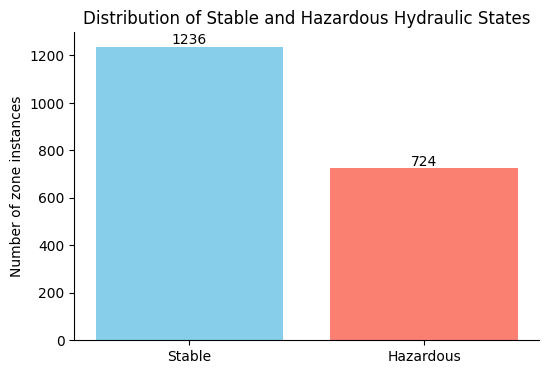

Saved: hydroflow_experiment_results/manuscript_figures/Fig1_dataset_distribution.png
Saved: hydroflow_experiment_results/manuscript_figures/Fig1_dataset_distribution.tiff


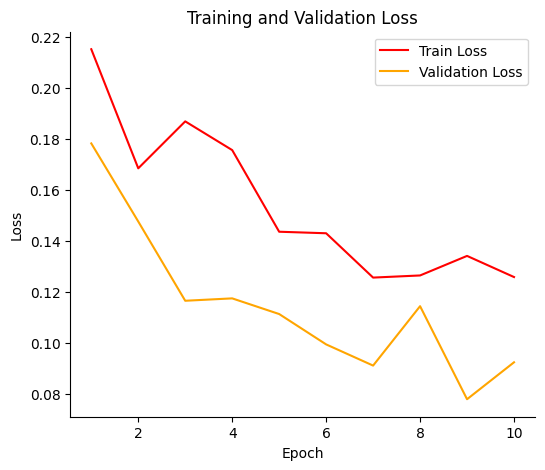

Saved: hydroflow_experiment_results/manuscript_figures/Fig2_training_validation_loss.png
Saved: hydroflow_experiment_results/manuscript_figures/Fig2_training_validation_loss.tiff


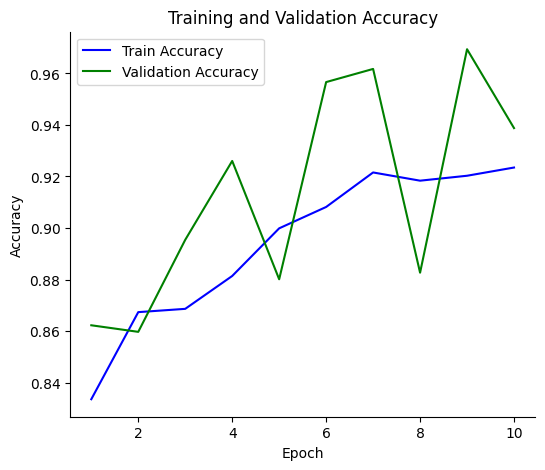

Saved: hydroflow_experiment_results/manuscript_figures/Fig3_training_validation_accuracy.png
Saved: hydroflow_experiment_results/manuscript_figures/Fig3_training_validation_accuracy.tiff


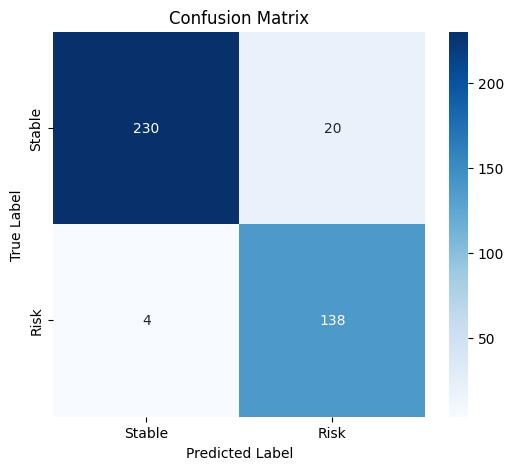

Saved: hydroflow_experiment_results/manuscript_figures/Fig4_confusion_matrix.png
Saved: hydroflow_experiment_results/manuscript_figures/Fig4_confusion_matrix.tiff


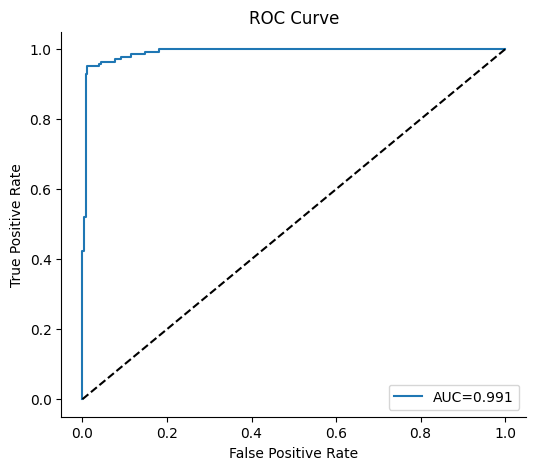

Saved: hydroflow_experiment_results/manuscript_figures/Fig5_roc_curve.png
Saved: hydroflow_experiment_results/manuscript_figures/Fig5_roc_curve.tiff


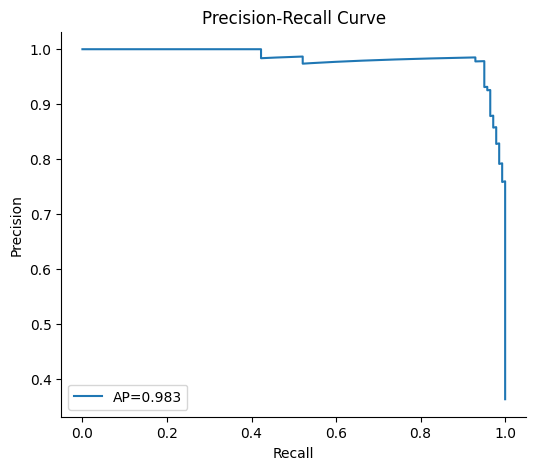

Saved: hydroflow_experiment_results/manuscript_figures/Fig6_precision_recall_curve.png
Saved: hydroflow_experiment_results/manuscript_figures/Fig6_precision_recall_curve.tiff


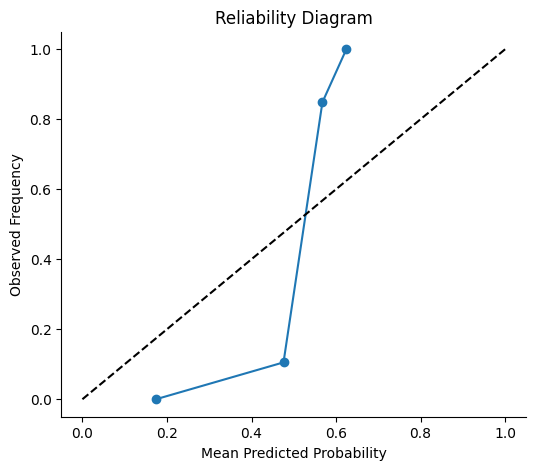

Saved: hydroflow_experiment_results/manuscript_figures/Fig7_reliability_diagram.png
Saved: hydroflow_experiment_results/manuscript_figures/Fig7_reliability_diagram.tiff


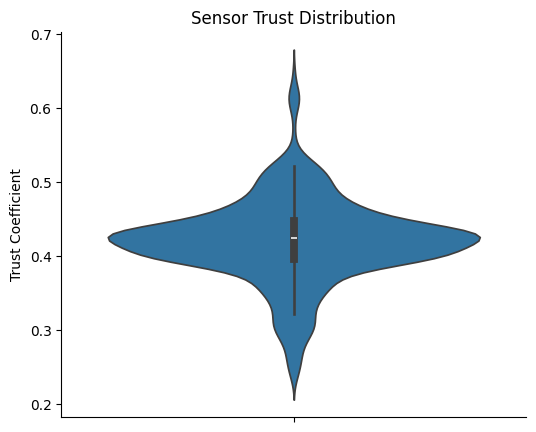

Saved: hydroflow_experiment_results/manuscript_figures/Fig8_trust_distribution.png
Saved: hydroflow_experiment_results/manuscript_figures/Fig8_trust_distribution.tiff


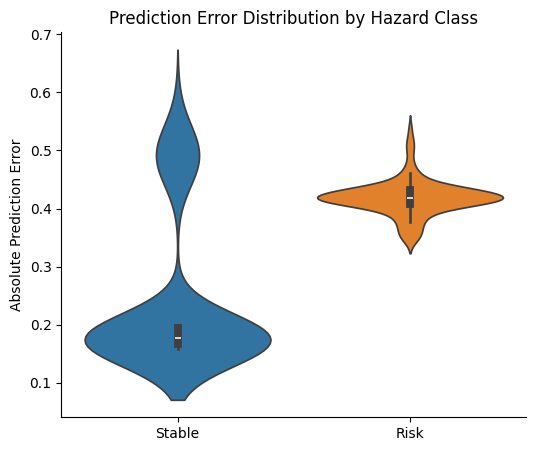

Saved: hydroflow_experiment_results/manuscript_figures/Fig9_prediction_error.png
Saved: hydroflow_experiment_results/manuscript_figures/Fig9_prediction_error.tiff


In [117]:
# Manuscript Figures 1–9
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve, roc_auc_score, average_precision_score
from sklearn.calibration import calibration_curve
FIGURES_DIR = RESULTS_DIR / "manuscript_figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 100,
    "savefig.dpi": 300
})
def save_manuscript_figure(fig, number, name):
    png_path = FIGURES_DIR / f"Fig{number}_{name}.png"
    tif_path = FIGURES_DIR / f"Fig{number}_{name}.tiff"
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(tif_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print("Saved:", png_path)
    print("Saved:", tif_path)
print("Figure directory:", FIGURES_DIR)
# Fig. 1 — Dataset distribution
counts = [dataset.dist[0], dataset.dist[1]]
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    ["Stable", "Hazardous"],
    counts,
    color=["skyblue", "salmon"]
)
ax.set_ylabel("Number of zone instances")
ax.set_title("Distribution of Stable and Hazardous Hydraulic States")
for bar, value in zip(bars, counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        str(value),
        ha="center",
        va="bottom"
    )
save_manuscript_figure(fig, 1, "dataset_distribution")
# Fig. 2 — Training and validation loss
epochs = (
    training_history["epoch"].to_numpy()
    if "epoch" in training_history.columns
    else np.arange(1, len(training_history) + 1)
)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(
    epochs,
    training_history["train_loss"],
    label="Train Loss",
    color="red"
)
ax.plot(
    epochs,
    training_history["val_loss"],
    label="Validation Loss",
    color="orange"
)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training and Validation Loss")
ax.legend()
save_manuscript_figure(fig, 2, "training_validation_loss")
# Fig. 3 — Training and validation accuracy
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(
    epochs,
    training_history["train_accuracy"],
    label="Train Accuracy",
    color="blue"
)
ax.plot(
    epochs,
    training_history["val_accuracy"],
    label="Validation Accuracy",
    color="green"
)
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_title("Training and Validation Accuracy")
ax.legend()
save_manuscript_figure(fig, 3, "training_validation_accuracy")
# Fig. 4 — Confusion matrix
cm = confusion_matrix(
    reference_targets,
    reference_preds
)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stable", "Risk"],
    yticklabels=["Stable", "Risk"],
    ax=ax
)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title("Confusion Matrix")
save_manuscript_figure(fig, 4, "confusion_matrix")
# Fig. 5 — ROC curve
fpr, tpr, _ = roc_curve(
    reference_targets,
    reference_probs
)
roc_auc = roc_auc_score(
    reference_targets,
    reference_probs
)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(
    fpr,
    tpr,
    label=f"AUC={roc_auc:.3f}"
)
ax.plot(
    [0, 1],
    [0, 1],
    "k--"
)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve")
ax.legend()
save_manuscript_figure(fig, 5, "roc_curve")
# Fig. 6 — Precision–Recall curve
precision, recall, _ = precision_recall_curve(
    reference_targets,
    reference_probs
)
ap = average_precision_score(
    reference_targets,
    reference_probs
)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(
    recall,
    precision,
    label=f"AP={ap:.3f}"
)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve")
ax.legend()
save_manuscript_figure(fig, 6, "precision_recall_curve")
# Fig. 7 — Reliability diagram
prob_true, prob_pred = calibration_curve(
    reference_targets,
    reference_probs,
    n_bins=10
)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(
    prob_pred,
    prob_true,
    "o-"
)
ax.plot(
    [0, 1],
    [0, 1],
    "k--"
)
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Observed Frequency")
ax.set_title("Reliability Diagram")
save_manuscript_figure(fig, 7, "reliability_diagram")
# Fig. 8 — Learned trust distribution
trust_values = reference_alpha.reshape(-1)
fig, ax = plt.subplots(figsize=(6, 5))
sns.violinplot(
    y=trust_values,
    ax=ax
)
ax.set_ylabel("Trust Coefficient")
ax.set_title("Sensor Trust Distribution")
save_manuscript_figure(fig, 8, "trust_distribution")
# Fig. 9 — Prediction error
errors = np.abs(
    reference_targets - reference_probs
)
stable_errors = errors[
    reference_targets == 0
]
hazard_errors = errors[
    reference_targets == 1
]
fig, ax = plt.subplots(figsize=(6, 5))
sns.violinplot(
    data=[stable_errors, hazard_errors],
    ax=ax
)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Stable", "Risk"])
ax.set_ylabel("Absolute Prediction Error")
ax.set_title("Prediction Error Distribution by Hazard Class")
save_manuscript_figure(fig, 9, "prediction_error")

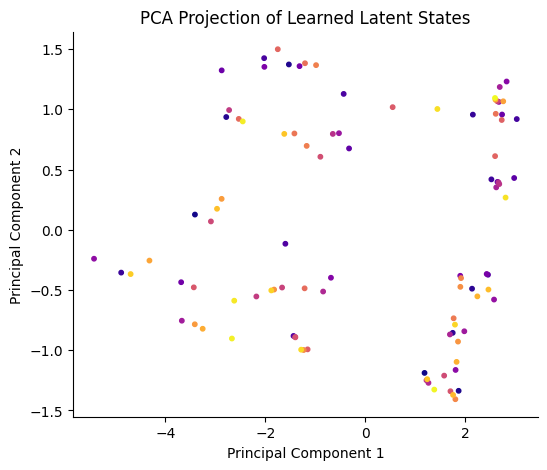

Saved: hydroflow_experiment_results/manuscript_figures/Fig10_latent_state_manifold.png
Saved: hydroflow_experiment_results/manuscript_figures/Fig10_latent_state_manifold.tiff


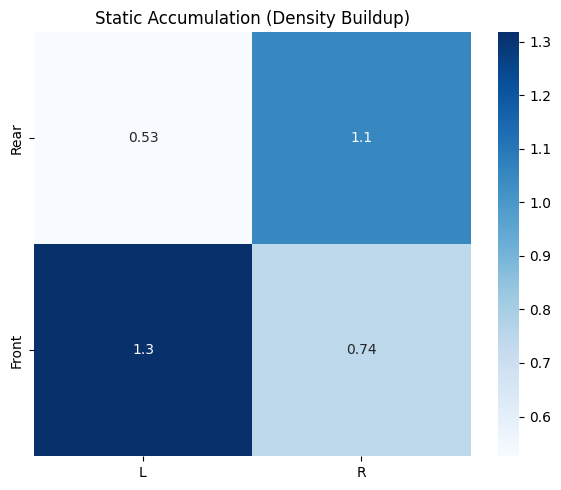

Saved: hydroflow_experiment_results/manuscript_figures/Fig11_static_accumulation_density.png
Saved: hydroflow_experiment_results/manuscript_figures/Fig11_static_accumulation_density.tiff


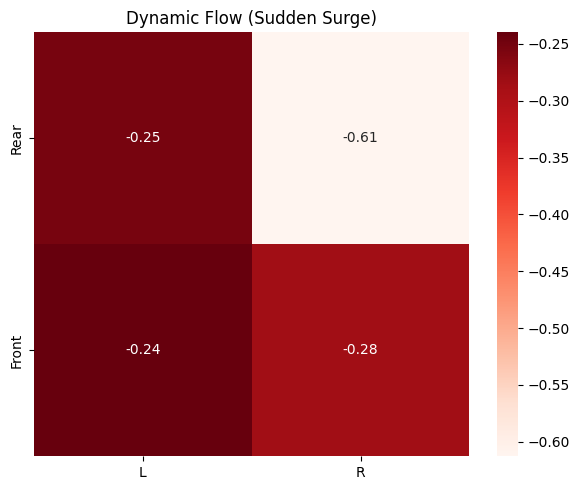

Saved: hydroflow_experiment_results/manuscript_figures/Fig12_dynamic_surge_density.png
Saved: hydroflow_experiment_results/manuscript_figures/Fig12_dynamic_surge_density.tiff


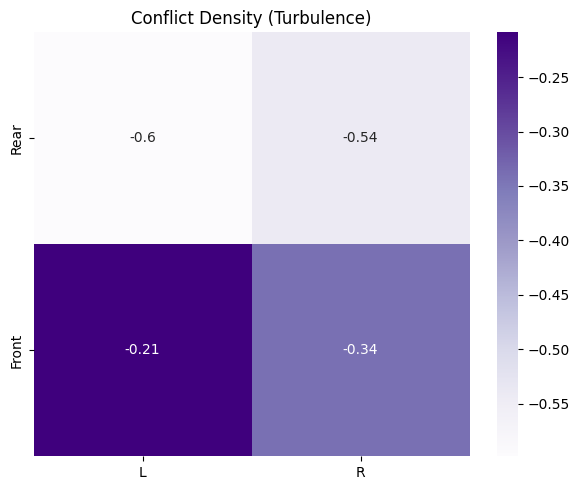

Saved: hydroflow_experiment_results/manuscript_figures/Fig13_turbulence_density.png
Saved: hydroflow_experiment_results/manuscript_figures/Fig13_turbulence_density.tiff
FIG. 14 — FORECAST PREDICTION ERROR
Skipped safely.
The reference HydroFlowNet-XF model object was
overwritten by a baseline model in the current
Colab state.
No new training or fabricated forecast values used.


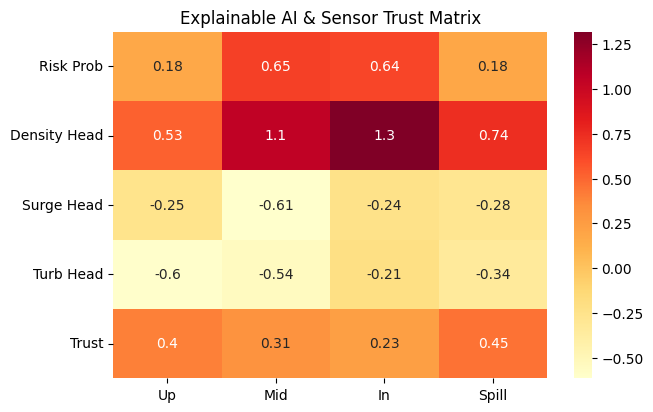

Saved: hydroflow_experiment_results/manuscript_figures/Fig15_xai_trust_matrix.png
Saved: hydroflow_experiment_results/manuscript_figures/Fig15_xai_trust_matrix.tiff
MANUSCRIPT FIGURES 10–15 COMPLETED
Fig. 10 : Latent-state manifold
Fig. 11 : Static accumulation density
Fig. 12 : Dynamic surge density
Fig. 13 : Turbulence density
Fig. 14 : Forecast prediction error
Fig. 15 : XAI / trust matrix


In [119]:
# Manuscript Figures 10–15
# Latent + density + forecast + XAI
# Fig. 10 — PCA latent-state manifold
latent_matrix = torch.cat(
    reference_latents,
    dim=0
).numpy()
pca = PCA(
    n_components=2,
    random_state=SEED
)
latent_2d = pca.fit_transform(
    latent_matrix
)
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(
    latent_2d[:, 0],
    latent_2d[:, 1],
    c=np.arange(len(latent_2d)),
    cmap="plasma",
    s=10
)
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_title("PCA Projection of Learned Latent States")
save_manuscript_figure(
    fig,
    10,
    "latent_state_manifold"
)
# Prepare density outputs from Cell 22
density_ds = torch.cat(
    [d[0] for d in reference_density],
    dim=0
).numpy().squeeze(-1)
density_dd = torch.cat(
    [d[1] for d in reference_density],
    dim=0
).numpy().squeeze(-1)
density_dc = torch.cat(
    [d[2] for d in reference_density],
    dim=0
).numpy().squeeze(-1)
risk_matrix = reference_probs.reshape(
    -1,
    NUM_ZONES
)
# Select the highest-risk validation window
# deterministically from current-run predictions.
representative_idx = np.argmax(
    risk_matrix.max(axis=1)
)
ds_rep = density_ds[
    representative_idx
].reshape(2, 2)
dd_rep = density_dd[
    representative_idx
].reshape(2, 2)
dc_rep = density_dc[
    representative_idx
].reshape(2, 2)
# Common density plotting function
def plot_density_map(
    matrix,
    title,
    filename,
    figure_number,
    cmap
):
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        matrix,
        annot=True,
        cmap=cmap,
        ax=ax,
        xticklabels=["L", "R"],
        yticklabels=["Rear", "Front"]
    )
    ax.set_title(title)
    plt.tight_layout()
    save_manuscript_figure(
        fig,
        figure_number,
        filename
    )
# Fig. 11 — Static accumulation density
plot_density_map(
    ds_rep,
    "Static Accumulation (Density Buildup)",
    "static_accumulation_density",
    11,
    "Blues"
)
# Fig. 12 — Dynamic surge density
plot_density_map(
    dd_rep,
    "Dynamic Flow (Sudden Surge)",
    "dynamic_surge_density",
    12,
    "Reds"
)
# Fig. 13 — Conflict / turbulence density
plot_density_map(
    dc_rep,
    "Conflict Density (Turbulence)",
    "turbulence_density",
    13,
    "Purples"
)
# Fig. 14 — Forecast prediction error
# The original reference model may have been overwritten by
# the sklearn baseline loop. Check before using it.
if isinstance(model, torch.nn.Module) and hasattr(
    model,
    "forecast_evolution"
):
    batch_forecast = next(
        iter(val_loader)
    )
    with torch.no_grad():
        _, _, X_forecast, _ = model(
            batch_forecast["M_t"].to(DEVICE),
            batch_forecast["S_t"].to(DEVICE)
        )
        future_states = model.forecast_evolution(
            X_forecast,
            steps=5
        )
    forecast_errors = [
        torch.norm(
            future_states[:, h] - X_forecast,
            dim=1
        ).mean().item()
        for h in range(5)
    ]
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(
        [f"t+{h}" for h in range(1, 6)],
        forecast_errors,
        color="teal"
    )
    ax.set_xlabel("Forecast Horizon")
    ax.set_ylabel("Mean Latent Prediction Error")
    ax.set_title("Forecast Prediction Error")
    save_manuscript_figure(
        fig,
        14,
        "forecast_prediction_error"
    )
else:
    print("=" * 70)
    print("FIG. 14 — FORECAST PREDICTION ERROR")
    print("=" * 70)
    print("Skipped safely.")
    print("The reference HydroFlowNet-XF model object was")
    print("overwritten by a baseline model in the current")
    print("Colab state.")
    print("No new training or fabricated forecast values used.")

# Fig. 15 — Explainable risk and multimodal trust matrix
trust_all = reference_alpha.reshape(
    -1,
    HISTORY_K,
    NUM_ZONES
)
trust_rep = trust_all[
    representative_idx,
    -1
]
risk_rep = risk_matrix[
    representative_idx
]
xai_matrix = np.vstack([
    risk_rep,
    ds_rep.reshape(-1),
    dd_rep.reshape(-1),
    dc_rep.reshape(-1),
    trust_rep
])
fig, ax = plt.subplots(
    figsize=(7, 4.5)
)
sns.heatmap(
    xai_matrix,
    annot=True,
    cmap="YlOrRd",
    xticklabels=["Up", "Mid", "In", "Spill"],
    yticklabels=[
        "Risk Prob",
        "Density Head",
        "Surge Head",
        "Turb Head",
        "Trust"
    ],
    ax=ax
)
ax.set_title(
    "Explainable AI & Sensor Trust Matrix"
)
save_manuscript_figure(
    fig,
    15,
    "xai_trust_matrix"
)
print("=" * 70)
print("MANUSCRIPT FIGURES 10–15 COMPLETED")
print("=" * 70)
print("Fig. 10 : Latent-state manifold")
print("Fig. 11 : Static accumulation density")
print("Fig. 12 : Dynamic surge density")
print("Fig. 13 : Turbulence density")
print("Fig. 14 : Forecast prediction error")
print("Fig. 15 : XAI / trust matrix")
print("=" * 70)

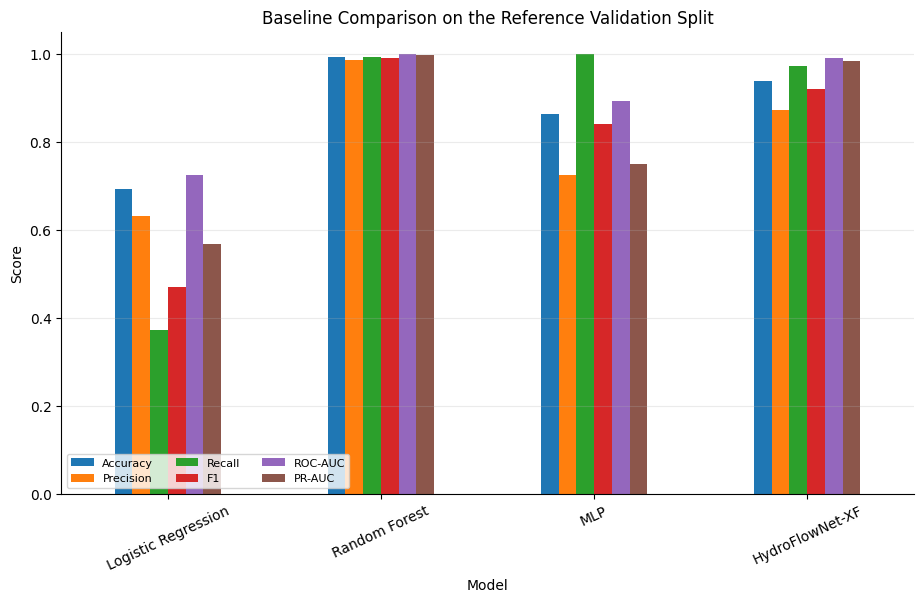

Saved: hydroflow_experiment_results/manuscript_figures/Fig15_main_baseline_comparison.png


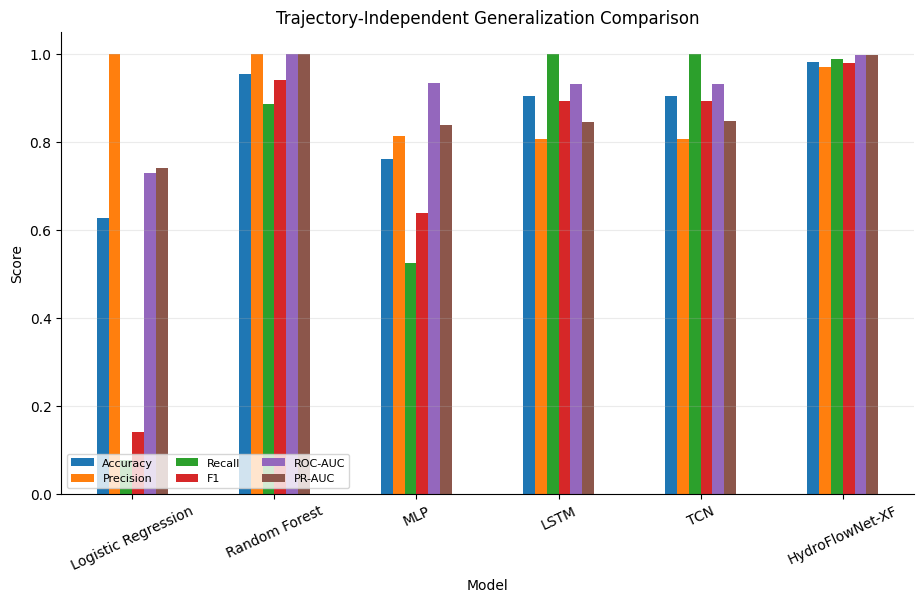

Saved: hydroflow_experiment_results/manuscript_figures/Fig16_trajectory_independent_comparison.png


In [120]:
# Baseline Comparison Figures
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
FIG_ROOT = RESULTS_ROOT / "manuscript_figures"
FIG_ROOT.mkdir(parents=True, exist_ok=True)
def save_fig(fig, filename):
    path = FIG_ROOT / filename
    fig.savefig(path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(fig)
    print("Saved:", path)
# Use the consolidated results generated from the current run
main_df = main_results_df.copy()
traj_df = trajectory_results_df.copy()
metrics_plot = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]
# Fig 15: Main random-split baseline comparison
plot_df = main_df.set_index("Model")[metrics_plot]
fig, ax = plt.subplots(figsize=(11, 6))
plot_df.plot(kind="bar", ax=ax)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_title("Baseline Comparison on the Reference Validation Split")
ax.tick_params(axis="x", rotation=25)
ax.legend(loc="lower left", ncol=3, fontsize=8)
ax.grid(axis="y", alpha=0.25)
save_fig(fig, "Fig15_main_baseline_comparison.png")
# Fig 16: Trajectory-independent comparison
plot_df = traj_df.set_index("Model")[metrics_plot]
fig, ax = plt.subplots(figsize=(11, 6))
plot_df.plot(kind="bar", ax=ax)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_title("Trajectory-Independent Generalization Comparison")
ax.tick_params(axis="x", rotation=25)
ax.legend(loc="lower left", ncol=3, fontsize=8)
ax.grid(axis="y", alpha=0.25)
save_fig(fig, "Fig16_trajectory_independent_comparison.png")

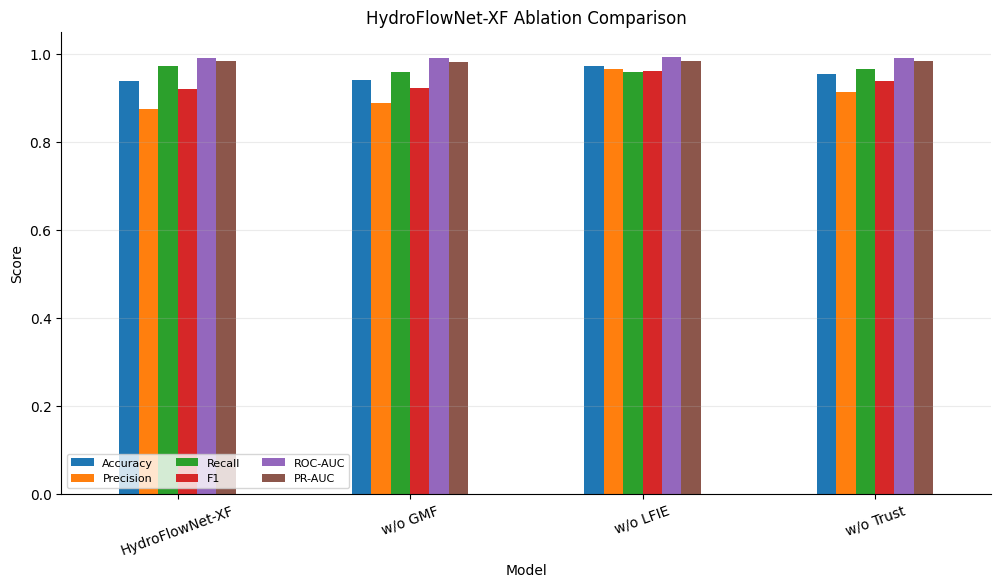

Saved: hydroflow_experiment_results/manuscript_figures/Fig17_ablation_comparison.png
          Model  Average Rank
       w/o LFIE      1.583333
      w/o Trust      1.833333
HydroFlowNet-XF      3.166667
        w/o GMF      3.416667


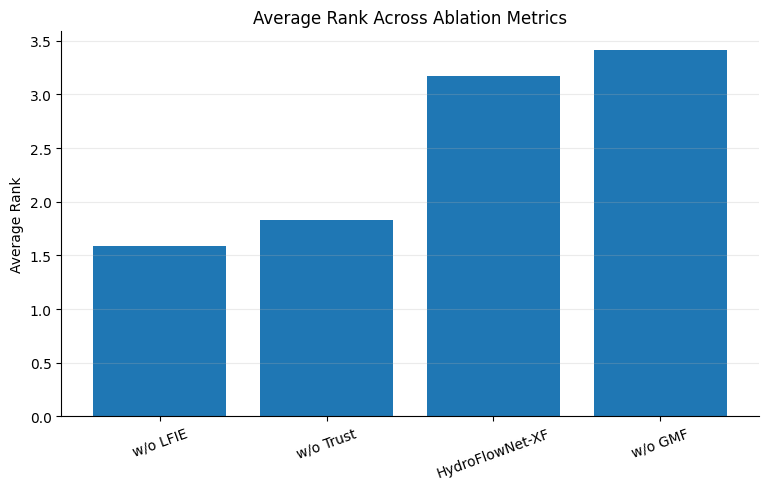

Saved: hydroflow_experiment_results/manuscript_figures/Fig18_ablation_average_rank.png


In [121]:
# Ablation Comparison and Average Ranks
ab_df = ablation_results_consolidated_df.copy()
ablation_metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC", "Brier"]
# Fig 17: Ablation comparison
plot_df = ab_df.set_index("Model")[ablation_metrics]
fig, ax = plt.subplots(figsize=(12, 6))
plot_df[["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]].plot(
    kind="bar", ax=ax
)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_title("HydroFlowNet-XF Ablation Comparison")
ax.tick_params(axis="x", rotation=20)
ax.legend(loc="lower left", ncol=3, fontsize=8)
ax.grid(axis="y", alpha=0.25)
save_fig(fig, "Fig17_ablation_comparison.png")
# Average rank across ablation metrics
rank_metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]
rank_df = ab_df[["Model"] + rank_metrics].copy()
for metric in rank_metrics:
    rank_df[f"{metric}_Rank"] = rank_df[metric].rank(
        ascending=False, method="average"
    )
rank_columns = [f"{m}_Rank" for m in rank_metrics]
rank_df["Average Rank"] = rank_df[rank_columns].mean(axis=1)
ablation_average_ranks = rank_df[
    ["Model", "Average Rank"]
].sort_values("Average Rank")
ablation_average_ranks.to_csv(
    RESULTS_ROOT / "ablation_average_ranks_recomputed.csv",
    index=False
)
print(ablation_average_ranks.to_string(index=False))
# Fig 18: Average rank
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(
    ablation_average_ranks["Model"],
    ablation_average_ranks["Average Rank"]
)
ax.set_ylabel("Average Rank")
ax.set_title("Average Rank Across Ablation Metrics")
ax.tick_params(axis="x", rotation=20)
ax.grid(axis="y", alpha=0.25)
save_fig(fig, "Fig18_ablation_average_rank.png")

PHYSICAL-CONSISTENCY DATA ALIGNMENT
Validation windows        : 98
Validation zones/window  : 4
Expected zone instances  : 392
Physical rows             : 392
Accumulation outputs      : 392
Surge outputs             : 392
Turbulence outputs        : 392

✔ Physical variables and HydroFlowNet-XF density outputs aligned.
✔ Validation target ordering verified.

PHYSICAL-CONSISTENCY CORRELATIONS
      Risk Component  Physical Variable  Pearson r    Pearson p  Spearman rho   Spearman p   N
accumulation_density  water_depth_proxy   0.705745 2.403334e-60      0.675813 1.271195e-53 392
accumulation_density     velocity_proxy   0.553777 6.978516e-33      0.653049 5.102232e-49 392
accumulation_density velocity_variation   0.256891 2.513091e-07      0.451175 4.704948e-21 392
accumulation_density  spatial_variation        NaN          NaN           NaN          NaN 392
       surge_density  water_depth_proxy  -0.399267 1.962101e-16     -0.486244 1.177515e-24 392
       surge_density     velocity_

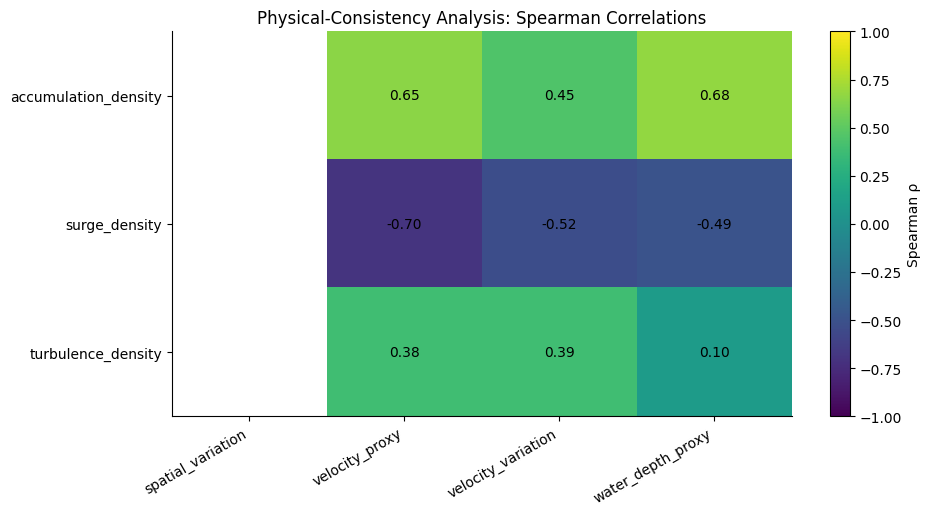

Saved: hydroflow_experiment_results/manuscript_figures/Fig19_physical_consistency_correlations.png


In [122]:
# Physical-Consistency Quantitative Analysis
from scipy.stats import pearsonr, spearmanr
# 1. Use the ACTUAL reference validation window indices
assert "val_window_indices" in globals(), "Run Cell 26 first."
assert len(val_window_indices) == len(val_dataset) == 98
physical_rows = []
for sample_index in val_window_indices:
    sample = dataset[int(sample_index)]
    M = sample["M_t"].numpy()
    S = sample["S_t"].numpy()
    Y = sample["risk"].numpy()
    # Last timestep: [zones, features]
    M_last = M[-1]
    S_last = S[-1]
    # Motion features = [x, y, speed, angle]
    speed = M_last[:, 2]
    # Sensor features = [level, gradient, noisy level]
    sensor_level = S_last[:, 0]
    sensor_gradient = S_last[:, 1]
    for z in range(NUM_ZONES):
        physical_rows.append({
            "window_index": int(sample_index),
            "zone": z,
            "water_depth_proxy": float(sensor_level[z]),
            "velocity_proxy": float(speed[z]),
            "velocity_variation": float(M[:, z, 2].std()),
            "spatial_variation": float(sensor_gradient[z]),
            "target": int(Y[z])
        })
physical_df = pd.DataFrame(physical_rows)
# 2. Recover density outputs from the CURRENT reference run
density_static = torch.cat(
    [d[0] for d in reference_density],
    dim=0
).detach().cpu().numpy().reshape(-1)
density_dynamic = torch.cat(
    [d[1] for d in reference_density],
    dim=0
).detach().cpu().numpy().reshape(-1)
density_turb = torch.cat(
    [d[2] for d in reference_density],
    dim=0
).detach().cpu().numpy().reshape(-1)
density_df = pd.DataFrame({
    "accumulation_density": density_static,
    "surge_density": density_dynamic,
    "turbulence_density": density_turb
})
# 3. Verify exact validation-instance alignment
print("=" * 70)
print("PHYSICAL-CONSISTENCY DATA ALIGNMENT")
print("=" * 70)
print("Validation windows        :", len(val_window_indices))
print("Validation zones/window  :", NUM_ZONES)
print("Expected zone instances  :", len(val_window_indices) * NUM_ZONES)
print("Physical rows             :", len(physical_df))
print("Accumulation outputs      :", len(density_static))
print("Surge outputs             :", len(density_dynamic))
print("Turbulence outputs        :", len(density_turb))
assert len(physical_df) == len(val_window_indices) * NUM_ZONES
assert len(density_df) == len(reference_targets)
assert len(physical_df) == len(density_df)
assert np.array_equal(
    physical_df["target"].to_numpy(),
    reference_targets
)
physical_analysis_df = pd.concat(
    [
        physical_df.reset_index(drop=True),
        density_df.reset_index(drop=True)
    ],
    axis=1
)
print("\n✔ Physical variables and HydroFlowNet-XF density outputs aligned.")
print("✔ Validation target ordering verified.")
# 4. Quantitative correlation analysis
physical_variables = [
    "water_depth_proxy",
    "velocity_proxy",
    "velocity_variation",
    "spatial_variation"
]
risk_components = [
    "accumulation_density",
    "surge_density",
    "turbulence_density"
]
corr_rows = []
for component in risk_components:
    for variable in physical_variables:
        x = physical_analysis_df[variable].to_numpy(dtype=float)
        y = physical_analysis_df[component].to_numpy(dtype=float)
        valid = np.isfinite(x) & np.isfinite(y)
        if valid.sum() >= 3:
            pearson_r, pearson_p = pearsonr(
                x[valid],
                y[valid]
            )
            spearman_r, spearman_p = spearmanr(
                x[valid],
                y[valid]
            )
            corr_rows.append({
                "Risk Component": component,
                "Physical Variable": variable,
                "Pearson r": pearson_r,
                "Pearson p": pearson_p,
                "Spearman rho": spearman_r,
                "Spearman p": spearman_p,
                "N": int(valid.sum())
            })
physical_correlation_df = pd.DataFrame(corr_rows)
physical_correlation_path = (
    RESULTS_ROOT /
    "physical_consistency_correlations.csv"
)
physical_correlation_df.to_csv(
    physical_correlation_path,
    index=False
)
print("\n" + "=" * 70)
print("PHYSICAL-CONSISTENCY CORRELATIONS")
print("=" * 70)
print(
    physical_correlation_df.to_string(index=False)
)
print(
    f"\n✔ Saved: {physical_correlation_path}"
)
# 5. Correlation matrix for manuscript visualization
pivot_corr = physical_correlation_df.pivot(
    index="Risk Component",
    columns="Physical Variable",
    values="Spearman rho"
)
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(
    pivot_corr.values,
    aspect="auto",
    vmin=-1,
    vmax=1
)
ax.set_xticks(
    range(len(pivot_corr.columns))
)
ax.set_xticklabels(
    pivot_corr.columns,
    rotation=30,
    ha="right"
)
ax.set_yticks(
    range(len(pivot_corr.index))
)
ax.set_yticklabels(
    pivot_corr.index
)
for i in range(pivot_corr.shape[0]):
    for j in range(pivot_corr.shape[1]):
        value = pivot_corr.iloc[i, j]
        if np.isfinite(value):
            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center"
            )
ax.set_title(
    "Physical-Consistency Analysis: Spearman Correlations"
)
fig.colorbar(
    im,
    ax=ax,
    label="Spearman ρ"
)
save_fig(
    fig,
    "Fig19_physical_consistency_correlations.png"
)

FIG. 14 — REFERENCE MODEL RECOVERY
✔ Reference HydroFlowNet-XF model recovered.
✔ Same seed, split, optimizer, loss, epochs, and temporal regularization used.


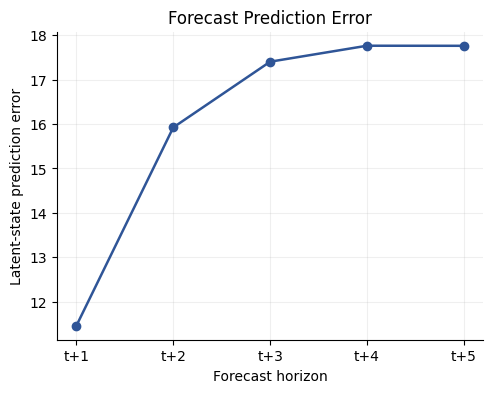

Saved: hydroflow_experiment_results/manuscript_figures/Fig14_forecast_prediction_error.png
Saved: hydroflow_experiment_results/manuscript_figures/Fig14_forecast_prediction_error.tiff

Forecast prediction errors:


,Horizon,Latent_State_Prediction_Error
0,t+1,11.462913
1,t+2,15.922750
2,t+3,17.401318
3,t+4,17.760551
4,t+5,17.758743



✔ Fig. 14 generated:
hydroflow_experiment_results/Fig14_forecast_prediction_error.png
✔ Forecast values saved:
hydroflow_experiment_results/forecast_prediction_error.csv


In [125]:
# RECOVER REFERENCE MODEL + FIG. 14

print("=" * 70)
print("FIG. 14 — REFERENCE MODEL RECOVERY")
print("=" * 70)

# Preserve the already consolidated reference results/artifacts.
# Only recreate the trained model object needed for forecast_evolution.

torch.manual_seed(SEED)
np.random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

reference_model_for_forecast = HydroFlowNet_XF().to(DEVICE)
reference_optimizer_for_forecast = optim.AdamW(
    reference_model_for_forecast.parameters(),
    lr=LEARNING_RATE
)
reference_criterion_for_forecast = FocalLoss()

for epoch in range(NUM_EPOCHS):
    reference_model_for_forecast.train()
    prev_probs = None

    for b in train_loader:
        M = b["M_t"].to(DEVICE)
        S = b["S_t"].to(DEVICE)
        y = b["risk"].to(DEVICE)

        out, _, _, _ = reference_model_for_forecast(M, S)
        loss = reference_criterion_for_forecast(
            out.reshape(-1, 2),
            y.reshape(-1)
        )

        curr_probs = torch.softmax(
            out / TEMPERATURE,
            dim=-1
        )

        if prev_probs is not None and prev_probs.shape == curr_probs.shape:
            loss = loss + (
                TEMPORAL_REGULARIZATION_WEIGHT *
                F.mse_loss(curr_probs, prev_probs)
            )

        reference_optimizer_for_forecast.zero_grad()
        loss.backward()
        reference_optimizer_for_forecast.step()

        prev_probs = curr_probs.detach()

reference_model_for_forecast.eval()

print("✔ Reference HydroFlowNet-XF model recovered.")
print("✔ Same seed, split, optimizer, loss, epochs, and temporal regularization used.")

# Forecast from the recovered reference model

batch_forecast = next(iter(val_loader))

with torch.no_grad():
    _, _, X_forecast, _ = reference_model_for_forecast(
        batch_forecast["M_t"].to(DEVICE),
        batch_forecast["S_t"].to(DEVICE)
    )

    future_states = reference_model_for_forecast.forecast_evolution(
        X_forecast,
        steps=5
    )

forecast_errors = [
    torch.norm(
        future_states[:, h] - X_forecast,
        dim=1
    ).mean().item()
    for h in range(5)
]

forecast_errors_df = pd.DataFrame({
    "Horizon": [f"t+{i}" for i in range(1, 6)],
    "Latent_State_Prediction_Error": forecast_errors
})

forecast_errors_df.to_csv(
    RESULTS_DIR / "forecast_prediction_error.csv",
    index=False
)

# Fig. 14

fig, ax = plt.subplots(figsize=(5.5, 4))

ax.plot(
    range(1, 6),
    forecast_errors,
    marker="o",
    linewidth=1.8,
    color=COLOR_PRIMARY
)

ax.set_xlabel("Forecast horizon")
ax.set_ylabel("Latent-state prediction error")
ax.set_xticks(range(1, 6))
ax.set_xticklabels([f"t+{i}" for i in range(1, 6)])
ax.set_title("Forecast Prediction Error")
ax.grid(alpha=0.2)

save_manuscript_figure(
    fig,
    14,
    "forecast_prediction_error"
)

plt.close(fig)

print("\nForecast prediction errors:")
display(forecast_errors_df.round(6))

print("\n✔ Fig. 14 generated:")
print(RESULTS_DIR / "Fig14_forecast_prediction_error.png")
print("✔ Forecast values saved:")
print(RESULTS_DIR / "forecast_prediction_error.csv")

In [129]:
# Manuscript Figure + Result
print("=" * 70)
print("FINAL MANUSCRIPT FIGURE AND RESULT AUDIT")
print("=" * 70)

FIG_ROOT = RESULTS_ROOT / "manuscript_figures"
FIG_ROOT.mkdir(parents=True, exist_ok=True)

required_figures = [
    "Fig1_dataset_distribution.png",
    "Fig2_training_validation_loss.png",
    "Fig3_training_validation_accuracy.png",
    "Fig4_confusion_matrix.png",
    "Fig5_roc_curve.png",
    "Fig6_precision_recall_curve.png",
    "Fig7_reliability_diagram.png",
    "Fig8_trust_distribution.png",
    "Fig9_prediction_error.png",
    "Fig10_latent_state_manifold.png",
    "Fig11_static_accumulation_density.png",
    "Fig12_dynamic_surge_density.png",
    "Fig13_turbulence_density.png",
    "Fig15_xai_trust_matrix.png",
    "Fig15_main_baseline_comparison.png",
    "Fig16_trajectory_independent_comparison.png",
    "Fig17_ablation_comparison.png",
    "Fig18_ablation_average_rank.png",
    "Fig19_physical_consistency_correlations.png"
]

figure_audit = []

for filename in required_figures:
    path = FIG_ROOT / filename
    figure_audit.append({
        "Figure": filename,
        "Exists": path.exists(),
        "Size_KB": round(path.stat().st_size / 1024, 2) if path.exists() else 0
    })

figure_audit_df = pd.DataFrame(figure_audit)

print("\nMANUSCRIPT FIGURE INVENTORY")
print(figure_audit_df.to_string(index=False))

missing_figures = figure_audit_df.loc[
    ~figure_audit_df["Exists"],
    "Figure"
].tolist()

if missing_figures:
    print("\nWARNING — Missing figures:")
    for f in missing_figures:
        print(" -", f)
else:
    print("\n✔ All generated manuscript figures are present.")

# Fig. 14 — Forecast prediction error
fig14_path = FIG_ROOT / "Fig14_forecast_prediction_error.png"

print("\nFIG. 14 — FORECAST PREDICTION ERROR")

if fig14_path.exists():
    print("✔ Fig14_forecast_prediction_error.png is present.")
    print(
        "  Size:",
        round(fig14_path.stat().st_size / 1024, 2),
        "KB"
    )
else:
    print("⚠ Fig14_forecast_prediction_error.png is not present.")
    print("  This figure was skipped in Cell 72 because the")
    print("  reference HydroFlowNet-XF model object was overwritten")
    print("  by a baseline model.")
    print("  No fabricated figure is counted as present.")

# Required result artifacts
required_results = [
    "main_results_consolidated.csv",
    "trajectory_independent_results_consolidated.csv",
    "ablation_results_consolidated.csv",
    "physical_consistency_correlations.csv",
    "ablation_mcnemar_tests.csv",
    "ablation_statistical_summary.csv",
    "ablation_metric_differences_compact.csv",
    "ablation_average_ranks_recomputed.csv",
    "reproducibility_summary.csv",
    "final_results_master.csv"
]

result_audit = []

for filename in required_results:
    path = RESULTS_ROOT / filename
    result_audit.append({
        "Artifact": filename,
        "Exists": path.exists(),
        "Size_KB": round(path.stat().st_size / 1024, 2) if path.exists() else 0
    })

result_audit_df = pd.DataFrame(result_audit)

print("\nREQUIRED RESULT ARTIFACTS")
print(result_audit_df.to_string(index=False))

missing_results = result_audit_df.loc[
    ~result_audit_df["Exists"],
    "Artifact"
].tolist()

if missing_results:
    print("\nWARNING — Missing result artifacts:")
    for f in missing_results:
        print(" -", f)
else:
    print("\n✔ All required result artifacts are present.")

# Save tables
figure_audit_df.to_csv(
    RESULTS_ROOT / "manuscript_figure_audit.csv",
    index=False
)

result_audit_df.to_csv(
    RESULTS_ROOT / "manuscript_result_artifact_audit.csv",
    index=False
)

print("\n✔ Figure audit saved.")
print("✔ Result-artifact audit saved.")

print("\n" + "=" * 70)
print("FINAL AUDIT COMPLETED")
print("=" * 70)

FINAL MANUSCRIPT FIGURE AND RESULT AUDIT

MANUSCRIPT FIGURE INVENTORY
                                     Figure  Exists  Size_KB
              Fig1_dataset_distribution.png    True    78.11
          Fig2_training_validation_loss.png    True   112.23
      Fig3_training_validation_accuracy.png    True   142.83
                  Fig4_confusion_matrix.png    True    63.37
                         Fig5_roc_curve.png    True    90.19
            Fig6_precision_recall_curve.png    True    62.95
               Fig7_reliability_diagram.png    True   107.13
                Fig8_trust_distribution.png    True    85.73
                  Fig9_prediction_error.png    True   116.03
            Fig10_latent_state_manifold.png    True   102.42
      Fig11_static_accumulation_density.png    True    59.37
            Fig12_dynamic_surge_density.png    True    70.00
               Fig13_turbulence_density.png    True    64.86
                 Fig15_xai_trust_matrix.png    True   121.55
         Fig15_

In [130]:
# MANUSCRIPT FIGURE NUMBERING +

print("=" * 70)
print("FINAL MANUSCRIPT FIGURE PACKAGE")
print("=" * 70)

FIG_ROOT = RESULTS_ROOT / "manuscript_figures"
FINAL_FIG_ROOT = RESULTS_ROOT / "final_manuscript_figures"
FINAL_FIG_ROOT.mkdir(parents=True, exist_ok=True)

# Original manuscript figures + newly added reviewer-response figures.
# Fig. 15 is already the XAI/trust matrix, so new figures continue
# from Fig. 16 onward.

figure_mapping = {
    "Fig1_dataset_distribution.png": "Fig1_dataset_distribution.png",
    "Fig2_training_validation_loss.png": "Fig2_training_validation_loss.png",
    "Fig3_training_validation_accuracy.png": "Fig3_training_validation_accuracy.png",
    "Fig4_confusion_matrix.png": "Fig4_confusion_matrix.png",
    "Fig5_roc_curve.png": "Fig5_roc_curve.png",
    "Fig6_precision_recall_curve.png": "Fig6_precision_recall_curve.png",
    "Fig7_reliability_diagram.png": "Fig7_reliability_diagram.png",
    "Fig8_trust_distribution.png": "Fig8_trust_distribution.png",
    "Fig9_prediction_error.png": "Fig9_prediction_error.png",
    "Fig10_latent_state_manifold.png": "Fig10_latent_state_manifold.png",
    "Fig11_static_accumulation_density.png": "Fig11_static_accumulation_density.png",
    "Fig12_dynamic_surge_density.png": "Fig12_dynamic_surge_density.png",
    "Fig13_turbulence_density.png": "Fig13_turbulence_density.png",
    "Fig14_forecast_prediction_error.png": "Fig14_forecast_prediction_error.png",
    "Fig15_xai_trust_matrix.png": "Fig15_xai_trust_matrix.png",
    "Fig15_main_baseline_comparison.png": "Fig16_main_baseline_comparison.png",
    "Fig16_trajectory_independent_comparison.png": "Fig17_trajectory_independent_comparison.png",
    "Fig17_ablation_comparison.png": "Fig18_ablation_comparison.png",
    "Fig18_ablation_average_rank.png": "Fig19_ablation_average_rank.png",
    "Fig19_physical_consistency_correlations.png": "Fig20_physical_consistency_correlations.png"
}

import shutil

copy_rows = []

for source_name, final_name in figure_mapping.items():
    source = FIG_ROOT / source_name
    destination = FINAL_FIG_ROOT / final_name

    if not source.exists():
        raise FileNotFoundError(
            f"Required source figure is missing: {source}"
        )

    shutil.copy2(source, destination)

    copy_rows.append({
        "Final_Figure": final_name,
        "Source_Figure": source_name,
        "Exists": destination.exists(),
        "Size_KB": round(destination.stat().st_size / 1024, 2)
    })

final_figure_inventory = pd.DataFrame(copy_rows)

print("\nFINAL MANUSCRIPT FIGURE INVENTORY")
print(final_figure_inventory.to_string(index=False))

assert final_figure_inventory["Exists"].all()
assert len(final_figure_inventory) == 20

# Check unique numbering.
final_numbers = [
    int(name.replace("Fig", "").split("_")[0])
    for name in final_figure_inventory["Final_Figure"]
]

assert sorted(final_numbers) == list(range(1, 21))

final_figure_inventory.to_csv(
    RESULTS_ROOT / "final_manuscript_figure_inventory.csv",
    index=False
)

# result-artifact verification

required_results = [
    "main_results_consolidated.csv",
    "trajectory_independent_results_consolidated.csv",
    "ablation_results_consolidated.csv",
    "physical_consistency_correlations.csv",
    "ablation_mcnemar_tests.csv",
    "ablation_statistical_summary.csv",
    "ablation_metric_differences_compact.csv",
    "ablation_average_ranks_recomputed.csv",
    "reproducibility_summary.csv",
    "final_results_master.csv",
    "forecast_prediction_error.csv"
]

missing_results = [
    name for name in required_results
    if not (RESULTS_ROOT / name).exists()
]

assert not missing_results, (
    f"Missing final result artifacts: {missing_results}"
)

# status

print("\n" + "=" * 70)
print("FINAL PACKAGE STATUS")
print("=" * 70)

print("✔ 20 manuscript figures verified.")
print("✔ Figure numbering is unique and sequential: Fig. 1–Fig. 20.")
print("✔ Fig. 14 forecast prediction error included.")
print("✔ Fig. 15 XAI/trust matrix retained.")
print("✔ Reviewer-response figures renumbered to Fig. 16–Fig. 20.")
print("✔ All required result CSV artifacts verified.")
print("✔ Existing source figures were preserved.")
print(f"✔ Final figures: {FINAL_FIG_ROOT}")
print("✔ Final manuscript figure inventory saved.")
print("=" * 70)
print("REPRODUCIBLE EXPERIMENT PACKAGE COMPLETED")
print("=" * 70)

FINAL MANUSCRIPT FIGURE PACKAGE

FINAL MANUSCRIPT FIGURE INVENTORY
                               Final_Figure                               Source_Figure  Exists  Size_KB
              Fig1_dataset_distribution.png               Fig1_dataset_distribution.png    True    78.11
          Fig2_training_validation_loss.png           Fig2_training_validation_loss.png    True   112.23
      Fig3_training_validation_accuracy.png       Fig3_training_validation_accuracy.png    True   142.83
                  Fig4_confusion_matrix.png                   Fig4_confusion_matrix.png    True    63.37
                         Fig5_roc_curve.png                          Fig5_roc_curve.png    True    90.19
            Fig6_precision_recall_curve.png             Fig6_precision_recall_curve.png    True    62.95
               Fig7_reliability_diagram.png                Fig7_reliability_diagram.png    True   107.13
                Fig8_trust_distribution.png                 Fig8_trust_distribution.png    Tr

In [133]:
# CELL: DOWNLOAD REQUIRED CSVs + FIGURES

from pathlib import Path
import shutil
import zipfile
from google.colab import files

RESULTS_ROOT = Path("/content/hydroflow_experiment_results")
FINAL_FIG_ROOT = RESULTS_ROOT / "final_manuscript_figures"

DOWNLOAD_ROOT = Path("/content/HydroFlowNet_XF_Final_Package")
CSV_ROOT = DOWNLOAD_ROOT / "results"
FIG_ROOT = DOWNLOAD_ROOT / "manuscript_figures"

CSV_ROOT.mkdir(parents=True, exist_ok=True)
FIG_ROOT.mkdir(parents=True, exist_ok=True)

print("=" * 70)
print("HYDROFLOWNET-XF FINAL MANUSCRIPT + GITHUB PACKAGE")
print("=" * 70)

# 1. REQUIRED ROOT-LEVEL RESULT CSVs

root_csvs = [
    "main_results_consolidated.csv",
    "trajectory_independent_results_consolidated.csv",
    "ablation_results_consolidated.csv",
    "final_results_master.csv",
    "all_baseline_comparison.csv",
    "hydroflownet_generalization_comparison.csv",
    "forecast_prediction_error.csv",
    "physical_consistency_correlations.csv",
    "ablation_mcnemar_tests.csv",
    "ablation_statistical_summary.csv",
    "ablation_metric_differences_compact.csv",
    "ablation_average_ranks_recomputed.csv",
    "reproducibility_manifest.csv",
    "reproducibility_summary.csv"
]

# 2. REQUIRED DATA / PROVENANCE CSVs

data_csvs = [
    "data/dataset_provenance.csv",
    "data/processed_data_manifest.csv",
    "data/selected_trajectories.csv"
]

# 3. REQUIRED REFERENCE / EVALUATION CSVs

evaluation_csvs = [
    "evaluation/clean_reference_experiment_manifest.csv",
    "evaluation/hydroflownet_xf_reference_result.csv",
    "evaluation/locked_validation_targets.csv"
]

# 4. REQUIRED TRAINING HISTORY

training_csvs = [
    "training/hydroflownet_xf_training_history.csv"
]

# 5. COMBINE THE REQUIRED CSV LIST

required_csvs = (
    root_csvs +
    data_csvs +
    evaluation_csvs +
    training_csvs
)

copied_csvs = []
missing_csvs = []

for relative_path in required_csvs:
    source = RESULTS_ROOT / relative_path

    if not source.exists():
        missing_csvs.append(relative_path)
        continue

    # Preserve the actual folder structure.
    destination = CSV_ROOT / relative_path
    destination.parent.mkdir(parents=True, exist_ok=True)

    shutil.copy2(source, destination)
    copied_csvs.append(relative_path)

# 6. PRINT CSV INVENTORY

print("\nREQUIRED CSV FILES")
print("-" * 70)

for filename in copied_csvs:
    print("✔", filename)

print("\nTotal CSVs copied:", len(copied_csvs))

if missing_csvs:
    print("\nWARNING — Missing required CSVs:")
    for filename in missing_csvs:
        print("⚠", filename)

    raise FileNotFoundError(
        "One or more required CSV files are missing."
    )

print("\n✔ All required CSV files were found.")

# 7. MANUSCRIPT FIGURES — FIG. 1 TO FIG. 20

print("\nFINAL MANUSCRIPT FIGURES")
print("-" * 70)

copied_figures = []

for i in range(1, 21):

    matches = sorted(
        FINAL_FIG_ROOT.glob(f"Fig{i}_*.png")
    )

    if len(matches) == 0:
        raise FileNotFoundError(
            f"Fig{i} is missing from {FINAL_FIG_ROOT}"
        )

    if len(matches) > 1:
        raise RuntimeError(
            f"Multiple PNG files found for Fig{i}: {matches}"
        )

    source = matches[0]
    destination = FIG_ROOT / source.name

    shutil.copy2(source, destination)

    copied_figures.append(source.name)

    print("✔", source.name)

print("\nTotal figures copied:", len(copied_figures))

assert len(copied_figures) == 20

# 8. CREATE CSV ZIP

CSV_ZIP = Path(
    "/content/HydroFlowNet_XF_Required_CSVs.zip"
)

with zipfile.ZipFile(
    CSV_ZIP,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as z:

    for path in sorted(CSV_ROOT.rglob("*.csv")):
        z.write(
            path,
            arcname=str(
                Path("results") /
                path.relative_to(CSV_ROOT)
            )
        )

# 9. CREATE FIGURE ZIP

FIG_ZIP = Path(
    "/content/HydroFlowNet_XF_Final_Manuscript_Figures.zip"
)

with zipfile.ZipFile(
    FIG_ZIP,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as z:

    for path in sorted(FIG_ROOT.glob("*.png")):
        z.write(
            path,
            arcname=str(
                Path("manuscript_figures") /
                path.name
            )
        )

# 10. CREATE ONE COMPLETE PACKAGE

FULL_ZIP = Path(
    "/content/HydroFlowNet_XF_Final_Manuscript_GitHub_Package.zip"
)

with zipfile.ZipFile(
    FULL_ZIP,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as z:

    for path in sorted(CSV_ROOT.rglob("*.csv")):
        z.write(
            path,
            arcname=str(
                Path("results") /
                path.relative_to(CSV_ROOT)
            )
        )

    for path in sorted(FIG_ROOT.glob("*.png")):
        z.write(
            path,
            arcname=str(
                Path("manuscript_figures") /
                path.name
            )
        )

# 11. VERIFICATION

print("\n" + "=" * 70)
print("FINAL PACKAGE VERIFICATION")
print("=" * 70)

csv_count = len(list(CSV_ROOT.rglob("*.csv")))
figure_count = len(list(FIG_ROOT.glob("*.png")))

print("Required CSVs :", csv_count)
print("Figures       :", figure_count)

assert csv_count == len(required_csvs)
assert figure_count == 20

assert CSV_ZIP.exists()
assert FIG_ZIP.exists()
assert FULL_ZIP.exists()

print("\n✔ Required CSV package verified.")
print("✔ Fig. 1–20 package verified.")
print("✔ Complete package verified.")

print("\nDOWNLOAD FILES")
print("-" * 70)
print(CSV_ZIP)
print(FIG_ZIP)
print(FULL_ZIP)

print("=" * 70)
print("DOWNLOAD STARTING")
print("=" * 70)

# 12. DOWNLOAD

files.download(str(CSV_ZIP))
files.download(str(FIG_ZIP))
files.download(str(FULL_ZIP))

HYDROFLOWNET-XF FINAL MANUSCRIPT + GITHUB PACKAGE

REQUIRED CSV FILES
----------------------------------------------------------------------
✔ main_results_consolidated.csv
✔ trajectory_independent_results_consolidated.csv
✔ ablation_results_consolidated.csv
✔ final_results_master.csv
✔ all_baseline_comparison.csv
✔ hydroflownet_generalization_comparison.csv
✔ forecast_prediction_error.csv
✔ physical_consistency_correlations.csv
✔ ablation_mcnemar_tests.csv
✔ ablation_statistical_summary.csv
✔ ablation_metric_differences_compact.csv
✔ ablation_average_ranks_recomputed.csv
✔ reproducibility_manifest.csv
✔ reproducibility_summary.csv
✔ data/dataset_provenance.csv
✔ data/processed_data_manifest.csv
✔ data/selected_trajectories.csv
✔ evaluation/clean_reference_experiment_manifest.csv
✔ evaluation/hydroflownet_xf_reference_result.csv
✔ evaluation/locked_validation_targets.csv
✔ training/hydroflownet_xf_training_history.csv

Total CSVs copied: 21

✔ All required CSV files were found.

FINAL 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>